# Report 

## Bootstrap
Run the next cell once at the start of each kernel/runtime.

In [1]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/colab-local-run"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, "--single-branch", REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")
        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
        run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Mounted at /content/drive
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


In [2]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/colab-local-run; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


# Start Ingest

In [3]:
from src.data.ingest import config_from_environment, run_default_ingests

INGEST_CONFIG = config_from_environment()


In [4]:
ingest_results = run_default_ingests(
    config=INGEST_CONFIG,
    # force_rebuild=True,
)
ingest_results

[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/train_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/train.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.
[ingest] Reusing local raw file: /content/drive/MyDrive/projects/santander/data/raw/test_ver2.csv
[ingest] Reusing local checkpoint: /content/drive/MyDrive/projects/santander/data/interim/test.parquet
[ingest] Upload skipped: raw file was reused and skip_upload=True.


{'train_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/train.parquet',
  'checkpoint_uri': None},
 'test_ver2.csv': {'downloaded_file': None,
  'checkpoint_rebuilt': False,
  'rows': None,
  'checkpoint': '/content/drive/MyDrive/projects/santander/data/interim/test.parquet',
  'checkpoint_uri': None}}

# 1. Overall EDA

## EDA setup
Create a disk-backed DuckDB connection and reusable helpers. Queries scan Parquet directly; only aggregates and bounded samples are returned to pandas.

In [5]:
from __future__ import annotations

import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Vị trí data mà duckdb sẽ dùng để đọc các file tạm thời
TRAIN_PARQUET = INGEST_CONFIG.checkpoint_dir / 'train.parquet'
TEST_PARQUET = INGEST_CONFIG.checkpoint_dir / 'test.parquet'
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(f'Missing checkpoint: {TRAIN_PARQUET}. Run ingestion first.')

# Nơi duckdb lưu trữ các file tạm thời, có thể override bằng biến môi trường DUCKDB_TEMP_DIRECTORY
DUCKDB_TEMP_DIR = Path(os.getenv('DUCKDB_TEMP_DIRECTORY', Path(os.getenv('SANTANDER_WORK_ROOT', 'data')) / 'duckdb_temp'))
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(database=':memory:')
con.execute(f"SET temp_directory = '{str(DUCKDB_TEMP_DIR).replace(chr(39), chr(39) * 2)}'")
con.execute("SET memory_limit = '2GB'" if ENV == 'local' else "SET memory_limit = '8GB'")

def q(sql: str, *params: object) -> pd.DataFrame:
    """Run an out-of-core DuckDB query and materialize only its result."""
    return con.execute(sql, list(params)).df()

def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

def scan(path: Path) -> str:
    return 'read_parquet(?)'

TRAIN_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TRAIN_PARQUET))
TEST_COLUMNS = q('DESCRIBE SELECT * FROM read_parquet(?)', str(TEST_PARQUET)) if TEST_PARQUET.is_file() else None
ALL_COLUMNS = TRAIN_COLUMNS['column_name'].tolist()
PRODUCT_COLUMNS = [column for column in ALL_COLUMNS if column.endswith('_ult1')]
DATE_COLUMNS = [column for column in ALL_COLUMNS if column.startswith('fecha_') or column == 'ult_fec_cli_1t']
# NUMERIC_COLUMNS = [column for column in ['ncodpers', 'age', 'antiguedad', 'renta'] if column in ALL_COLUMNS]
# CATEGORICAL_COLUMNS = [column for column in ALL_COLUMNS if column not in set(NUMERIC_COLUMNS + DATE_COLUMNS + PRODUCT_COLUMNS)]
EDA_SAMPLE_ROWS = 10
EDA_TOP_N = 15
EDA_PLOT_SAMPLE_ROWS = 200_000


In [6]:
PRODUCT_CATALOG = {
    "ind_ahor_fin_ult1": "Tài khoản tiết kiệm", "ind_aval_fin_ult1": "Bảo lãnh tài chính",
    "ind_cco_fin_ult1": "Tài khoản thanh toán", "ind_cder_fin_ult1": "Tài khoản phái sinh",
    "ind_cno_fin_ult1": "Tài khoản trả lương", "ind_ctju_fin_ult1": "Tài khoản trẻ em",
    "ind_ctma_fin_ult1": "Tài khoản Más Particular", "ind_ctop_fin_ult1": "Tài khoản cá nhân",
    "ind_ctpp_fin_ult1": "Tài khoản cá nhân Plus", "ind_deco_fin_ult1": "Tiền gửi ngắn hạn",
    "ind_deme_fin_ult1": "Tiền gửi trung hạn", "ind_dela_fin_ult1": "Tiền gửi dài hạn",
    "ind_ecue_fin_ult1": "Tài khoản điện tử (e-Account)", "ind_fond_fin_ult1": "Quỹ đầu tư",
    "ind_hip_fin_ult1": "Vay thế chấp / Bất động sản", "ind_plan_fin_ult1": "Kế hoạch hưu trí",
    "ind_pres_fin_ult1": "Vay tiêu dùng", "ind_reca_fin_ult1": "Thanh toán thuế",
    "ind_tjcr_fin_ult1": "Thẻ tín dụng", "ind_valo_fin_ult1": "Chứng khoán",
    "ind_viv_fin_ult1": "Tài khoản mua nhà", "ind_nomina_ult1": "Thu nhập từ lương",
    "ind_nom_pens_ult1": "Thu nhập hưu trí", "ind_recibo_ult1": "Trích nợ tự động"
}

COLUMN_DESCRIPTIONS = {
    "fecha_dato": "Ngày snapshot dữ liệu hàng tháng",
    "ncodpers": "Mã định danh khách hàng (Customer ID)",
    "ind_empleado": "Chỉ số nhân viên ngân hàng (A/B/F/N)",
    "pais_residencia": "Quốc gia cư trú",
    "sexo": "Giới tính khách hàng (H: Nam, V: Nữ)",
    "age": "Tuổi khách hàng",
    "fecha_alta": "Ngày gia nhập ngân hàng lần đầu",
    "ind_nuevo": "Cờ khách hàng mới trong 6 tháng gần nhất (1: Mới, 0: Cũ)",
    "antiguedad": "Thâm niên gắn kết với ngân hàng (tháng)",
    "indrel": "Trạng thái khách hàng chính (1: Primary, 99: Primary end of month)",
    "ult_fec_cli_1t": "Ngày cuối cùng là khách hàng chính",
    "indrel_1mes": "Loại khách hàng đầu tháng (1/2/3/4/P)",
    "tiprel_1mes": "Loại quan hệ khách hàng đầu tháng (A: Active, I: Inactive, P: Former, R: Potential)",
    "indresi": "Cờ cư trú trong nước (S: Có, N: Không)",
    "indext": "Cờ khách hàng nước ngoài (S: Có, N: Không)",
    "conyuemp": "Cờ vợ/chồng là nhân viên ngân hàng",
    "canal_entrada": "Kênh gia nhập ngân hàng",
    "indfall": "Cờ đã qua đời (S: Có, N: Không)",
    "tipodom": "Loại địa chỉ (1: Địa chỉ chính)",
    "cod_prov": "Mã tỉnh/thành phố cư trú",
    "nomprov": "Tên tỉnh/thành phố cư trú",
    "ind_actividad_cliente": "Cờ hoạt động của khách hàng (1: Active, 0: Inactive)",
    "renta": "Thu nhập gộp hàng năm của gia đình (EUR)",
    "segmento": "Phân đoạn khách hàng (01-VIP, 02-Individuals, 03-College)"
}

COLUMN_DESCRIPTIONS.update(PRODUCT_CATALOG)

## 1. Structure
Establish the size, a bounded sample, split sizes, and the likely grain of a row without loading either dataset into memory.

In [7]:
# Kích thước của data
structure = q('SELECT COUNT(*) AS train_rows FROM read_parquet(?)', str(TRAIN_PARQUET))

structure['train_columns'] = len(ALL_COLUMNS)
if TEST_COLUMNS is not None:
    structure['test_rows'] = q('SELECT COUNT(*) FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0, 0]
    structure['test_columns'] = len(TEST_COLUMNS)
display(structure)

,train_rows,train_columns,test_rows,test_columns
0,13647309,48,929615,24


In [8]:
# head(10), xem một số sample của data
display(q(f'SELECT * FROM read_parquet(?) LIMIT {EDA_SAMPLE_ROWS}', str(TRAIN_PARQUET)))

,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35.0,2015-01-12,0,6,1,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-28,1050613,N,ES,H,22.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-28,1050614,N,ES,V,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
5,2015-01-28,1050615,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
6,2015-01-28,1050616,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
7,2015-01-28,1050617,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
8,2015-01-28,1050619,N,ES,H,24.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0
9,2015-01-28,1050620,N,ES,H,23.0,2012-08-10,0,35,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    grain = q('''
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT ncodpers) AS customers,
            COUNT(DISTINCT (ncodpers, fecha_dato)) AS customer_date_pairs,
            MIN(fecha_dato) AS first_snapshot,
            MAX(fecha_dato) AS last_snapshot
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(grain)
    print('Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,customers,customer_date_pairs,first_snapshot,last_snapshot
0,13647309,956645,13647309,2015-01-28,2016-05-28


Likely row grain: one customer (ncodpers) observed at one monthly fecha_dato snapshot; confirm from customer_date_pairs versus rows.


- số cặp customer_date_pair unique = số rows của data -> data k bị duplicate
- số customer > số lượng sample trong testset -> không phải mọi customer trong trainset đều sẽ xuất hiện trong testset và cần dự đoán.

## 2. Schema and semantics
Document physical types, distinct counts, representative values, and a conservative semantic-type hypothesis for every train feature.

In [10]:
def semantic_type(column: str, duckdb_type: str, n_unique: int, n_rows: int) -> str:
    """
    Infer semantic type using simple rule-based heuristics.

    Possible outputs:
    - target
    - identifier
    - numerical
    - categorical
    - ordinal
    - boolean
    - datetime
    - text
    """

    dtype = duckdb_type.upper()
    unique_ratio = n_unique / n_rows if n_rows > 0 else 0

    # 1. Product columns are predefined targets
    if column in PRODUCT_COLUMNS: return "target"

    # 2. Datetime
    if "DATE" in dtype or "TIMESTAMP" in dtype: return "datetime"

    # 3. Boolean
    if "BOOLEAN" in dtype: return "boolean"

    if n_unique == 2: return "boolean"

    # 4. Numeric types
    is_numeric = any(
        type_name in dtype
        for type_name in ["TINYINT", "SMALLINT", "INTEGER", "BIGINT", "HUGEINT", "FLOAT", "DOUBLE", "DECIMAL", "REAL"]
    )

    if is_numeric:
        # Almost every value is unique -> likely identifier
        if unique_ratio > 0.90: return "identifier"

        # Small discrete numeric domain -> ordinal candidate
        if n_unique <= 10:
            return "ordinal"
        return "numerical"

    # 5. String types
    is_string = any(
        type_name in dtype
        for type_name in ["VARCHAR", "CHAR", "TEXT"]
    )

    if is_string:
        # Almost every value is unique -> identifier/text candidate
        if unique_ratio > 0.90:
            return "identifier"

        return "categorical"

    # Fallback
    return "categorical"

# 1. Get exact number of rows
n_rows = q("SELECT COUNT(*) AS n_rows FROM read_parquet(?)", str(TRAIN_PARQUET), ).iloc[0]["n_rows"]

# 2. Exact unique count for every column
distinct_sql = ", ".join(f"COUNT(DISTINCT {quote_identifier(c)}) AS {quote_identifier(c)}" for c in ALL_COLUMNS)

distinct_counts = (
    q(
        f"SELECT {distinct_sql} FROM read_parquet(?)",
        str(TRAIN_PARQUET),
    )
    .T
    .rename(columns={0: "n_unique"})
)

distinct_counts.index.name = "column_name"

# 3. Build schema report
schema_report = (
    TRAIN_COLUMNS[["column_name", "column_type"]]
    .merge(
        distinct_counts.reset_index(),
        on="column_name",
        how="left",
    )
)

# 4. Infer semantic type
schema_report["semantic_type"] = [
    semantic_type(
        column=c,
        duckdb_type=t,
        n_unique=n,
        n_rows=n_rows,
    )
    for c, t, n in zip(
        schema_report["column_name"],
        schema_report["column_type"],
        schema_report["n_unique"],
    )
]

# 5. Placeholder for sample / unique values
def get_sample_values(column: str, semantic_type: str, n_unique: int, sample_size: int = 10):
    col = quote_identifier(column)
    limit = "" if semantic_type == "categorical" and n_unique < 10 else f"LIMIT {sample_size}"
    sql = f"SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL ORDER BY {col} {limit}"
    values = q(sql, str(TRAIN_PARQUET)).iloc[:, 0].tolist()

    if semantic_type == "datetime":
        values = [pd.Timestamp(v).strftime("%Y-%m-%d") for v in values]

    return values

schema_report["sample_values"] = [
    get_sample_values(row.column_name, row.semantic_type, row.n_unique)
    for row in schema_report.itertuples()
]

# Thêm mô tả cho từng feature để có thể thu được insight tốt hơn
schema_report["description"] = schema_report["column_name"].map(COLUMN_DESCRIPTIONS).fillna("Chưa có mô tả")

display(schema_report)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,n_unique,semantic_type,sample_values,description
0,fecha_dato,TIMESTAMP_NS,17,datetime,"[2015-01-28, 2015-02-28, 2015-03-28, 2015-04-2...",Ngày snapshot dữ liệu hàng tháng
1,ncodpers,BIGINT,956645,numerical,"[15889, 15890, 15891, 15892, 15893, 15894, 158...",Mã định danh khách hàng (Customer ID)
2,ind_empleado,VARCHAR,5,categorical,"[A, B, F, N, S]",Chỉ số nhân viên ngân hàng (A/B/F/N)
3,pais_residencia,VARCHAR,118,categorical,"[AD, AE, AL, AO, AR, AT, AU, BA, BE, BG]",Quốc gia cư trú
4,sexo,VARCHAR,2,boolean,"[H, V]","Giới tính khách hàng (H: Nam, V: Nữ)"
5,age,FLOAT,120,numerical,"[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,...",Tuổi khách hàng
6,fecha_alta,TIMESTAMP_NS,6756,datetime,"[1995-01-16, 1995-01-17, 1995-01-23, 1995-01-3...",Ngày gia nhập ngân hàng lần đầu
7,ind_nuevo,BIGINT,2,boolean,"[0, 1]",Cờ khách hàng mới trong 6 tháng gần nhất (1: M...
8,antiguedad,BIGINT,258,numerical,"[-999999, 0, 1, 2, 3, 4, 5, 6, 7, 8]",Thâm niên gắn kết với ngân hàng (tháng)
9,indrel,BIGINT,2,boolean,"[1, 99]","Trạng thái khách hàng chính (1: Primary, 99: P..."


- `fecha_dato`: chỉ có 17 giá trị, tương ứng 2015-01-28 -> 2016-05-28 -> không có anomaly trong này, việc còn lại là kiểm tra tính liên tục của dữ liệu theo customer_id.
- `ncodpers`: khóa này cùng với fecha_dato sẽ tạo nên một cặp giá trị sử dụng làm key trong dataset này (ở trên đã ensure là không bị duplicate `customer_date_pairs`)
- `age`: 120 giá trị -> có thể chứa anomaly, ngoài ra thì có một số khách hàng mới chỉ 2,3 tuổi hơi vô lý.
- `antiguedad`: thâm niên nhưng lại có giá trị âm, ngoài ra kiểm tra xem nó có correlate với 2 cột `fecha_alta` và `ult_fec_cli_1t` lần lượt là ngày gia nhập ngân hàng và ngày cuối cùng là khách hàng, có thể dùng để fill null.
- `indrel`: Chuyển về dạng boolean nhãn 0/1
- `indrel_1mes`: chuẩn hóa lại các giá trị, hiện tại đang là VARCHAR và nhận hai giá trị 1 và 1.0 là khác nhau,... và kiểm tra tính ordinal của feature này.
- `tipodom`: feature chỉ có 1 loại giá trị duy nhất, kiểm tra xem tỉ lệ null là bao nhiêu, và nguyên nhân null, có thể fill null là một giá trị nào đó cụ thể hay không?
- `cod_prov` và `nomprov`: bị duplicate có thể dùng để fill null cho nhau và phải chuẩn hóa lại, không nên để là số BIGINT tại vì mã tỉnh thành phố thì không có thứ tự (ngoài ra có thể kiểm tra, check valid khi so sánh với mã quốc gia).
- `renta`: kiểm tra có giá trị âm không?  
- `segmento`: chuẩn hóa lại giá trị, có thể là sẽ có tính oridnal.

## 3. Data quality
Measure missingness and duplicates, then surface simple invalid numeric ranges and category-label inconsistencies using aggregate queries.

### Xem missing value của các cột liên quan tới thông tin cá nhân của người dùng


In [11]:
total_rows = int(structure.loc[0, "train_rows"])

null_sql = ", ".join(
    f"SUM({quote_identifier(c)} IS NULL) AS {quote_identifier(c)}"
    for c in ALL_COLUMNS
)

null_report = q(
    f"SELECT {null_sql} FROM read_parquet(?)",
    str(TRAIN_PARQUET)
).T.rename(columns={0: "null_count"})

null_report.index.name = "column_name"
null_report["null_ratio"] = null_report["null_count"] / total_rows
null_report["description"] = null_report.index.map(COLUMN_DESCRIPTIONS)

product_null_report = null_report.loc[null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)
profile_null_report = null_report.loc[~null_report.index.isin(PRODUCT_COLUMNS)].sort_values("null_ratio", ascending=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [12]:
display(profile_null_report)

,null_count,null_ratio,description
column_name,,,
conyuemp,13645501.0,0.999868,Cờ vợ/chồng là nhân viên ngân hàng
ult_fec_cli_1t,13622516.0,0.998183,Ngày cuối cùng là khách hàng chính
renta,2794375.0,0.204756,Thu nhập gộp hàng năm của gia đình (EUR)
segmento,189368.0,0.013876,"Phân đoạn khách hàng (01-VIP, 02-Individuals, ..."
canal_entrada,186126.0,0.013638,Kênh gia nhập ngân hàng
tiprel_1mes,149781.0,0.010975,"Loại quan hệ khách hàng đầu tháng (A: Active, ..."
indrel_1mes,149781.0,0.010975,Loại khách hàng đầu tháng (1/2/3/4/P)
cod_prov,93591.0,0.006858,Mã tỉnh/thành phố cư trú
nomprov,93591.0,0.006858,Tên tỉnh/thành phố cư trú


- `conyuemp`:cần phân tích thêm, xem feature này có correlate với các feature liên quan tới nhân viên ngân hàng không như là cột `ind_empleado`
- `ult_fec_cli_1t`: tỉ lệ null cao do có thể khách hàng đang trong tình trạng là khách hàng chính hoặc chưa từng là khách hàng chính, kiểm tra correlation của cột này với các cột như là `ind_nuevo`, `indrel`.
- `indfall` là cờ đánh  dấu khách hàng đã qua đời, điều đáng chú ý là có nhiều feature khác cũng được ghi nhận là có cùng số lượng null và null ratio bằng với `indfall` -> có thể là missing data đến từ việc khách hàng đã qua đời và trạng thái ngừng hoạt động, không có thêm record. -> tìm ra các khách hàng cụ thể và có chiến lược fill null đúng cho các customer này.
- Các trường thông tin missing khác có thể fill null dựa trên các record của các tháng trước của cùng customer (trừ các cột có tính cập nhật dữ liệu như `tiprel_1mes`, `indrel_1mes`). Hoặc không thì có thể tạo category mới là UNKNOW (với categorical), các cột numeric cần xem xét thêm.

### Xem missing value của các cột liên quan tới lịch sử sản phẩm của người dùng


In [13]:
display(product_null_report)

,null_count,null_ratio,description
column_name,,,
ind_nom_pens_ult1,16063.0,0.001177,Thu nhập hưu trí
ind_nomina_ult1,16063.0,0.001177,Thu nhập từ lương
ind_ahor_fin_ult1,0.0,0.000000,Tài khoản tiết kiệm
ind_aval_fin_ult1,0.0,0.000000,Bảo lãnh tài chính
ind_cno_fin_ult1,0.0,0.000000,Tài khoản trả lương
ind_ctju_fin_ult1,0.0,0.000000,Tài khoản trẻ em
ind_cco_fin_ult1,0.0,0.000000,Tài khoản thanh toán
ind_cder_fin_ult1,0.0,0.000000,Tài khoản phái sinh
ind_ctop_fin_ult1,0.0,0.000000,Tài khoản cá nhân


- Hai cột bị missing có cùng tỉ lệ và số lượng -> kiểm tra xem có đồng thời thiếu không?
- `ind_nom_pens_ult1` liên quan tới người cao tuổi (đã nghỉ hưu) nên là có thể liên quan tới cột `indfall`
- Không nên tự ý fill null là 0 hay 1 vì có thể làm loạn, gây sai các thông tin liên quan tới thêm/bỏ sản phẩm.

### Kiểm tra duplicate rows và duplicate keys (ncodpers, fecha_dato)


In [14]:
all_columns_sql = ', '.join(quote_identifier(c) for c in ALL_COLUMNS)
duplicate_rows = q(f'''
    SELECT COALESCE(SUM(group_rows - 1), 0) AS duplicate_row_count
    FROM (
        SELECT COUNT(*) AS group_rows
        FROM read_parquet(?)
        GROUP BY {all_columns_sql}
        HAVING COUNT(*) > 1
    )
''', str(TRAIN_PARQUET))
display(duplicate_rows)

if {'ncodpers', 'fecha_dato'}.issubset(ALL_COLUMNS):
    duplicate_keys = q('''
        SELECT COUNT(*) - COUNT(DISTINCT (ncodpers, fecha_dato)) AS duplicate_customer_date_keys
        FROM read_parquet(?)
    ''', str(TRAIN_PARQUET))
    display(duplicate_keys)



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_row_count
0,0.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_customer_date_keys
0,0


- Không có duplicate của data này

## 4. Products columns EDA

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_column,customer_count,product,ratio
2,ind_cco_fin_ult1,562259.0,Tài khoản thanh toán,58.77
23,ind_recibo_ult1,113602.0,Trích nợ tự động,11.88
7,ind_ctop_fin_ult1,100658.0,Tài khoản cá nhân,10.52
12,ind_ecue_fin_ult1,75946.0,Tài khoản điện tử (e-Account),7.94
4,ind_cno_fin_ult1,73110.0,Tài khoản trả lương,7.64
22,ind_nom_pens_ult1,52923.0,Thu nhập hưu trí,5.53
21,ind_nomina_ult1,48374.0,Thu nhập từ lương,5.06
17,ind_reca_fin_ult1,47555.0,Thanh toán thuế,4.97
18,ind_tjcr_fin_ult1,34843.0,Thẻ tín dụng,3.64
8,ind_ctpp_fin_ult1,33284.0,Tài khoản cá nhân Plus,3.48


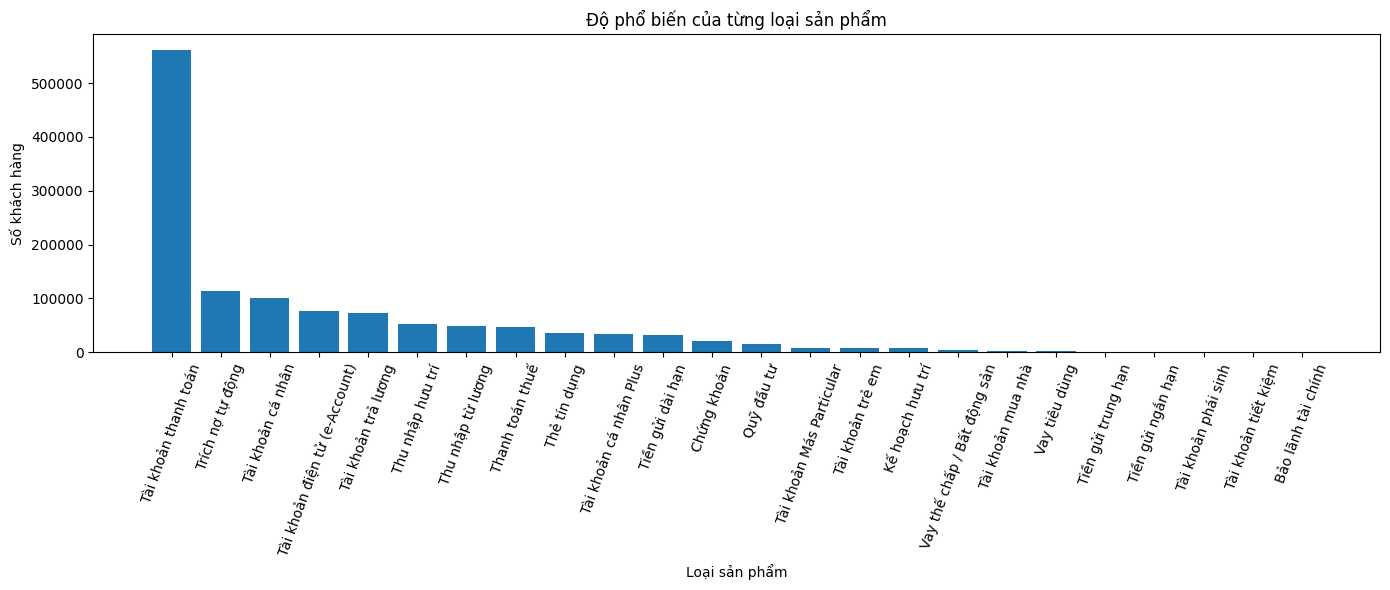

In [15]:
# Độ phổ biến của từng sản phẩm: số khách hàng sở hữu ở snapshot mới nhất.
product_sum_sql = ', '.join(
    f'SUM(COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)) AS {quote_identifier(column)}'
    for column in PRODUCT_COLUMNS
)

latest_customer_count = q('''
    SELECT COUNT(DISTINCT ncodpers) AS n
    FROM read_parquet(?)
''', str(TRAIN_PARQUET)).iloc[0, 0]

product_popularity = (
    q(f'''
        WITH latest_snapshot AS (
            SELECT * EXCLUDE (snapshot_rank)
            FROM (
                SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
                FROM read_parquet(?)
            )
            WHERE snapshot_rank = 1
        )
        SELECT {product_sum_sql} FROM latest_snapshot
    ''', str(TRAIN_PARQUET))
    .T.rename_axis('product_column')
    .reset_index()
    .rename(columns={0: 'customer_count'})
    .assign(
        product=lambda df: df['product_column'].map(PRODUCT_CATALOG).fillna(df['product_column']),
        ratio=lambda df: (df['customer_count'] / latest_customer_count * 100).round(2)
    )
    .sort_values('customer_count', ascending=False)
)

display(product_popularity)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(product_popularity['product'], product_popularity['customer_count'], color='#1f77b4')
ax.set(title='Độ phổ biến của từng loại sản phẩm', xlabel='Loại sản phẩm', ylabel='Số khách hàng')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_count,customer_count,customer_pct
0,0,256447,26.81
1,1,456390,47.71
2,2,120752,12.62
3,3,47837,5.00
4,4,28777,3.01
5,5,18047,1.89
6,6,12689,1.33
7,7,8356,0.87
8,8,4445,0.46
9,9,1897,0.20


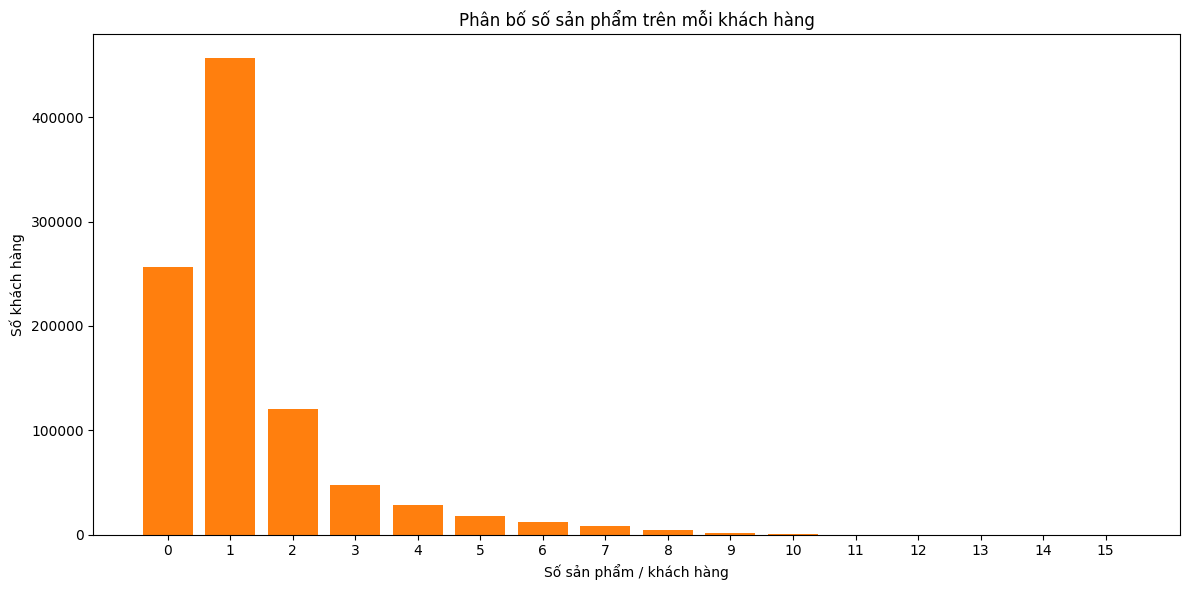

In [16]:
# Phân bố tổng số sản phẩm mà mỗi khách hàng sở hữu ở snapshot mới nhất.
products_per_customer_sql = ' + '.join(
    f'COALESCE(TRY_CAST({quote_identifier(column)} AS INTEGER), 0)'
    for column in PRODUCT_COLUMNS
)

product_count_distribution = q(f'''
    WITH latest_snapshot AS (
        SELECT * EXCLUDE (snapshot_rank)
        FROM (
            SELECT *, ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
            FROM read_parquet(?)
        )
        WHERE snapshot_rank = 1
    ),
    per_customer AS (
        SELECT {products_per_customer_sql} AS product_count
        FROM latest_snapshot
    )
    SELECT
        product_count,
        COUNT(*) AS customer_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_pct
    FROM per_customer
    GROUP BY product_count
    ORDER BY product_count
''', str(TRAIN_PARQUET))

display(product_count_distribution)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(product_count_distribution['product_count'], product_count_distribution['customer_count'], color='#ff7f0e')
ax.set(
    title='Phân bố số sản phẩm trên mỗi khách hàng',
    xlabel='Số sản phẩm / khách hàng',
    ylabel='Số khách hàng',
)
ax.set_xticks(product_count_distribution['product_count'])
plt.tight_layout()
plt.show()


### Chất lượng và tính nhất quán của feature profile theo lịch sử khách hàng

In [17]:
PROFILE_COLUMNS = [
    'age', 'antiguedad', 'renta', 'ind_nuevo', 'indrel', 'indrel_1mes',
    'tiprel_1mes', 'ind_actividad_cliente', 'ind_empleado', 'conyuemp',
    'indfall', 'sexo', 'pais_residencia', 'cod_prov', 'nomprov',
    'canal_entrada', 'segmento', 'fecha_alta', 'ult_fec_cli_1t',
]
PROFILE_COLUMNS = [column for column in PROFILE_COLUMNS if column in ALL_COLUMNS]

profile_validity = q("""
    SELECT
        COUNT(*) AS rows,
        SUM(age IS NULL) AS age_missing,
        SUM(age < 18 OR age > 100) AS implausible_age,
        MIN(age) AS min_age,
        quantile_cont(age, 0.01) AS age_p01,
        quantile_cont(age, 0.5) AS age_median,
        quantile_cont(age, 0.99) AS age_p99,
        MAX(age) AS max_age,
        SUM(antiguedad = -999999) AS tenure_sentinel_count,
        SUM(antiguedad < 0 AND antiguedad <> -999999) AS other_negative_tenure,
        SUM(renta < 0) AS negative_income_count,
        SUM(fecha_alta > fecha_dato) AS join_date_after_snapshot,
        SUM(ult_fec_cli_1t > fecha_dato) AS last_primary_date_after_snapshot
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
display(profile_validity)

profile_change = q("""
    WITH ordered AS (
        SELECT ncodpers, fecha_dato, age, antiguedad, renta,
               LAG(age) OVER customer_window AS prev_age,
               LAG(antiguedad) OVER customer_window AS prev_tenure,
               LAG(renta) OVER customer_window AS prev_income
        FROM read_parquet(?)
        WINDOW customer_window AS (PARTITION BY ncodpers ORDER BY fecha_dato)
    )
    SELECT
        SUM(prev_age IS NOT NULL AND ABS(age - prev_age) > 2) AS large_age_jumps,
        SUM(prev_tenure IS NOT NULL AND antiguedad < prev_tenure
            AND antiguedad <> -999999 AND prev_tenure <> -999999) AS tenure_decreases,
        SUM(prev_income IS NOT NULL AND renta IS NOT NULL AND prev_income IS NOT NULL
            AND ABS(renta - prev_income) / NULLIF(ABS(prev_income), 0) > 0.5) AS income_changes_over_50pct
    FROM ordered
""", str(TRAIN_PARQUET))
display(profile_change)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,age_missing,implausible_age,min_age,age_p01,age_median,age_p99,max_age,tenure_sentinel_count,other_negative_tenure,negative_income_count,join_date_after_snapshot,last_primary_date_after_snapshot
0,13647309,27734.0,131665.0,2.0,19.0,39.0,88.0,164.0,38.0,0.0,0.0,11586.0,5455.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,large_age_jumps,tenure_decreases,income_changes_over_50pct
0,148.0,2150.0,0.0


#### Insight rút ra được

- Bảng đầu tiên xác định chính xác các giá trị không hợp lệ/sentinel và chronology violation trước khi impute hoặc tạo feature; không suy luận validity chỉ từ distinct count.
- Bảng lịch sử tách thay đổi profile hợp lý khỏi khả năng lỗi dữ liệu. Các biến thay đổi mạnh giữa tháng, đặc biệt `renta`, nên dùng giá trị tại thời điểm dự báo và missing flag thay vì forward-fill vô điều kiện.

### Missingness profile, sự ổn định theo khách hàng và mối quan hệ địa lý

In [18]:
profile_missing_sql = ', '.join(
    f"ROUND(100.0 * SUM({quote_identifier(column)} IS NULL) / COUNT(*), 3) AS {quote_identifier(column)}"
    for column in PROFILE_COLUMNS
)
profile_missing = q(f"SELECT {profile_missing_sql} FROM read_parquet(?)", str(TRAIN_PARQUET)).T
profile_missing.columns = ['missing_pct']
profile_missing.index.name = 'feature'
display(profile_missing.sort_values('missing_pct', ascending=False))

missing_pattern = q("""
    WITH profile_flags AS (
        SELECT
            ncodpers,
            SUM(age IS NULL) AS age_missing,
            SUM(renta IS NULL) AS income_missing,
            SUM(indfall IS NULL) AS death_flag_missing,
            SUM(segmento IS NULL) AS segment_missing,
            COUNT(*) AS snapshots
        FROM read_parquet(?)
        GROUP BY ncodpers
    )
    SELECT
        snapshots,
        COUNT(*) AS customers,
        ROUND(100.0 * AVG(CASE WHEN age_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_age_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN income_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_income_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN death_flag_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_death_flag_missing_pct,
        ROUND(100.0 * AVG(CASE WHEN segment_missing > 0 THEN 1 ELSE 0 END), 2) AS customers_with_segment_missing_pct
    FROM profile_flags
    GROUP BY snapshots
    ORDER BY snapshots
""", str(TRAIN_PARQUET))
display(missing_pattern)

province_mapping = q("""
    SELECT
        COUNT(*) AS observed_rows,
        COUNT(DISTINCT cod_prov) AS province_codes,
        COUNT(DISTINCT nomprov) AS province_names,
        COUNT(DISTINCT (cod_prov, nomprov)) AS code_name_pairs,
        SUM(cod_prov IS NULL AND nomprov IS NOT NULL) AS code_missing_name_present,
        SUM(cod_prov IS NOT NULL AND nomprov IS NULL) AS name_missing_code_present
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
display(province_mapping)

province_conflicts = q("""
    SELECT cod_prov, COUNT(DISTINCT nomprov) AS names_per_code, COUNT(*) AS rows
    FROM read_parquet(?)
    WHERE cod_prov IS NOT NULL AND nomprov IS NOT NULL
    GROUP BY cod_prov
    HAVING COUNT(DISTINCT nomprov) > 1
    ORDER BY rows DESC
    LIMIT 20
""", str(TRAIN_PARQUET))
display(province_conflicts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_pct
feature,
conyuemp,99.987
ult_fec_cli_1t,99.818
renta,20.476
segmento,1.388
canal_entrada,1.364
indrel_1mes,1.098
tiprel_1mes,1.098
nomprov,0.686
cod_prov,0.686


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,snapshots,customers,customers_with_age_missing_pct,customers_with_income_missing_pct,customers_with_death_flag_missing_pct,customers_with_segment_missing_pct
0,1,10472,12.07,99.11,12.07,97.67
1,2,7256,13.57,98.61,13.57,97.06
2,3,7000,11.10,98.21,11.10,91.44
3,4,7297,10.17,95.51,10.17,96.63
4,5,8864,17.36,95.27,17.36,96.97
5,6,10012,17.95,92.37,17.95,91.92
6,7,16098,0.24,98.51,0.24,93.87
7,8,28061,0.10,98.94,0.10,96.59
8,9,23470,0.12,55.27,0.12,95.66
9,10,14911,0.21,18.62,0.21,92.66


,observed_rows,province_codes,province_names,code_name_pairs,code_missing_name_present,name_missing_code_present
0,13647309,52,52,53,0.0,0.0


,cod_prov,names_per_code,rows


#### Insight rút ra được

- Missingness được đánh giá ở cả row-level và customer-history level: cùng một tỷ lệ missing tổng có thể là một nhóm khách hàng luôn thiếu profile hoặc là missing ngẫu nhiên theo tháng; hai trường hợp cần chiến lược impute khác nhau.
- `cod_prov` và `nomprov` chỉ nên thay thế/fill chéo nếu bảng conflict rỗng hoặc được giải thích rõ. Khi mapping không một-một, chọn một canonical field và thêm missing indicator.

### Tương quan và association giữa các feature profile

In [19]:
numeric_association = q("""
    SELECT
        corr(age, antiguedad) AS age_tenure_pearson,
        corr(age, renta) AS age_income_pearson,
        corr(antiguedad, renta) AS tenure_income_pearson,
        corr(age, ind_actividad_cliente) AS age_activity_pearson,
        corr(antiguedad, ind_actividad_cliente) AS tenure_activity_pearson,
        corr(renta, ind_actividad_cliente) AS income_activity_pearson
    FROM read_parquet(?)
    WHERE age BETWEEN 18 AND 100
      AND antiguedad >= 0
      AND antiguedad <> -999999
      AND renta >= 0
""", str(TRAIN_PARQUET))
display(numeric_association.T.rename(columns={0: 'pearson_correlation'}))

profile_segment_summary = q("""
    SELECT
        COALESCE(segmento, 'Unknown') AS segmento,
        COUNT(*) AS customer_months,
        ROUND(AVG(age), 2) AS mean_age,
        ROUND(quantile_cont(renta, 0.5), 2) AS median_income,
        ROUND(100.0 * AVG(CASE WHEN ind_actividad_cliente = 1 THEN 1 ELSE 0 END), 2) AS active_pct,
        ROUND(100.0 * AVG(CASE WHEN ind_nuevo = 1 THEN 1 ELSE 0 END), 2) AS new_customer_pct
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY customer_months DESC
""", str(TRAIN_PARQUET))
display(profile_segment_summary)

association_sample = q("""
    WITH sample AS (
        SELECT *
        FROM read_parquet(?)
        WHERE hash(ncodpers) % 100 = 0
    ),
    employee_spouse AS (
        SELECT ind_empleado, conyuemp, COUNT(*) AS n
        FROM sample
        GROUP BY 1, 2
    )
    SELECT *
    FROM employee_spouse
    ORDER BY n DESC
""", str(TRAIN_PARQUET))
display(association_sample)

,pearson_correlation
age_tenure_pearson,0.601090
age_income_pearson,0.069417
tenure_income_pearson,0.082240
age_activity_pearson,0.143458
tenure_activity_pearson,0.139944
income_activity_pearson,0.026918


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segmento,customer_months,mean_age,median_income,active_pct,new_customer_pct
0,02 - PARTICULARES,7960220,49.13,108013.648438,52.29,3.22
1,03 - UNIVERSITARIO,4935579,24.22,88740.273438,29.88,8.00
2,01 - TOP,562142,55.10,141562.687500,98.43,4.28
3,Unknown,189368,35.02,100257.093750,23.70,71.69


,ind_empleado,conyuemp,n
0,N,None,138144
1,None,None,271
2,F,None,51
3,B,None,51
4,A,None,28
5,B,N,17
6,N,N,2


#### Insight rút ra được

- Pearson correlation chỉ là kiểm tra tuyến tính cho numeric feature sau khi loại sentinel/range không hợp lý; không dùng nó để kết luận quan hệ nhân quả hoặc loại feature categorical.
- Bảng segment cho thấy khác biệt profile và hoạt động theo phân khúc; chỉ sử dụng interaction đã được xác nhận bằng temporal validation. Bảng `ind_empleado × conyuemp` kiểm tra trực tiếp giả thuyết về cờ vợ/chồng nhân viên trên sample xác định, không cần quét/cross-tab toàn bộ dữ liệu nhiều lần.

## 6. Split and leakage checks
Compare train and test schemas, identifiers, time ranges, common numeric distributions, and unseen category values to flag split mismatch or potential leakage.

In [20]:
# Explicit feature lists keep this cell runnable independently of prior exploratory cells.
numeric_features = [c for c in ["age", "antiguedad", "renta"] if c in ALL_COLUMNS]
category_columns_to_check = [
    c for c in [
        "ind_empleado", "pais_residencia", "sexo", "indrel_1mes",
        "tiprel_1mes", "canal_entrada", "indfall", "nomprov", "segmento",
    ] if c in ALL_COLUMNS
]

if TEST_COLUMNS is None:
    print('Test checkpoint is unavailable; train/test comparison skipped.')
else:
    train_schema = TRAIN_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'train_type'})
    test_schema = TEST_COLUMNS[['column_name', 'column_type']].rename(columns={'column_type': 'test_type'})
    schema_comparison = train_schema.merge(test_schema, on='column_name', how='outer', indicator=True)
    display(schema_comparison.sort_values(['_merge', 'column_name']))
    print('Train-only columns are normally product-state columns. Any other train-only field needs review.')

    common_numeric = [c for c in numeric_features if c in set(TEST_COLUMNS.column_name)]
    numeric_shift_rows = []
    for column in common_numeric:
        col = quote_identifier(column)
        train_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TRAIN_PARQUET)).iloc[0].to_dict()
        test_stats = q(f'SELECT AVG({col}) AS mean, quantile_cont({col}, 0.5) AS median, COUNT({col}) AS non_null FROM read_parquet(?)', str(TEST_PARQUET)).iloc[0].to_dict()
        numeric_shift_rows.append({'feature': column, **{f'train_{k}': v for k, v in train_stats.items()}, **{f'test_{k}': v for k, v in test_stats.items()}})
    display(pd.DataFrame(numeric_shift_rows))

    if 'ncodpers' in set(TEST_COLUMNS.column_name):
        display(q('''
            SELECT COUNT(*) AS overlapping_customer_ids
            FROM (SELECT DISTINCT ncodpers FROM read_parquet(?)) train_ids
            INNER JOIN (SELECT DISTINCT ncodpers FROM read_parquet(?)) test_ids USING (ncodpers)
        ''', str(TRAIN_PARQUET), str(TEST_PARQUET)))

    if 'fecha_dato' in set(TEST_COLUMNS.column_name):
        display(q("SELECT 'train' AS split, MIN(fecha_dato) AS min_date, MAX(fecha_dato) AS max_date FROM read_parquet(?) UNION ALL SELECT 'test', MIN(fecha_dato), MAX(fecha_dato) FROM read_parquet(?)", str(TRAIN_PARQUET), str(TEST_PARQUET)))

    shared_categories = [c for c in category_columns_to_check if c in set(TEST_COLUMNS.column_name)]
    unseen_category_rows = []
    for column in shared_categories:
        col = quote_identifier(column)
        unseen = q(f'''
            SELECT COUNT(*) AS unseen_test_categories
            FROM (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL) test_values
            WHERE {col} NOT IN (SELECT DISTINCT {col} FROM read_parquet(?) WHERE {col} IS NOT NULL)
        ''', str(TEST_PARQUET), str(TRAIN_PARQUET)).iloc[0, 0]
        unseen_category_rows.append({'feature': column, 'unseen_test_categories': unseen})
    display(pd.DataFrame(unseen_category_rows))

    leakage_candidates = [c for c in ALL_COLUMNS if c in PRODUCT_COLUMNS or c.startswith('fecha_') or c == 'ult_fec_cli_1t']
    print('Review before modelling: these columns may encode current/future product state or timing:', leakage_candidates)


,column_name,train_type,test_type,_merge
8,ind_ahor_fin_ult1,TINYINT,NaN,left_only
9,ind_aval_fin_ult1,TINYINT,NaN,left_only
10,ind_cco_fin_ult1,TINYINT,NaN,left_only
11,ind_cder_fin_ult1,TINYINT,NaN,left_only
12,ind_cno_fin_ult1,TINYINT,NaN,left_only
13,ind_ctju_fin_ult1,TINYINT,NaN,left_only
14,ind_ctma_fin_ult1,TINYINT,NaN,left_only
15,ind_ctop_fin_ult1,TINYINT,NaN,left_only
16,ind_ctpp_fin_ult1,TINYINT,NaN,left_only
17,ind_deco_fin_ult1,TINYINT,NaN,left_only


Train-only columns are normally product-state columns. Any other train-only field needs review.


,feature,train_mean,train_median,train_non_null,test_mean,test_median,test_non_null
0,age,40.181465,39.0,13619575.0,40.249821,39.000000,929615.0
1,antiguedad,76.591941,50.0,13619575.0,77.728413,55.000000,929615.0
2,renta,134254.318212,101850.0,10852934.0,134087.870565,101490.515625,701650.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,overlapping_customer_ids
0,929615


,split,min_date,max_date
0,train,2015-01-28,2016-05-28
1,test,2016-06-28,2016-06-28


,feature,unseen_test_categories
0,ind_empleado,0
1,pais_residencia,0
2,sexo,0
3,indrel_1mes,0
4,tiprel_1mes,0
5,canal_entrada,0
6,indfall,0
7,nomprov,0
8,segmento,0


Review before modelling: these columns may encode current/future product state or timing: ['fecha_dato', 'fecha_alta', 'ult_fec_cli_1t', 'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1', 'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1', 'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1', 'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']


# 2. Customer Profile Feature EDA

Feature-level dossiers for customer profile variables: missingness diagnostics, distribution, encoding/outlier decisions, and association screening.

In [21]:
# Logic: define feature metadata, valid ranges, and candidate relationships used by the feature dossiers.
# Feature Deep EDA — configuration
from __future__ import annotations

from typing import Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "TRAIN_PARQUET" not in globals() or "q" not in globals():
    raise RuntimeError("Run the existing 'EDA setup' cell before this section.")

# Standalone fallback: the previous profile-quality cell may be skipped while iterating.
DEFAULT_PROFILE_COLUMNS = [
    "age", "antiguedad", "renta", "ind_nuevo", "indrel", "indrel_1mes",
    "tiprel_1mes", "ind_actividad_cliente", "ind_empleado", "conyuemp",
    "indfall", "sexo", "pais_residencia", "cod_prov", "nomprov",
    "canal_entrada", "segmento", "fecha_alta", "ult_fec_cli_1t",
]
PROFILE_COLUMNS = [c for c in globals().get("PROFILE_COLUMNS", DEFAULT_PROFILE_COLUMNS) if c in ALL_COLUMNS]
PROFILE_NUMERIC = {"age", "antiguedad", "renta"}
PROFILE_DATES = {"fecha_alta", "ult_fec_cli_1t"}
PROFILE_ORDINAL = {"ind_nuevo", "indrel", "indrel_1mes", "ind_actividad_cliente"}
VALID_RANGES = {"age": (18, 100), "antiguedad": (0, None), "renta": (0, None)}
TOP_LEVELS = 15
ASSOCIATION_SAMPLE_MOD = 100  # deterministic ~1% customer sample; preserves full customer histories

FEATURE_PARTNERS = {
    "age": ["renta", "antiguedad", "segmento", "ind_nuevo"],
    "antiguedad": ["fecha_alta", "age", "ind_nuevo", "indrel_1mes"],
    "renta": ["age", "segmento", "cod_prov", "ind_actividad_cliente"],
    "ind_nuevo": ["antiguedad", "fecha_alta", "age", "canal_entrada"],
    "indrel": ["indrel_1mes", "tiprel_1mes", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "indrel_1mes": ["indrel", "tiprel_1mes", "ind_actividad_cliente", "ind_nuevo"],
    "tiprel_1mes": ["indrel_1mes", "indrel", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "ind_actividad_cliente": ["tiprel_1mes", "indrel_1mes", "segmento", "canal_entrada"],
    "ind_empleado": ["conyuemp", "canal_entrada", "segmento", "renta"],
    "conyuemp": ["ind_empleado", "sexo", "indfall", "segmento"],
    "indfall": ["ind_actividad_cliente", "tiprel_1mes", "indrel_1mes", "ult_fec_cli_1t"],
    "sexo": ["age", "renta", "segmento", "canal_entrada"],
    "pais_residencia": ["indresi", "indext", "cod_prov", "canal_entrada"],
    "cod_prov": ["nomprov", "renta", "segmento", "canal_entrada"],
    "nomprov": ["cod_prov", "renta", "segmento", "canal_entrada"],
    "canal_entrada": ["segmento", "ind_nuevo", "ind_actividad_cliente", "ind_empleado"],
    "segmento": ["renta", "age", "ind_actividad_cliente", "canal_entrada"],
    "fecha_alta": ["antiguedad", "ind_nuevo", "age", "canal_entrada"],
    "ult_fec_cli_1t": ["indrel", "indrel_1mes", "tiprel_1mes", "indfall"],
}
HISTORY_FILL_CANDIDATES = {"age", "fecha_alta", "sexo", "pais_residencia", "cod_prov", "nomprov"}
TYPE_BY_COLUMN = dict(zip(TRAIN_COLUMNS["column_name"], TRAIN_COLUMNS["column_type"]))

def feature_kind(feature: str) -> str:
    if feature in PROFILE_NUMERIC:
        return "numeric"
    if feature in PROFILE_DATES:
        return "date"
    if feature in PROFILE_ORDINAL:
        return "ordinal"
    return "categorical"

def col_sql(feature: str) -> str:
    return quote_identifier(feature)

def label_expr(feature: str) -> str:
    return f"COALESCE(CAST({col_sql(feature)} AS VARCHAR), '__MISSING__')"

def numeric_expr(feature: str) -> str:
    return f"TRY_CAST({col_sql(feature)} AS DOUBLE)"

def cramer_v_from_counts(counts: pd.DataFrame) -> float:
    matrix = counts.to_numpy(dtype=float)
    if matrix.size == 0 or min(matrix.shape) < 2:
        return np.nan
    total = matrix.sum()
    expected = np.outer(matrix.sum(axis=1), matrix.sum(axis=0)) / total
    chi2 = np.divide((matrix - expected) ** 2, expected, out=np.zeros_like(matrix), where=expected > 0).sum()
    return float(np.sqrt((chi2 / total) / min(matrix.shape[0] - 1, matrix.shape[1] - 1)))

In [22]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
# Feature Deep EDA — shared helpers for separated, feature-by-feature cells
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "TRAIN_PARQUET" not in globals() or "q" not in globals():
    raise RuntimeError("Run the existing EDA setup cell before this section.")

PROFILE_COLUMNS = [c for c in [
    "age", "antiguedad", "renta", "ind_nuevo", "indrel", "indrel_1mes",
    "tiprel_1mes", "ind_actividad_cliente", "ind_empleado", "conyuemp",
    "indfall", "sexo", "pais_residencia", "cod_prov", "nomprov",
    "canal_entrada", "segmento", "fecha_alta", "ult_fec_cli_1t",
] if c in ALL_COLUMNS]
NUMERIC_PROFILE_COLUMNS = {"age", "antiguedad", "renta"}
TOP_LEVELS = 15

FEATURE_PARTNERS = {
    "age": ["antiguedad", "renta", "segmento", "ind_nuevo"],
    "antiguedad": ["age", "fecha_alta", "ind_nuevo", "indrel_1mes"],
    "renta": ["age", "segmento", "cod_prov", "ind_actividad_cliente"],
    "ind_nuevo": ["antiguedad", "fecha_alta", "age", "canal_entrada"],
    "indrel": ["indrel_1mes", "tiprel_1mes", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "indrel_1mes": ["indrel", "tiprel_1mes", "ind_actividad_cliente", "ind_nuevo"],
    "tiprel_1mes": ["indrel_1mes", "indrel", "ind_actividad_cliente", "ult_fec_cli_1t"],
    "ind_actividad_cliente": ["tiprel_1mes", "indrel_1mes", "segmento", "canal_entrada"],
    "ind_empleado": ["conyuemp", "canal_entrada", "segmento", "renta"],
    "conyuemp": ["ind_empleado", "sexo", "indfall", "segmento"],
    "indfall": ["ind_actividad_cliente", "tiprel_1mes", "indrel_1mes", "ult_fec_cli_1t"],
    "sexo": ["age", "renta", "segmento", "canal_entrada"],
    "pais_residencia": ["cod_prov", "nomprov", "canal_entrada", "segmento"],
    "cod_prov": ["nomprov", "renta", "segmento", "canal_entrada"],
    "nomprov": ["cod_prov", "renta", "segmento", "canal_entrada"],
    "canal_entrada": ["segmento", "ind_nuevo", "ind_actividad_cliente", "ind_empleado"],
    "segmento": ["renta", "age", "ind_actividad_cliente", "canal_entrada"],
    "fecha_alta": ["antiguedad", "ind_nuevo", "age", "canal_entrada"],
    "ult_fec_cli_1t": ["indrel", "indrel_1mes", "tiprel_1mes", "indfall"],
}

def F(feature: str) -> str:
    return quote_identifier(feature)

def value_label(feature: str) -> str:
    return f"COALESCE(CAST({F(feature)} AS VARCHAR), '__MISSING__')"

def deep_overview(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT COUNT(*) AS rows,
               SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct,
               COUNT(DISTINCT {F(feature)}) AS n_unique_non_null
        FROM read_parquet(?)
    """, str(TRAIN_PARQUET))

def deep_missing_by_month(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT fecha_dato, COUNT(*) AS rows, SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct
        FROM read_parquet(?) GROUP BY 1 ORDER BY 1
    """, str(TRAIN_PARQUET))

def deep_history_missing(feature: str) -> pd.DataFrame:
    return q(f"""
        WITH ordered AS (
            SELECT ncodpers, fecha_dato, {F(feature)} IS NULL AS is_missing,
                   MAX(CASE WHEN {F(feature)} IS NOT NULL THEN 1 ELSE 0 END) OVER (
                       PARTITION BY ncodpers ORDER BY fecha_dato
                       ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
                   ) AS observed_before
            FROM read_parquet(?)
        )
        SELECT SUM(is_missing) AS missing_rows,
               SUM(is_missing AND COALESCE(observed_before, 0) = 1) AS missing_after_observed,
               ROUND(100.0 * SUM(is_missing AND COALESCE(observed_before, 0) = 1)
                     / NULLIF(SUM(is_missing), 0), 2) AS pct_after_observed
        FROM ordered
    """, str(TRAIN_PARQUET))

def deep_missing_by_driver(feature: str, driver: str) -> pd.DataFrame:
    return q(f"""
        SELECT {value_label(driver)} AS {quote_identifier(driver)},
               COUNT(*) AS rows,
               SUM({F(feature)} IS NULL) AS missing_count,
               ROUND(100.0 * AVG(CASE WHEN {F(feature)} IS NULL THEN 1 ELSE 0 END), 3) AS missing_pct
        FROM read_parquet(?)
        GROUP BY 1
        ORDER BY rows DESC, missing_pct DESC
        LIMIT {TOP_LEVELS}
    """, str(TRAIN_PARQUET))

def deep_numeric_describe(feature: str) -> pd.DataFrame:
    x = f"TRY_CAST({F(feature)} AS DOUBLE)"
    return q(f"""
        WITH v AS (SELECT {x} AS x FROM read_parquet(?) WHERE {x} IS NOT NULL),
        b AS (SELECT quantile_cont(x,.01) p01, quantile_cont(x,.25) q1, quantile_cont(x,.5) median,
                     quantile_cont(x,.75) q3, quantile_cont(x,.99) p99 FROM v)
        SELECT COUNT(*) AS non_null_count, MIN(x) AS min_value, AVG(x) AS mean_value,
               STDDEV_SAMP(x) AS std_value, b.p01, b.q1, b.median, b.q3, b.p99, MAX(x) AS max_value,
               SUM(CASE WHEN x < b.q1-1.5*(b.q3-b.q1) OR x > b.q3+1.5*(b.q3-b.q1) THEN 1 ELSE 0 END) AS iqr_outlier_count,
               ROUND(100.0 * AVG(CASE WHEN x < b.q1-1.5*(b.q3-b.q1) OR x > b.q3+1.5*(b.q3-b.q1) THEN 1 ELSE 0 END), 3) AS iqr_outlier_pct
        FROM v CROSS JOIN b GROUP BY b.p01,b.q1,b.median,b.q3,b.p99
    """, str(TRAIN_PARQUET))

def deep_top_values(feature: str) -> pd.DataFrame:
    return q(f"""
        SELECT {value_label(feature)} AS value, COUNT(*) AS rows,
               ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),3) AS pct
        FROM read_parquet(?) GROUP BY 1 ORDER BY rows DESC, value LIMIT {TOP_LEVELS}
    """, str(TRAIN_PARQUET))

def deep_association_table(feature: str) -> pd.DataFrame:
    partners = [p for p in FEATURE_PARTNERS.get(feature, []) if p in ALL_COLUMNS]
    if feature in NUMERIC_PROFILE_COLUMNS:
        rows = []
        for partner in partners:
            if partner not in NUMERIC_PROFILE_COLUMNS:
                continue
            score = q(f"""
                SELECT corr(x_rank,y_rank) AS spearman_rho FROM (
                    SELECT RANK() OVER (ORDER BY x) AS x_rank, RANK() OVER (ORDER BY y) AS y_rank
                    FROM (
                        SELECT TRY_CAST({F(feature)} AS DOUBLE) AS x, TRY_CAST({F(partner)} AS DOUBLE) AS y
                        FROM read_parquet(?)
                        WHERE hash(ncodpers) % 100 = 0
                          AND TRY_CAST({F(feature)} AS DOUBLE) IS NOT NULL
                          AND TRY_CAST({F(partner)} AS DOUBLE) IS NOT NULL
                    )
                )
            """, str(TRAIN_PARQUET)).iloc[0, 0]
            rows.append({"partner": partner, "measure": "Spearman rho", "score": score})
        return pd.DataFrame(rows)
    # For categorical/temporal variables, show compatible partner levels instead of misleading Pearson correlation.
    return pd.DataFrame({"candidate_partner": partners,
                         "how_to_combine": ["Validate as an interaction with time-based split."] * len(partners)})

In [23]:
def missing_before_valid(feature: str = "age") -> pd.DataFrame:
    return q(f"""
        WITH ordered AS (
            SELECT
                ncodpers,
                fecha_dato,
                {F(feature)} AS value,
                LEAD({F(feature)}) OVER (
                    PARTITION BY ncodpers
                    ORDER BY fecha_dato
                ) AS next_value
            FROM read_parquet(?)
        )
        SELECT
            COUNT(*) FILTER (
                WHERE value IS NULL
            ) AS missing_rows,

            COUNT(*) FILTER (
                WHERE value IS NULL
                  AND next_value IS NOT NULL
            ) AS missing_then_valid,

            ROUND(
                100.0 * COUNT(*) FILTER (
                    WHERE value IS NULL
                      AND next_value IS NOT NULL
                )
                / NULLIF(COUNT(*) FILTER (WHERE value IS NULL), 0),
                2
            ) AS pct_missing_then_valid
        FROM ordered
    """, str(TRAIN_PARQUET))

In [24]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
# Feature Deep EDA — insight renderers (always derived from the cell outputs)
from IPython.display import Markdown, display

def show_overview_insight(feature: str, overview: pd.DataFrame) -> None:
    row = overview.iloc[0]
    display(Markdown(
        f"**Insight.** {feature} có **{int(row.missing_count):,}** giá trị thiếu "
        f"(**{row.missing_pct:.3f}%**) và **{int(row.n_unique_non_null):,}** giá trị khác nhau (không tính null). "
        "Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation."
    ))

def show_missing_insight(feature: str, history: pd.DataFrame, driver: str) -> None:
    row = history.iloc[0]
    if pd.isna(row.pct_after_observed):
        decision = "Không có missing vật lý, nên không cần imputation."
    elif feature in {"age", "fecha_alta", "sexo", "pais_residencia", "cod_prov", "nomprov"} and row.pct_after_observed >= 70:
        decision = "Forward-fill theo ncodpers từ các tháng trước là ứng viên hợp lý; vẫn giữ cờ missing gốc."
    elif feature in NUMERIC_PROFILE_COLUMNS:
        decision = "Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện."
    else:
        decision = "Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng."
    display(Markdown(
        f"**Insight.** Có **{int(row.missing_rows):,}** missing; **{row.pct_after_observed if pd.notna(row.pct_after_observed) else 0:.2f}%** "
        f"xảy ra sau một quan sát hợp lệ trước đó. Bảng theo {driver} là kiểm chứng giả thuyết missing theo nhóm. {decision}"
    ))

def show_distribution_insight(feature: str, kind: str, values: pd.DataFrame) -> None:
    if kind == "numeric":
        row = values.iloc[0]
        display(Markdown(
            f"**Insight.** Median = **{row["median"]:,.2f}**, P01–P99 = **{row["p01"]:,.2f}–{row["p99"]:,.2f}**; "
            f"**{row["iqr_outlier_pct"]:.3f}%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; "
            "chỉ tạo bins như feature bổ sung khi temporal validation có lợi."
        ))
    else:
        top = values.iloc[0]
        display(Markdown(
            f"**Insight.** Giá trị phổ biến nhất là {top.value} với **{top.pct:.3f}%**. "
            "Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding."
        ))

def show_association_insight(feature: str, associations: pd.DataFrame) -> None:
    if associations.empty:
        text = "Không có association định lượng phù hợp trong danh sách ứng viên; giữ các cặp theo domain để kiểm tra bằng temporal validation."
    elif "score" in associations:
        top = associations.iloc[0]
        text = f"Association mạnh nhất trong các ứng viên là {top.partner} ({top.measure} = **{top.score:.3f}**). Đây là ứng viên interaction, không phải bằng chứng nhân quả."
    else:
        text = "Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện."
    display(Markdown("**Insight.** " + text))

### age — Tuổi khách hàng

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [25]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
age_overview = deep_overview("age")
display(age_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,120


**Insight — completeness & cardinality**

In [26]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("age", age_overview)

**Insight.** age có **27,734** giá trị thiếu (**0.203%**) và **120** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [27]:
# Logic: test whether missingness changes by monthly snapshot.
age_missing_by_month = deep_missing_by_month("age")
display(age_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [28]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
age_history_missing = deep_history_missing("age")
display(age_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [29]:
age_before_missing = missing_before_valid  ("age")

display(age_before_missing )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_then_valid,pct_missing_then_valid
0,27734,309,1.11


In [30]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
age_missing_by_segmento = deep_missing_by_driver("age", "segmento")
display(age_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,0.0,0.000
1,03 - UNIVERSITARIO,4935579,0.0,0.000
2,01 - TOP,562142,0.0,0.000
3,__MISSING__,189368,27734.0,14.646


**Insight — missingness hypothesis and treatment**

In [31]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("age", age_history_missing, "segmento")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [32]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
age_describe = deep_numeric_describe("age")
display(age_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,13619575,2.0,40.181465,17.185087,19.0,24.0,39.0,50.0,88.0,164.0,113291.0,0.832


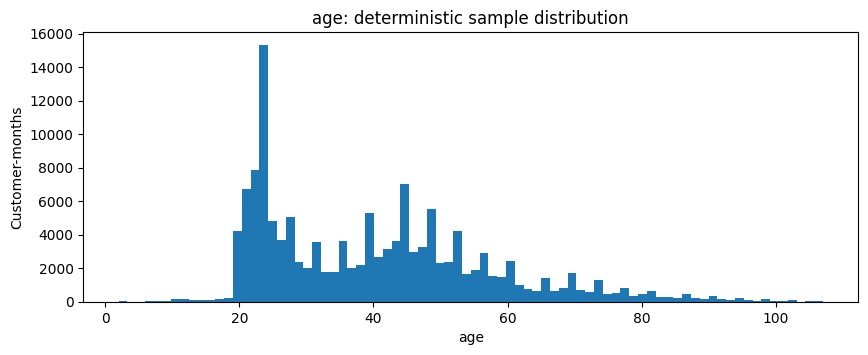

In [33]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_age = q("SELECT TRY_CAST(age AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(age AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_age["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="age: deterministic sample distribution")
ax.set(xlabel="age", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [34]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("age", "numeric", age_describe)

**Insight.** Median = **39.00**, P01–P99 = **19.00–88.00**; **0.832%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [35]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
age_associations = deep_association_table("age")
display(age_associations)

,partner,measure,score
0,antiguedad,Spearman rho,0.639557
1,renta,Spearman rho,0.177500


#### age × antiguedad — joint missingness and relationship

Các cell dưới đây không coi tuổi ngoài 18–90 là outlier. Riêng sentinel tenure -999999 được loại khỏi phép tính tương quan vì không phải thâm niên hợp lệ.

In [36]:
# Logic: create the 2×2 missingness table to test whether age and antiguedad are absent together.
age_tenure_missing_overlap = q("""
    SELECT
        CASE WHEN age IS NULL THEN 'age_missing' ELSE 'age_observed' END AS age_status,
        CASE WHEN antiguedad IS NULL THEN 'tenure_missing' ELSE 'tenure_observed' END AS tenure_status,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS row_pct
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
display(age_tenure_missing_overlap)

,age_status,tenure_status,rows,row_pct
0,age_missing,tenure_missing,27734,0.2032
1,age_observed,tenure_observed,13619575,99.7968


**Insight — joint missingness**

In [37]:
# Logic: quantify how much age imputation can safely rely on antiguedad availability.
from IPython.display import Markdown, display
_age_tenure_lookup = age_tenure_missing_overlap.set_index(["age_status", "tenure_status"])["rows"]
_age_missing_total = _age_tenure_lookup.get(("age_missing", "tenure_missing"), 0) + _age_tenure_lookup.get(("age_missing", "tenure_observed"), 0)
_both_missing = _age_tenure_lookup.get(("age_missing", "tenure_missing"), 0)
_both_missing_pct = 100.0 * _both_missing / _age_missing_total if _age_missing_total else 0
display(Markdown(
    f"**Insight.** {_both_missing:,} / {_age_missing_total:,} age-missing rows (**{_both_missing_pct:.2f}%**) "
    "also lack antiguedad. Therefore antiguedad may be used only for the remaining age-missing rows; "
    "it is not a valid imputation source for the jointly-missing subgroup."
))

**Insight.** 27,734 / 27,734 age-missing rows (**100.00%**) also lack antiguedad. Therefore antiguedad may be used only for the remaining age-missing rows; it is not a valid imputation source for the jointly-missing subgroup.

In [38]:
# Logic: measure Pearson and Spearman relationship by snapshot using all observed ages and valid tenure.
age_tenure_corr_by_month = q("""
    WITH valid AS (
        SELECT fecha_dato, age::DOUBLE AS age_value, antiguedad::DOUBLE AS tenure_value
        FROM read_parquet(?)
        WHERE age IS NOT NULL
          AND antiguedad IS NOT NULL
          AND antiguedad <> -999999
    ),
    ranked AS (
        SELECT
            fecha_dato,
            age_value,
            tenure_value,
            RANK() OVER (PARTITION BY fecha_dato ORDER BY age_value) AS age_rank,
            RANK() OVER (PARTITION BY fecha_dato ORDER BY tenure_value) AS tenure_rank
        FROM valid
    )
    SELECT
        fecha_dato,
        COUNT(*) AS paired_rows,
        ROUND(corr(age_value, tenure_value), 4) AS pearson_r,
        ROUND(corr(age_rank, tenure_rank), 4) AS spearman_rho
    FROM ranked
    GROUP BY 1
    ORDER BY 1
""", str(TRAIN_PARQUET))
display(age_tenure_corr_by_month)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fecha_dato,paired_rows,pearson_r,spearman_rho
0,2015-01-28,618502,0.6037,0.6492
1,2015-02-28,621452,0.6007,0.6429
2,2015-03-28,624116,0.5978,0.6370
3,2015-04-28,626073,0.5952,0.6320
4,2015-05-28,628358,0.5926,0.6268
5,2015-06-28,630247,0.5900,0.6221
6,2015-07-28,829815,0.5850,0.6289
7,2015-08-28,843199,0.5894,0.6345
8,2015-09-28,865438,0.5971,0.6452
9,2015-10-28,892249,0.6055,0.6561


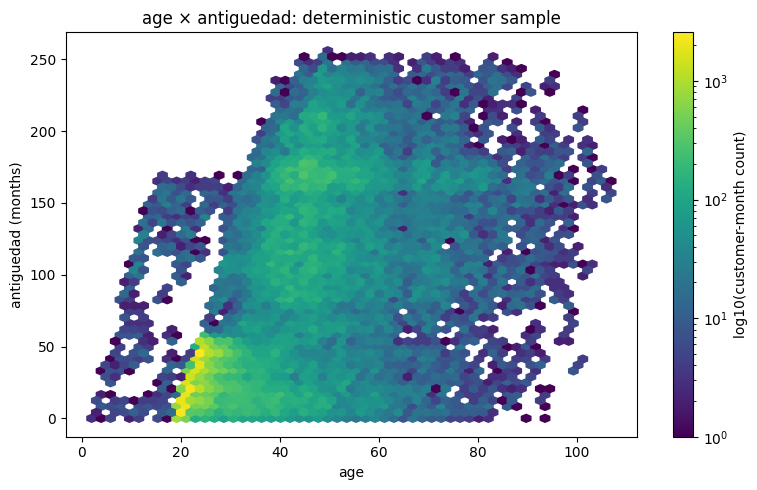

In [39]:
# Logic: plot the age-tenure relationship on a deterministic customer sample, retaining extreme observed ages.
age_tenure_sample = q("""
    SELECT age::DOUBLE AS age_value, antiguedad::DOUBLE AS tenure_value
    FROM read_parquet(?)
    WHERE hash(ncodpers) % 100 = 0
      AND age IS NOT NULL
      AND antiguedad IS NOT NULL
      AND antiguedad <> -999999
    LIMIT 200000
""", str(TRAIN_PARQUET))
fig, ax = plt.subplots(figsize=(8, 5))
hexbin = ax.hexbin(
    age_tenure_sample["age_value"],
    age_tenure_sample["tenure_value"],
    gridsize=55,
    mincnt=1,
    bins="log",
    cmap="viridis",
)
fig.colorbar(hexbin, ax=ax, label="log10(customer-month count)")
ax.set(title="age × antiguedad: deterministic customer sample", xlabel="age", ylabel="antiguedad (months)")
plt.tight_layout()
plt.show()

**Insight — association and modelling use**

In [40]:
# Logic: summarize correlation stability across months and state the safe modelling implication.
_corr_min = age_tenure_corr_by_month["spearman_rho"].min()
_corr_max = age_tenure_corr_by_month["spearman_rho"].max()
_corr_median = age_tenure_corr_by_month["spearman_rho"].median()
display(Markdown(
    f"**Insight.** Spearman rho by month ranges from **{_corr_min:.3f}** to **{_corr_max:.3f}** "
    f"(median **{_corr_median:.3f}**). This supports keeping both variables: their correlation is useful but not redundant. "
    "Use their interaction only if time-based validation improves MAP@7; never use tenure to impute age where both are missing."
))

**Insight.** Spearman rho by month ranges from **0.620** to **0.656** (median **0.636**). This supports keeping both variables: their correlation is useful but not redundant. Use their interaction only if time-based validation improves MAP@7; never use tenure to impute age where both are missing.

#### Tổng hợp, kết luận — age

**Kết luận thao tác.** Dùng numeric gốc; không clip chỉ vì age ngoài 18–90. Fill theo lịch sử quá khứ nếu có; phần còn lại median theo training fold và cờ missing. Kiểm tra joint missingness với antiguedad.

#### age — train/test distribution check

Đối chiếu phân phối age trên train và test theo từng giá trị quan sát được. Mục tiêu là kiểm chứng rằng tuổi ngoài khoảng 18–90 không nên bị cắt chỉ dựa vào rule-of-thumb.

In [41]:
# Logic: calculate normalized age frequencies in train and test, retaining every observed age including values outside 18–90.

age_train_test_distribution = q("""
    WITH combined AS (
        SELECT 'train' AS dataset, TRY_CAST(age AS INTEGER) AS age_value
        FROM read_parquet(?)
        UNION ALL
        SELECT 'test' AS dataset, TRY_CAST(age AS INTEGER) AS age_value
        FROM read_parquet(?)
    )
    SELECT dataset, age_value, COUNT(*) AS records
    FROM combined
    WHERE age_value IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 2, 1
""", str(TRAIN_PARQUET), str(TEST_PARQUET))

age_train_test_pct = (
    age_train_test_distribution
    .pivot(index="age_value", columns="dataset", values="records")
    .fillna(0)
)
age_train_test_pct = age_train_test_pct.div(age_train_test_pct.sum(axis=0), axis=1).mul(100)
display(age_train_test_pct.round(4))

dataset,test,train
age_value,,
2,0.0051,0.0054
3,0.0123,0.0113
4,0.0142,0.0162
5,0.0205,0.0221
6,0.0250,0.0270
...,...,...
118,0.0001,0.0000
126,0.0000,0.0000
127,0.0001,0.0001


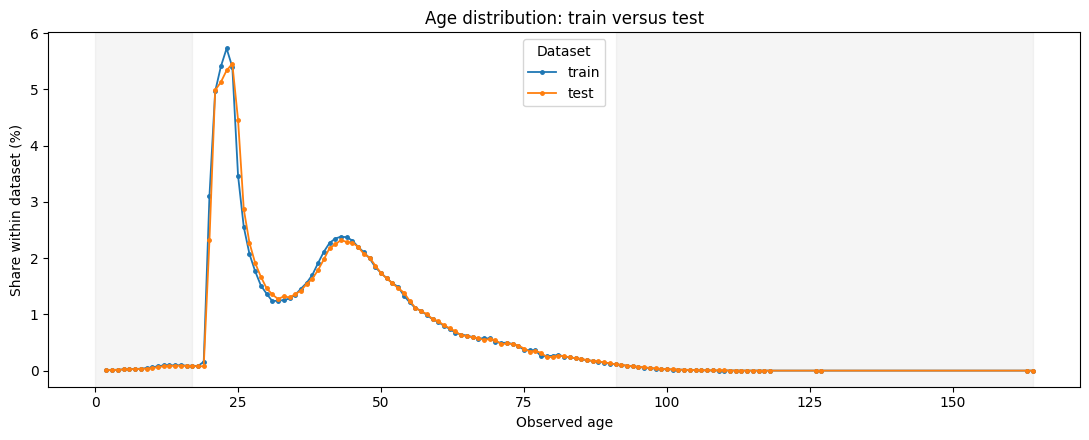

In [42]:
# Logic: overlay train and test age shares to inspect distributional similarity without hiding age extremes.

fig, ax = plt.subplots(figsize=(11, 4.5))
for dataset, color in [("train", "#1f77b4"), ("test", "#ff7f0e")]:
    if dataset in age_train_test_pct.columns:
        ax.plot(age_train_test_pct.index, age_train_test_pct[dataset], marker="o", markersize=2.5,
                linewidth=1.3, label=dataset, color=color)
ax.axvspan(0, 17, color="grey", alpha=.08)
ax.axvspan(91, age_train_test_pct.index.max(), color="grey", alpha=.08)
ax.set(
    title="Age distribution: train versus test",
    xlabel="Observed age",
    ylabel="Share within dataset (%)",
)
ax.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [43]:
# Logic: quantify distribution distance and the observed mass outside the conventional 18–90 band.

from IPython.display import Markdown, display

_age_union = age_train_test_pct.reindex(columns=["train", "test"], fill_value=0)
_age_tvd = 0.5 * (_age_union["train"] - _age_union["test"]).abs().sum()
_train_outside = _age_union.loc[(_age_union.index < 18) | (_age_union.index > 90), "train"].sum()
_test_outside = _age_union.loc[(_age_union.index < 18) | (_age_union.index > 90), "test"].sum()
display(Markdown(
    f"**Insight.** Total-variation distance giữa hai phân phối age là **{_age_tvd:.3f}** điểm %. "
    f"Tỷ trọng age ngoài 18–90 là **{_train_outside:.3f}%** ở train và **{_test_outside:.3f}%** ở test. "
    "Nếu hai tỷ trọng gần nhau, các giá trị này không nên tự động bị clip/xóa như outlier chỉ theo ngưỡng tuổi."
))

**Insight.** Total-variation distance giữa hai phân phối age là **2.652** điểm %. Tỷ trọng age ngoài 18–90 là **1.580%** ở train và **1.541%** ở test. Nếu hai tỷ trọng gần nhau, các giá trị này không nên tự động bị clip/xóa như outlier chỉ theo ngưỡng tuổi.

In [44]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("age", age_associations)

**Insight.** Association mạnh nhất trong các ứng viên là antiguedad (Spearman rho = **0.640**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### antiguedad — Thâm niên với ngân hàng

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [45]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
antiguedad_overview = deep_overview("antiguedad")
display(antiguedad_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,258


**Insight — completeness & cardinality**

In [46]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("antiguedad", antiguedad_overview)

**Insight.** antiguedad có **27,734** giá trị thiếu (**0.203%**) và **258** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [47]:
# Logic: test whether missingness changes by monthly snapshot.
antiguedad_missing_by_month = deep_missing_by_month("antiguedad")
display(antiguedad_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [48]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
antiguedad_history_missing = deep_history_missing("antiguedad")
display(antiguedad_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [49]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
antiguedad_missing_by_ind_nuevo = deep_missing_by_driver("antiguedad", "ind_nuevo")
display(antiguedad_missing_by_ind_nuevo)

,ind_nuevo,rows,missing_count,missing_pct
0,0,12808368,0.0,0.0
1,1,811207,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [50]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("antiguedad", antiguedad_history_missing, "ind_nuevo")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_nuevo là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [51]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
antiguedad_describe = deep_numeric_describe("antiguedad")
display(antiguedad_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,13619575,-999999.0,76.591941,1671.806547,1.0,23.0,50.0,135.0,232.0,256.0,38.0,0.0


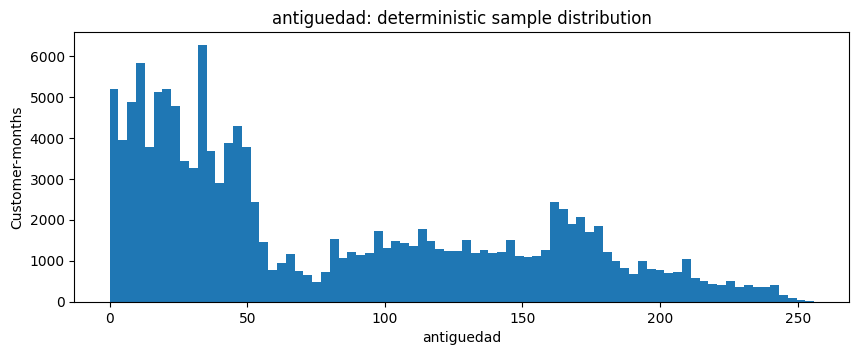

In [52]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_antiguedad = q("SELECT TRY_CAST(antiguedad AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(antiguedad AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_antiguedad["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="antiguedad: deterministic sample distribution")
ax.set(xlabel="antiguedad", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [53]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("antiguedad", "numeric", antiguedad_describe)

**Insight.** Median = **50.00**, P01–P99 = **1.00–232.00**; **0.000%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [54]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
antiguedad_associations = deep_association_table("antiguedad")
display(antiguedad_associations)

,partner,measure,score
0,age,Spearman rho,0.639557


#### Tổng hợp, kết luận — antiguedad

**Kết luận thao tác.** Đổi sentinel -999999 thành null. Dùng past-only fill khi có lịch sử; residual median train-fold + cờ missing. Xem đây là feature redundant mạnh với fecha_alta.

In [55]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("antiguedad", antiguedad_associations)

**Insight.** Association mạnh nhất trong các ứng viên là age (Spearman rho = **0.640**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### renta — Thu nhập gộp hàng năm

Biến numeric; kiểm tra missing, phân phối, domain validity, outlier và các interaction ứng viên.

In [56]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
renta_overview = deep_overview("renta")
display(renta_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,2794375.0,20.476,520988


**Insight — completeness & cardinality**

In [57]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("renta", renta_overview)

**Insight.** renta có **2,794,375** giá trị thiếu (**20.476%**) và **520,988** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [58]:
# Logic: test whether missingness changes by monthly snapshot.
renta_missing_by_month = deep_missing_by_month("renta")
display(renta_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,111578.0,17.839
1,2015-02-28,627394,111119.0,17.711
2,2015-03-28,629209,110709.0,17.595
3,2015-04-28,630367,110262.0,17.492
4,2015-05-28,631957,109919.0,17.393
5,2015-06-28,632110,108439.0,17.155
6,2015-07-28,829817,142540.0,17.177
7,2015-08-28,843201,144237.0,17.106
8,2015-09-28,865440,156029.0,18.029
9,2015-10-28,892251,183316.0,20.545


In [59]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
renta_history_missing = deep_history_missing("renta")
display(renta_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,2794375.0,0.0,0.0


In [60]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
renta_missing_by_segmento = deep_missing_by_driver("renta", "segmento")
display(renta_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,1437342.0,18.057
1,03 - UNIVERSITARIO,4935579,1142131.0,23.141
2,01 - TOP,562142,82367.0,14.652
3,__MISSING__,189368,132535.0,69.988


**Insight — missingness hypothesis and treatment**

In [61]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("renta", renta_history_missing, "segmento")

**Insight.** Có **2,794,375** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ cờ missing gốc và chỉ median-impute bên trong training fold; không forward-fill vô điều kiện.

In [62]:
# Logic: calculate robust numeric summary statistics and Tukey-fence outlier rate.
renta_describe = deep_numeric_describe("renta")
display(renta_describe)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,non_null_count,min_value,mean_value,std_value,p01,q1,median,q3,p99,max_value,iqr_outlier_count,iqr_outlier_pct
0,10852934,1202.72998,134254.318212,230620.237638,26449.650391,68710.976562,101850.0,155955.953125,554795.0,28894396.0,659391.0,6.076


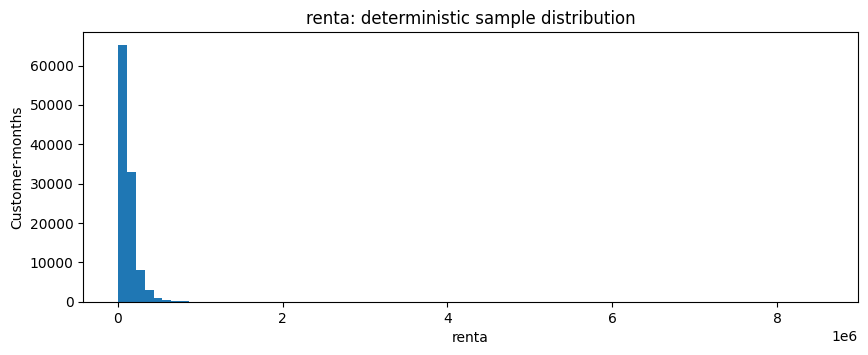

In [63]:
# Logic: draw the numeric distribution on a deterministic customer sample to make shape and tails visible.
_sample_renta = q("SELECT TRY_CAST(renta AS DOUBLE) AS value FROM read_parquet(?) WHERE hash(ncodpers) % 100 = 0 AND TRY_CAST(renta AS DOUBLE) IS NOT NULL LIMIT 200000", str(TRAIN_PARQUET))
ax = _sample_renta["value"].plot.hist(bins=80, figsize=(10, 3.5), color="#1f77b4", title="renta: deterministic sample distribution")
ax.set(xlabel="renta", ylabel="Customer-months")
plt.show()

**Insight — distribution, outliers and transformation**

In [64]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("renta", "numeric", renta_describe)

**Insight.** Median = **101,850.00**, P01–P99 = **26,449.65–554,795.00**; **6.076%** nằm ngoài Tukey fences. Giữ biến numeric gốc, thêm outlier flag/clip theo percentile; chỉ tạo bins như feature bổ sung khi temporal validation có lợi.

In [65]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
renta_associations = deep_association_table("renta")
display(renta_associations)

,partner,measure,score
0,age,Spearman rho,0.1775


#### Tổng hợp, kết luận — renta

**Kết luận thao tác.** Renta quan sát được ổn định qua các tháng liên tiếp. Past-only fill chỉ áp dụng khi customer đã có giá trị trước đó; phần chưa từng quan sát dùng median/group-median fit trong training fold + renta_is_missing. Thử log1p và percentile clipping trên train.

#### renta — month-to-month stability check

Kiểm tra trực tiếp tỷ lệ thay đổi thu nhập giữa hai snapshot liên tiếp của cùng customer, để đánh giá tính hợp lý của forward-fill.

In [66]:
# Logic: quantify observed month-to-month renta changes using only customer-month pairs with values in both consecutive snapshots.

renta_change_by_month = q("""
    WITH ordered AS (
        SELECT
            ncodpers,
            fecha_dato,
            TRY_CAST(renta AS DOUBLE) AS renta_value,
            LAG(TRY_CAST(renta AS DOUBLE)) OVER (
                PARTITION BY ncodpers
                ORDER BY fecha_dato
            ) AS previous_renta
        FROM read_parquet(?)
    )
    SELECT
        fecha_dato,
        COUNT(*) AS comparable_records,
        SUM(CASE WHEN renta_value <> previous_renta THEN 1 ELSE 0 END) AS changed_records,
        ROUND(
            100.0 * SUM(CASE WHEN renta_value <> previous_renta THEN 1 ELSE 0 END) / COUNT(*),
            3
        ) AS changed_pct,
        quantile_cont(
            ABS(renta_value - previous_renta) / NULLIF(ABS(previous_renta), 0),
            0.5
        ) AS median_relative_change
    FROM ordered
    WHERE renta_value IS NOT NULL AND previous_renta IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""", str(TRAIN_PARQUET))

display(renta_change_by_month)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fecha_dato,comparable_records,changed_records,changed_pct,median_relative_change
0,2015-02-28,512750,0.0,0.0,0.0
1,2015-03-28,515264,0.0,0.0,0.0
2,2015-04-28,517343,0.0,0.0,0.0
3,2015-05-28,519207,0.0,0.0,0.0
4,2015-06-28,520996,0.0,0.0,0.0
5,2015-07-28,528908,0.0,0.0,0.0
6,2015-08-28,687271,0.0,0.0,0.0
7,2015-09-28,698970,0.0,0.0,0.0
8,2015-10-28,708935,0.0,0.0,0.0
9,2015-11-28,707811,0.0,0.0,0.0


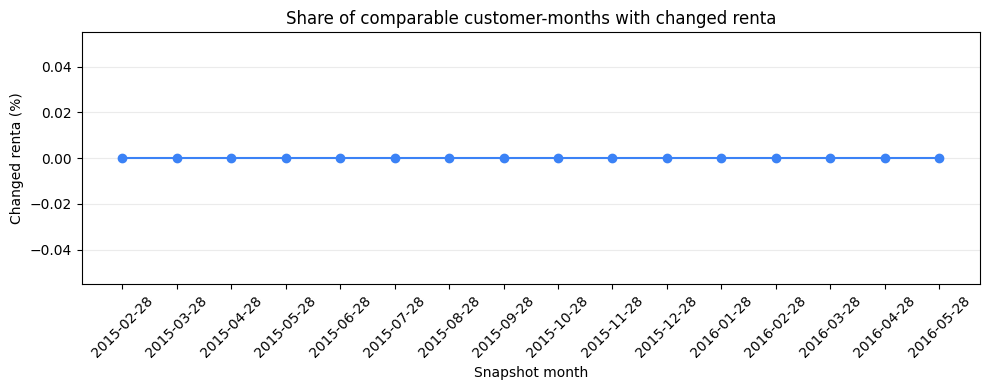

In [67]:
# Logic: visualize how often observed renta changes by snapshot; this assesses whether past-only carry-forward is a defensible candidate.

if renta_change_by_month.empty:
    print("No consecutive customer-month pairs with observed renta in both snapshots.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        renta_change_by_month["fecha_dato"].astype(str),
        renta_change_by_month["changed_pct"],
        marker="o",
        color="#3b82f6",
    )
    ax.set_title("Share of comparable customer-months with changed renta")
    ax.set_xlabel("Snapshot month")
    ax.set_ylabel("Changed renta (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

In [68]:
# Logic: summarize observed renta stability while separating historical carry-forward from residual customer-level missingness.

from IPython.display import Markdown, display

_renta_weighted_change_pct = (
    100.0 * renta_change_by_month["changed_records"].sum()
    / renta_change_by_month["comparable_records"].sum()
)
display(Markdown(
    f"**Insight.** Trên các cặp customer-month có renta quan sát được ở cả hai tháng, "
    f"**{_renta_weighted_change_pct:.3f}%** thay đổi giá trị. "
    "Renta quan sát được vì vậy ổn định theo lịch sử; past-only fill là ứng viên cho gap sau một quan sát trước đó. "
    "Tuy nhiên, phần missing chưa từng có giá trị vẫn cần imputation fit trong training fold và missing flag."
))

**Insight.** Trên các cặp customer-month có renta quan sát được ở cả hai tháng, **0.000%** thay đổi giá trị. Renta quan sát được vì vậy ổn định theo lịch sử; past-only fill là ứng viên cho gap sau một quan sát trước đó. Tuy nhiên, phần missing chưa từng có giá trị vẫn cần imputation fit trong training fold và missing flag.

In [69]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("renta", renta_associations)

**Insight.** Association mạnh nhất trong các ứng viên là age (Spearman rho = **0.177**). Đây là ứng viên interaction, không phải bằng chứng nhân quả.

### conyuemp — Vợ/chồng là nhân viên ngân hàng

Biến categorical; kiểm tra missing, mức giá trị, phân phối và cách encode.

In [70]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
conyuemp_overview = deep_overview("conyuemp")
display(conyuemp_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,13645501.0,99.987,2


**Insight — completeness & cardinality**

In [71]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("conyuemp", conyuemp_overview)

**Insight.** conyuemp có **13,645,501** giá trị thiếu (**99.987%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [72]:
# Logic: test whether missingness changes by monthly snapshot.
conyuemp_missing_by_month = deep_missing_by_month("conyuemp")
display(conyuemp_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,625368.0,99.986
1,2015-02-28,627394,627305.0,99.986
2,2015-03-28,629209,629122.0,99.986
3,2015-04-28,630367,630280.0,99.986
4,2015-05-28,631957,631869.0,99.986
5,2015-06-28,632110,632021.0,99.986
6,2015-07-28,829817,829698.0,99.986
7,2015-08-28,843201,843084.0,99.986
8,2015-09-28,865440,865320.0,99.986
9,2015-10-28,892251,892138.0,99.987


In [73]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
conyuemp_history_missing = deep_history_missing("conyuemp")
display(conyuemp_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,13645501.0,895.0,0.01


In [74]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
conyuemp_missing_by_ind_empleado = deep_missing_by_driver("conyuemp", "ind_empleado")
display(conyuemp_missing_by_ind_empleado)

,ind_empleado,rows,missing_count,missing_pct
0,N,13610977,13610361.0,99.995
1,__MISSING__,27734,27734.0,100.000
2,B,3566,2981.0,83.595
3,F,2523,2086.0,82.679
4,A,2492,2322.0,93.178
5,S,17,17.0,100.000


**Insight — missingness hypothesis and treatment**

In [75]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("conyuemp", conyuemp_history_missing, "ind_empleado")

**Insight.** Có **13,645,501** missing; **0.01%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_empleado là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [76]:
# Logic: count the most frequent categorical/date values, including physical missingness.
conyuemp_values = deep_top_values("conyuemp")
display(conyuemp_values)

,value,rows,pct
0,__MISSING__,13645501,99.987
1,N,1791,0.013
2,S,17,0.000


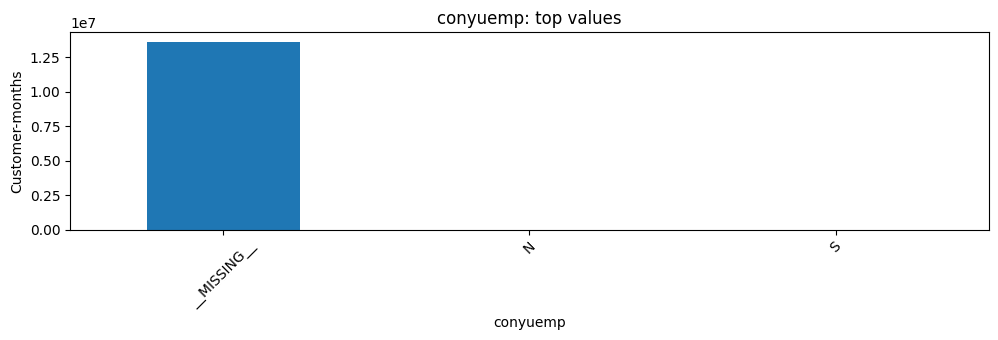

In [77]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = conyuemp_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="conyuemp: top values")
ax.set(xlabel="conyuemp", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [78]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("conyuemp", "categorical", conyuemp_values)

**Insight.** Giá trị phổ biến nhất là __MISSING__ với **99.987%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [79]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
conyuemp_associations = deep_association_table("conyuemp")
display(conyuemp_associations)

,candidate_partner,how_to_combine
0,ind_empleado,Validate as an interaction with time-based split.
1,sexo,Validate as an interaction with time-based split.
2,indfall,Validate as an interaction with time-based split.
3,segmento,Validate as an interaction with time-based split.


#### Product ownership for conyuemp = true

Đo tỷ lệ sở hữu từng sản phẩm ở cấp customer. Mỗi customer chỉ đóng góp snapshot mới nhất mà conyuemp được ghi nhận là true, tránh đếm lặp customer qua nhiều tháng.

In [80]:
# Logic: select one latest conyuemp=true snapshot per customer and calculate ownership percentage for every product.
_conyuemp_true_condition = "UPPER(TRIM(CAST(conyuemp AS VARCHAR))) IN ('S', '1', 'TRUE', 'Y', 'YES')"
_conyuemp_product_sums = ", ".join(
    f"SUM(COALESCE(TRY_CAST({quote_identifier(product)} AS INTEGER), 0)) AS {quote_identifier(product)}"
    for product in PRODUCT_COLUMNS
)
_conyuemp_true_raw = q(f"""
    WITH latest_true_snapshot AS (
        SELECT * EXCLUDE (snapshot_rank)
        FROM (
            SELECT *,
                   ROW_NUMBER() OVER (PARTITION BY ncodpers ORDER BY fecha_dato DESC) AS snapshot_rank
            FROM read_parquet(?)
            WHERE {_conyuemp_true_condition}
        )
        WHERE snapshot_rank = 1
    )
    SELECT COUNT(*) AS conyuemp_true_customers, {_conyuemp_product_sums}
    FROM latest_true_snapshot
""", str(TRAIN_PARQUET))

_conyuemp_true_n = int(_conyuemp_true_raw.loc[0, "conyuemp_true_customers"])
conyuemp_true_product_ownership = (
    _conyuemp_true_raw.drop(columns="conyuemp_true_customers")
    .T.rename(columns={0: "customer_count"})
    .rename_axis("product_column")
    .reset_index()
    .assign(
        product=lambda df: df["product_column"].map(PRODUCT_CATALOG).fillna(df["product_column"]),
        ownership_pct=lambda df: (100.0 * df["customer_count"] / _conyuemp_true_n).round(3),
    )
    .sort_values("ownership_pct", ascending=False)
)
display(pd.DataFrame({"conyuemp_true_customers": [_conyuemp_true_n]}))
display(conyuemp_true_product_ownership)

,conyuemp_true_customers
0,1


,product_column,customer_count,product,ownership_pct
4,ind_cno_fin_ult1,1.0,Tài khoản trả lương,100.0
21,ind_nomina_ult1,1.0,Thu nhập từ lương,100.0
12,ind_ecue_fin_ult1,1.0,Tài khoản điện tử (e-Account),100.0
22,ind_nom_pens_ult1,1.0,Thu nhập hưu trí,100.0
19,ind_valo_fin_ult1,1.0,Chứng khoán,100.0
15,ind_plan_fin_ult1,1.0,Kế hoạch hưu trí,100.0
2,ind_cco_fin_ult1,0.0,Tài khoản thanh toán,0.0
0,ind_ahor_fin_ult1,0.0,Tài khoản tiết kiệm,0.0
7,ind_ctop_fin_ult1,0.0,Tài khoản cá nhân,0.0
6,ind_ctma_fin_ult1,0.0,Tài khoản Más Particular,0.0


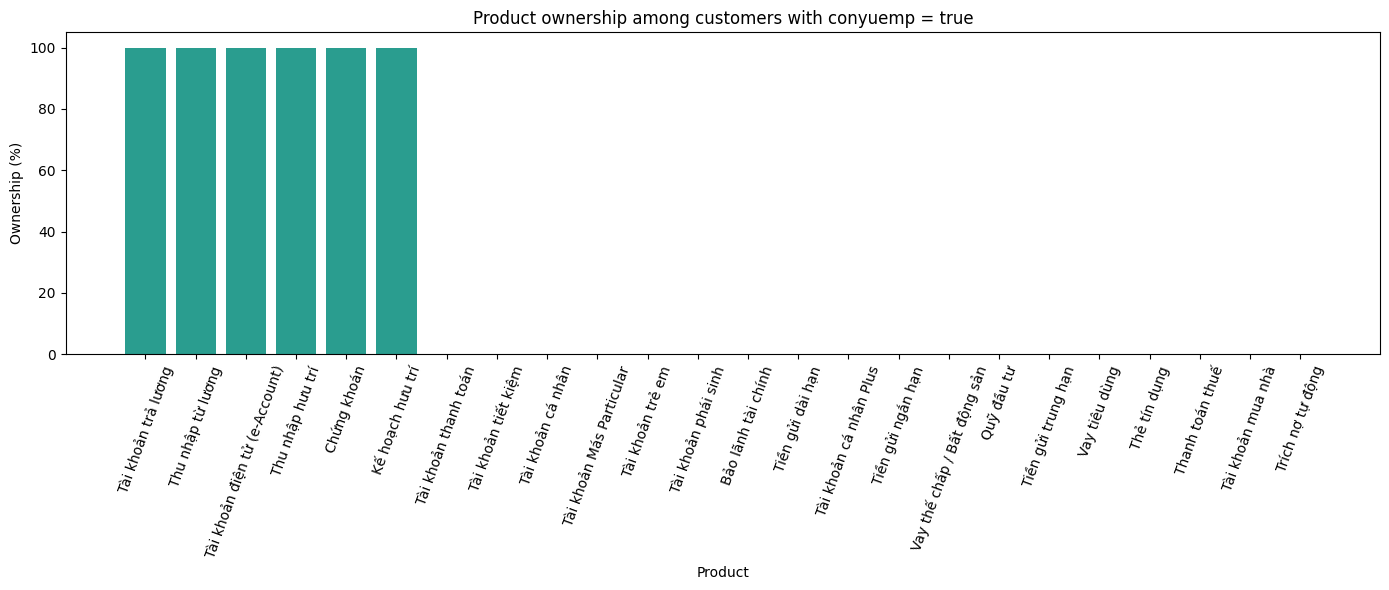

In [81]:
# Logic: visualize product ownership percentages for customers whose conyuemp is true.
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    conyuemp_true_product_ownership["product"],
    conyuemp_true_product_ownership["ownership_pct"],
    color="#2a9d8f",
)
ax.set(
    title="Product ownership among customers with conyuemp = true",
    xlabel="Product",
    ylabel="Ownership (%)",
)
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

**Insight — product profile of conyuemp = true customers**

In [82]:
# Logic: report the cohort size and highest-ownership products so the chart is interpreted with its small-sample caveat.
from IPython.display import Markdown, display
_conyuemp_top_products = conyuemp_true_product_ownership.head(5)
_conyuemp_top_text = ", ".join(
    f"{row.product} ({row.ownership_pct:.2f}%)"
    for row in _conyuemp_top_products.itertuples()
)
display(Markdown(
    f"**Insight.** Cohort có **{_conyuemp_true_n:,}** customer tại snapshot true mới nhất. "
    f"Năm sản phẩm có tỷ lệ sở hữu cao nhất: {_conyuemp_top_text}. "
    "Do conyuemp thiếu gần như toàn bộ, đây là mô tả cohort hiếm chứ chưa là lý do để impute hoặc giữ feature; "
    "chỉ dùng làm evidence để quyết định có signal đủ mạnh qua temporal validation hay không."
))

**Insight.** Cohort có **1** customer tại snapshot true mới nhất. Năm sản phẩm có tỷ lệ sở hữu cao nhất: Tài khoản trả lương (100.00%), Thu nhập từ lương (100.00%), Tài khoản điện tử (e-Account) (100.00%), Thu nhập hưu trí (100.00%), Chứng khoán (100.00%). Do conyuemp thiếu gần như toàn bộ, đây là mô tả cohort hiếm chứ chưa là lý do để impute hoặc giữ feature; chỉ dùng làm evidence để quyết định có signal đủ mạnh qua temporal validation hay không.

#### Tổng hợp, kết luận — conyuemp

**Kết luận thao tác.** Do missing gần như toàn bộ, bỏ value feature ở baseline; không đổi null thành false. Chỉ thử missing category/flag nếu validation thời gian chứng minh có lợi.

#### conyuemp × ind_empleado — observed-state matrix

Kiểm tra trực tiếp mối quan hệ domain giữa vợ/chồng là nhân viên và tình trạng nhân viên của customer. Chỉ phân tích record có conyuemp quan sát được vì feature này cực sparse.

In [83]:
# Logic: quantify conyuemp coverage and cross-tab observed spouse values with ind_empleado, without treating null as false.
conyuemp_employee_coverage = q("""
    SELECT COUNT(*) AS all_records,
           SUM(conyuemp IS NOT NULL) AS conyuemp_observed_records,
           ROUND(100.0 * AVG(CASE WHEN conyuemp IS NOT NULL THEN 1 ELSE 0 END), 4) AS conyuemp_observed_pct
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
conyuemp_employee_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(ind_empleado AS VARCHAR), '<MISSING>') AS ind_empleado_state,
               CAST(conyuemp AS VARCHAR) AS conyuemp_state
        FROM read_parquet(?)
        WHERE conyuemp IS NOT NULL
    ),
    counts AS (
        SELECT ind_empleado_state, conyuemp_state, COUNT(*) AS records
        FROM base GROUP BY 1, 2
    )
    SELECT ind_empleado_state, conyuemp_state, records,
           ROUND(100.0 * records / SUM(records) OVER (PARTITION BY ind_empleado_state), 3) AS row_pct
    FROM counts
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
conyuemp_employee_row_pct = conyuemp_employee_cross.pivot(index="ind_empleado_state", columns="conyuemp_state", values="row_pct").fillna(0)
display(conyuemp_employee_coverage)
display(conyuemp_employee_cross)
display(conyuemp_employee_row_pct.round(3))

,all_records,conyuemp_observed_records,conyuemp_observed_pct
0,13647309,1808.0,0.0132


,ind_empleado_state,conyuemp_state,records,row_pct
0,A,N,170,100.00
1,B,N,585,100.00
2,F,N,437,100.00
3,N,N,599,97.24
4,N,S,17,2.76


conyuemp_state,N,S
ind_empleado_state,,
A,100.00,0.00
B,100.00,0.00
F,100.00,0.00
N,97.24,2.76


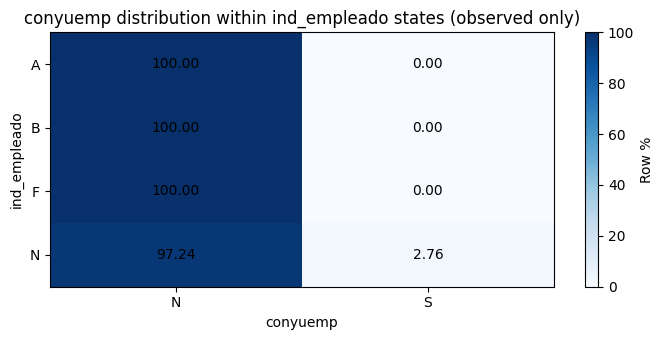

In [84]:
# Logic: visualize the observed-only spouse/employee distribution while preserving the coverage caveat.
fig, ax = plt.subplots(figsize=(7, max(3.5, 0.45 * len(conyuemp_employee_row_pct))))
image = ax.imshow(conyuemp_employee_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="conyuemp distribution within ind_empleado states (observed only)",
    xlabel="conyuemp", ylabel="ind_empleado",
    xticks=range(len(conyuemp_employee_row_pct.columns)), xticklabels=conyuemp_employee_row_pct.columns,
    yticks=range(len(conyuemp_employee_row_pct.index)), yticklabels=conyuemp_employee_row_pct.index,
)
for row in range(conyuemp_employee_row_pct.shape[0]):
    for col in range(conyuemp_employee_row_pct.shape[1]):
        ax.text(col, row, f"{conyuemp_employee_row_pct.iloc[row, col]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [85]:
# Logic: prevent over-interpreting observed-only association when conyuemp coverage is extremely small.
from IPython.display import Markdown, display
_cony_coverage = float(conyuemp_employee_coverage.loc[0, "conyuemp_observed_pct"])
display(Markdown(
    f"**Insight.** conyuemp chỉ được quan sát ở **{_cony_coverage:.4f}%** record. "
    "Matrix mô tả nhóm quan sát được nhưng không đủ bằng chứng để giữ interaction employee × spouse mặc định; "
    "baseline nên drop conyuemp hoặc chỉ giữ missingness treatment nếu temporal validation chứng minh ích lợi."
))

**Insight.** conyuemp chỉ được quan sát ở **0.0132%** record. Matrix mô tả nhóm quan sát được nhưng không đủ bằng chứng để giữ interaction employee × spouse mặc định; baseline nên drop conyuemp hoặc chỉ giữ missingness treatment nếu temporal validation chứng minh ích lợi.

In [86]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("conyuemp", conyuemp_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_nuevo — Cờ khách hàng mới

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [87]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_nuevo_overview = deep_overview("ind_nuevo")
display(ind_nuevo_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [88]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_nuevo", ind_nuevo_overview)

**Insight.** ind_nuevo có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [89]:
# Logic: test whether missingness changes by monthly snapshot.
ind_nuevo_missing_by_month = deep_missing_by_month("ind_nuevo")
display(ind_nuevo_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [90]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_nuevo_history_missing = deep_history_missing("ind_nuevo")
display(ind_nuevo_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [91]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_nuevo_missing_by_antiguedad = deep_missing_by_driver("ind_nuevo", "antiguedad")
display(ind_nuevo_missing_by_antiguedad)

,antiguedad,rows,missing_count,missing_pct
0,12,243160,0.0,0.0
1,21,214795,0.0,0.0
2,10,206165,0.0,0.0
3,9,177957,0.0,0.0
4,23,177839,0.0,0.0
5,33,174352,0.0,0.0
6,45,168847,0.0,0.0
7,24,167059,0.0,0.0
8,36,164425,0.0,0.0
9,8,155703,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [92]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_nuevo", ind_nuevo_history_missing, "antiguedad")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo antiguedad là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [93]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_nuevo_values = deep_top_values("ind_nuevo")
display(ind_nuevo_values)

,value,rows,pct
0,0,12808368,93.853
1,1,811207,5.944
2,__MISSING__,27734,0.203


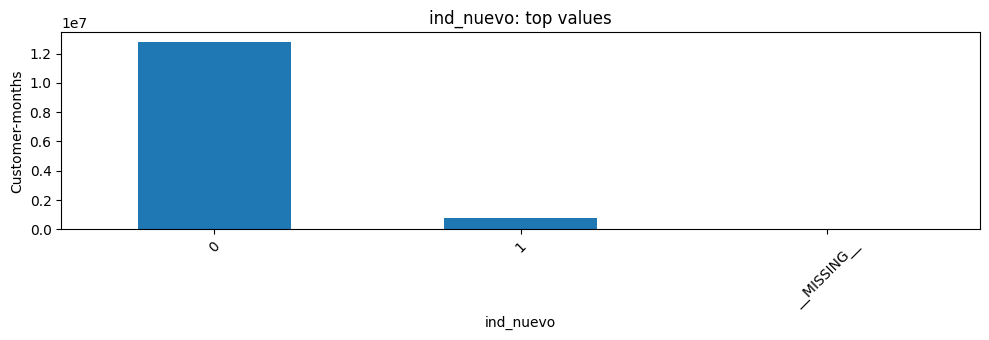

In [94]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_nuevo_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_nuevo: top values")
ax.set(xlabel="ind_nuevo", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [95]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_nuevo", "categorical", ind_nuevo_values)

**Insight.** Giá trị phổ biến nhất là 0 với **93.853%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [96]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_nuevo_associations = deep_association_table("ind_nuevo")
display(ind_nuevo_associations)

,candidate_partner,how_to_combine
0,antiguedad,Validate as an interaction with time-based split.
1,fecha_alta,Validate as an interaction with time-based split.
2,age,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ind_nuevo

**Kết luận thao tác.** Giữ như categorical binary với missing riêng; không forward-fill trạng thái tháng. Có thể thử interaction với antiguedad hoặc fecha_alta.

#### ind_nuevo × tenure / opening date / entry channel

Kiểm tra trực tiếp liệu cờ khách hàng mới có nhất quán với thâm niên, ngày mở tài khoản và channel gia nhập hay không.

In [97]:
# Logic: summarize tenure/account age by ind_nuevo and calculate new-customer prevalence in high-volume entry channels.
ind_nuevo_profile_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(ind_nuevo AS VARCHAR), '<MISSING>') AS ind_nuevo_state,
               TRY_CAST(antiguedad AS DOUBLE) AS tenure_value,
               TRY_CAST(fecha_alta AS DATE) AS opening_date,
               fecha_dato
        FROM read_parquet(?)
    )
    SELECT ind_nuevo_state, COUNT(*) AS records,
           quantile_cont(tenure_value, 0.5) FILTER (WHERE tenure_value >= 0) AS median_tenure_months,
           quantile_cont(DATE_DIFF('day', opening_date, fecha_dato), 0.5)
             FILTER (WHERE opening_date IS NOT NULL) AS median_account_age_days
    FROM base
    GROUP BY 1
    ORDER BY records DESC
""", str(TRAIN_PARQUET))
ind_nuevo_channel_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(canal_entrada AS VARCHAR), '<MISSING>') AS canal_state,
               TRY_CAST(ind_nuevo AS INTEGER) AS ind_nuevo_value
        FROM read_parquet(?)
    )
    SELECT canal_state, COUNT(*) AS records,
           ROUND(100.0 * AVG(CASE WHEN ind_nuevo_value = 1 THEN 1 ELSE 0 END), 3) AS ind_nuevo_pct
    FROM base
    GROUP BY 1
    ORDER BY records DESC
    LIMIT 20
""", str(TRAIN_PARQUET))
display(ind_nuevo_profile_cross)
display(ind_nuevo_channel_cross)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ind_nuevo_state,records,median_tenure_months,median_account_age_days
0,0,12808368,55.0,1754.0
1,1,811207,3.0,88.0
2,<MISSING>,27734,NaN,NaN


,canal_state,records,ind_nuevo_pct
0,KHE,4055270,0.009
1,KAT,3268209,0.169
2,KFC,3098360,0.179
3,KHQ,591039,65.039
4,KFA,409669,1.139
5,KHK,241084,18.575
6,<MISSING>,186126,73.146
7,KHM,183924,72.735
8,KHD,116891,0.043
9,KHN,116608,66.617


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

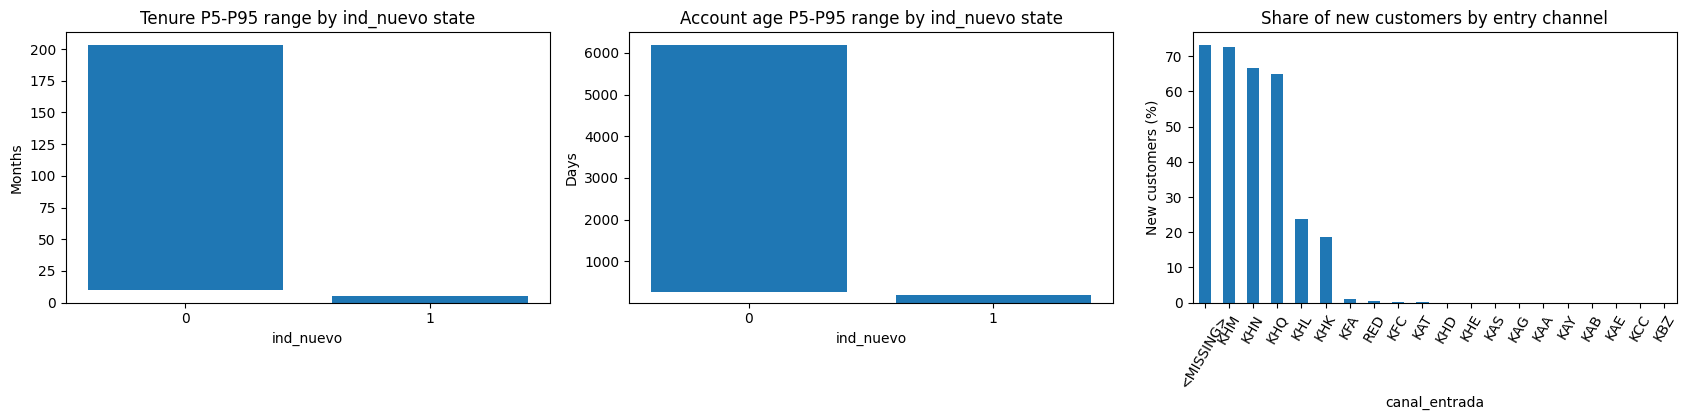

In [105]:
# Logic: show value ranges for tenure/account age and new-customer share by entry channel.
ind_nuevo_profile_cross = q("""
    SELECT COALESCE(CAST(ind_nuevo AS VARCHAR), '__MISSING__') AS ind_nuevo_state,
           MIN(TRY_CAST(antiguedad AS DOUBLE)) FILTER (WHERE TRY_CAST(antiguedad AS DOUBLE) >= 0) AS min_tenure_months,
           QUANTILE_CONT(TRY_CAST(antiguedad AS DOUBLE), 0.05) FILTER (WHERE TRY_CAST(antiguedad AS DOUBLE) >= 0) AS p05_tenure_months,
           QUANTILE_CONT(TRY_CAST(antiguedad AS DOUBLE), 0.95) FILTER (WHERE TRY_CAST(antiguedad AS DOUBLE) >= 0) AS p95_tenure_months,
           MAX(TRY_CAST(antiguedad AS DOUBLE)) FILTER (WHERE TRY_CAST(antiguedad AS DOUBLE) >= 0) AS max_tenure_months,
           MIN(DATE_DIFF('day', TRY_CAST(fecha_alta AS DATE), TRY_CAST(fecha_dato AS DATE))) AS min_account_age_days,
           QUANTILE_CONT(DATE_DIFF('day', TRY_CAST(fecha_alta AS DATE), TRY_CAST(fecha_dato AS DATE)), 0.05) AS p05_account_age_days,
           QUANTILE_CONT(DATE_DIFF('day', TRY_CAST(fecha_alta AS DATE), TRY_CAST(fecha_dato AS DATE)), 0.95) AS p95_account_age_days,
           MAX(DATE_DIFF('day', TRY_CAST(fecha_alta AS DATE), TRY_CAST(fecha_dato AS DATE))) AS max_account_age_days
    FROM read_parquet(?)
    GROUP BY 1 ORDER BY 1
""", str(TRAIN_PARQUET))

# Logic: show value ranges for tenure/account age and new-customer share by entry channel.

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))

p = ind_nuevo_profile_cross.dropna(subset=["p05_tenure_months", "p95_tenure_months"])
axes[0].bar(p["ind_nuevo_state"], p["p95_tenure_months"] - p["p05_tenure_months"], bottom=p["p05_tenure_months"])
axes[0].set(title="Tenure P5-P95 range by ind_nuevo state", xlabel="ind_nuevo", ylabel="Months")

p = ind_nuevo_profile_cross.dropna(subset=["p05_account_age_days", "p95_account_age_days"])
axes[1].bar(p["ind_nuevo_state"], p["p95_account_age_days"] - p["p05_account_age_days"], bottom=p["p05_account_age_days"])
axes[1].set(title="Account age P5-P95 range by ind_nuevo state", xlabel="ind_nuevo", ylabel="Days")

ind_nuevo_channel_cross.sort_values("ind_nuevo_pct", ascending=False).plot.bar(x="canal_state", y="ind_nuevo_pct", legend=False, ax=axes[2])
axes[2].set(title="Share of new customers by entry channel", xlabel="canal_entrada", ylabel="New customers (%)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

In [107]:
display(ind_nuevo_profile_cross[[
    "ind_nuevo_state",
    "min_tenure_months", "p05_tenure_months", "p95_tenure_months", "max_tenure_months",
    "min_account_age_days", "p05_account_age_days", "p95_account_age_days", "max_account_age_days"
]])

,ind_nuevo_state,min_tenure_months,p05_tenure_months,p95_tenure_months,max_tenure_months,min_account_age_days,p05_account_age_days,p95_account_age_days,max_account_age_days
0,0,6.0,10.0,203.0,256.0,-3,262.0,6186.0,7803
1,1,0.0,0.0,5.0,6.0,-3,6.0,179.0,7675
2,__MISSING__,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>


In [108]:
# Logic: describe the consistency check without using future snapshots or forward-filled new-customer status.
from IPython.display import Markdown, display
display(Markdown(
    f"**Insight.** Có **{len(ind_nuevo_profile_cross):,}** trạng thái ind_nuevo quan sát được. "
    "So sánh tenure/account age kiểm tra consistency của cờ new; channel variation chỉ là candidate interaction. "
    "Không dùng thông tin tương lai hoặc forward-fill trạng thái new qua các snapshot."
))

**Insight.** Có **3** trạng thái ind_nuevo quan sát được. So sánh tenure/account age kiểm tra consistency của cờ new; channel variation chỉ là candidate interaction. Không dùng thông tin tương lai hoặc forward-fill trạng thái new qua các snapshot.

In [109]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_nuevo", ind_nuevo_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indrel — Trạng thái khách hàng chính

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [110]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indrel_overview = deep_overview("indrel")
display(indrel_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [111]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indrel", indrel_overview)

**Insight.** indrel có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [112]:
# Logic: test whether missingness changes by monthly snapshot.
indrel_missing_by_month = deep_missing_by_month("indrel")
display(indrel_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [113]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indrel_history_missing = deep_history_missing("indrel")
display(indrel_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [114]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indrel_missing_by_indrel_1mes = deep_missing_by_driver("indrel", "indrel_1mes")
display(indrel_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,0.0,0.000
1,1,4357298,0.0,0.000
2,__MISSING__,149781,27734.0,18.516
3,3.0,2780,0.0,0.000
4,3,1570,0.0,0.000
5,P,874,0.0,0.000
6,2.0,740,0.0,0.000
7,2,577,0.0,0.000
8,4.0,223,0.0,0.000
9,4,83,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [115]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indrel", indrel_history_missing, "indrel_1mes")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [116]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indrel_values = deep_top_values("indrel")
display(indrel_values)

,value,rows,pct
0,1,13594782,99.615
1,__MISSING__,27734,0.203
2,99,24793,0.182


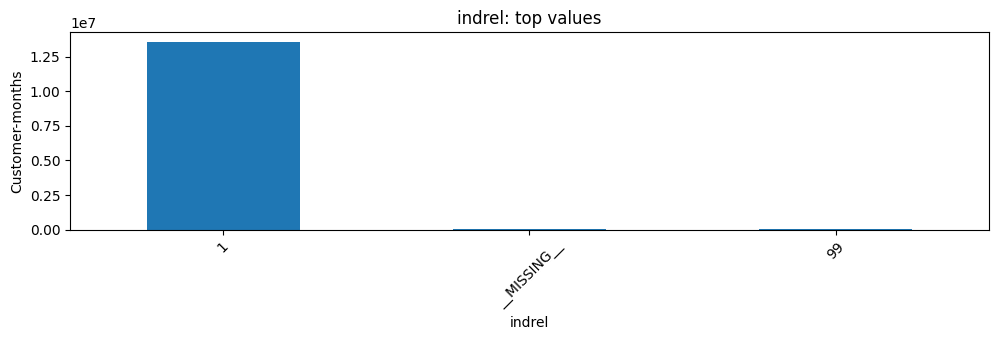

In [117]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indrel_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indrel: top values")
ax.set(xlabel="indrel", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [118]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indrel", "categorical", indrel_values)

**Insight.** Giá trị phổ biến nhất là 1 với **99.615%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [119]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indrel_associations = deep_association_table("indrel")
display(indrel_associations)

,candidate_partner,how_to_combine
0,indrel_1mes,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### indrel × indrel_1mes — confusion matrix

Hai feature đều liên quan relationship status nhưng dùng các code khác nhau. Vì vậy matrix được dùng để phát hiện tổ hợp bất thường/missing pattern; không tự coi các code khác nhau là conflict literal.

In [120]:
# Logic: build count and row-normalized confusion matrices for indrel and indrel_1mes; keep missing as an explicit state.

indrel_confusion_long = q("""
    SELECT
        COALESCE(CAST(indrel AS VARCHAR), '__MISSING__') AS indrel,
        COALESCE(CAST(indrel_1mes AS VARCHAR), '__MISSING__') AS indrel_1mes,
        COUNT(*) AS rows,
        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
                PARTITION BY COALESCE(CAST(indrel AS VARCHAR), '__MISSING__')
            ),
            3
        ) AS pct_within_indrel
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY indrel, rows DESC
""", str(TRAIN_PARQUET))

indrel_confusion_count = (
    indrel_confusion_long
    .pivot(index="indrel", columns="indrel_1mes", values="rows")
    .fillna(0)
    .astype("int64")
)
indrel_confusion_row_pct = (
    indrel_confusion_long
    .pivot(index="indrel", columns="indrel_1mes", values="pct_within_indrel")
    .fillna(0)
)

display(indrel_confusion_count)
display(indrel_confusion_row_pct)

indrel_1mes,1,1.0,2,2.0,3,3.0,4,4.0,P,__MISSING__
indrel,,,,,,,,,,
1,4348682,9121693,567,734,1339,2494,83,209,846,118135
99,8616,11690,10,6,231,286,0,14,28,3912
__MISSING__,0,0,0,0,0,0,0,0,0,27734


indrel_1mes,1,1.0,2,2.0,3,3.0,4,4.0,P,__MISSING__
indrel,,,,,,,,,,
1,31.988,67.097,0.004,0.005,0.010,0.018,0.001,0.002,0.006,0.869
99,34.752,47.150,0.040,0.024,0.932,1.154,0.000,0.056,0.113,15.779
__MISSING__,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,100.000


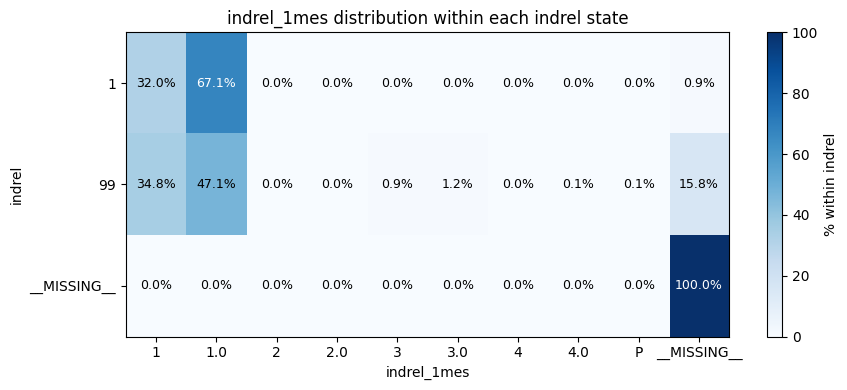

In [121]:
# Logic: visualize the row-normalized indrel × indrel_1mes matrix separately, so rare and dominant combinations are readable.

fig, ax = plt.subplots(figsize=(9, 4))
image = ax.imshow(indrel_confusion_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="indrel_1mes distribution within each indrel state",
    xlabel="indrel_1mes",
    ylabel="indrel",
    xticks=range(len(indrel_confusion_row_pct.columns)),
    xticklabels=indrel_confusion_row_pct.columns,
    yticks=range(len(indrel_confusion_row_pct.index)),
    yticklabels=indrel_confusion_row_pct.index,
)
for row_index in range(indrel_confusion_row_pct.shape[0]):
    for column_index in range(indrel_confusion_row_pct.shape[1]):
        value = indrel_confusion_row_pct.iloc[row_index, column_index]
        ax.text(
            column_index, row_index, f"{value:.1f}%",
            ha="center", va="center",
            color="white" if value > 50 else "black", fontsize=9,
        )
fig.colorbar(image, ax=ax, label="% within indrel")
plt.tight_layout()
plt.show()

**Insight — interpreting potential conflict**

In [122]:
# Logic: prevent false conflict claims by distinguishing semantic code differences from unexpected missing combinations.
from IPython.display import Markdown, display
_missing_combo_rows = int(
    indrel_confusion_long.loc[
        (indrel_confusion_long["indrel"] == "__MISSING__")
        | (indrel_confusion_long["indrel_1mes"] == "__MISSING__"),
        "rows",
    ].sum()
)
display(Markdown(
    f"**Insight.** Có **{_missing_combo_rows:,}** customer-month thuộc tổ hợp có ít nhất một giá trị missing. "
    "Không đánh dấu conflict chỉ vì indrel khác indrel_1mes: indrel_1mes có domain 1/2/3/4/P rộng hơn. "
    "Chỉ xem tổ hợp hiếm, missing pattern, hoặc tổ hợp trái với data dictionary là candidate data-quality conflict."
))

**Insight.** Có **149,781** customer-month thuộc tổ hợp có ít nhất một giá trị missing. Không đánh dấu conflict chỉ vì indrel khác indrel_1mes: indrel_1mes có domain 1/2/3/4/P rộng hơn. Chỉ xem tổ hợp hiếm, missing pattern, hoặc tổ hợp trái với data dictionary là candidate data-quality conflict.

#### Tổng hợp, kết luận — indrel

**Kết luận thao tác.** Chuẩn hóa mã rồi one-hot, giữ missing riêng. Không gộp với indrel_1mes chỉ vì mã khác; chỉ giữ interaction nếu validation thời gian cải thiện.

In [123]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indrel", indrel_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indrel_1mes — Loại khách hàng đầu tháng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [124]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indrel_1mes_overview = deep_overview("indrel_1mes")
display(indrel_1mes_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,149781.0,1.098,9


**Insight — completeness & cardinality**

In [125]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indrel_1mes", indrel_1mes_overview)

**Insight.** indrel_1mes có **149,781** giá trị thiếu (**1.098%**) và **9** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [126]:
# Logic: test whether missingness changes by monthly snapshot.
indrel_1mes_missing_by_month = deep_missing_by_month("indrel_1mes")
display(indrel_1mes_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,16405.0,1.977
7,2015-08-28,843201,11493.0,1.363
8,2015-09-28,865440,22592.0,2.610
9,2015-10-28,892251,26599.0,2.981


In [127]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indrel_1mes_history_missing = deep_history_missing("indrel_1mes")
display(indrel_1mes_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,149781.0,26.0,0.02


In [128]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indrel_1mes_missing_by_tiprel_1mes = deep_missing_by_driver("indrel_1mes", "tiprel_1mes")
display(indrel_1mes_missing_by_tiprel_1mes)

,tiprel_1mes,rows,missing_count,missing_pct
0,I,7304875,0.0,0.0
1,A,6187123,0.0,0.0
2,__MISSING__,149781,149781.0,100.0
3,P,4656,0.0,0.0
4,R,870,0.0,0.0
5,N,4,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [129]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indrel_1mes", indrel_1mes_history_missing, "tiprel_1mes")

**Insight.** Có **149,781** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo tiprel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [130]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indrel_1mes_values = deep_top_values("indrel_1mes")
display(indrel_1mes_values)

,value,rows,pct
0,1.0,9133383,66.924
1,1,4357298,31.928
2,__MISSING__,149781,1.098
3,3.0,2780,0.020
4,3,1570,0.012
5,P,874,0.006
6,2.0,740,0.005
7,2,577,0.004
8,4.0,223,0.002
9,4,83,0.001


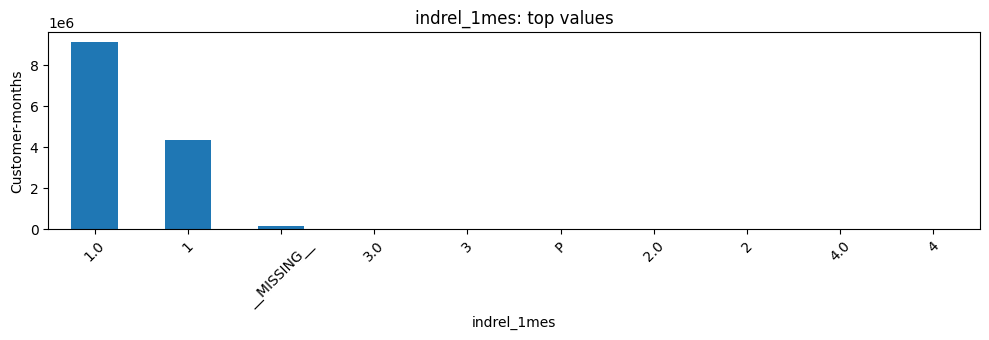

In [131]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indrel_1mes_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indrel_1mes: top values")
ax.set(xlabel="indrel_1mes", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [132]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indrel_1mes", "categorical", indrel_1mes_values)

**Insight.** Giá trị phổ biến nhất là 1.0 với **66.924%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [133]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indrel_1mes_associations = deep_association_table("indrel_1mes")
display(indrel_1mes_associations)

,candidate_partner,how_to_combine
0,indrel,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ind_nuevo,Validate as an interaction with time-based split.


#### indrel_1mes × tiprel_1mes — confusion matrix

Bảng count, tỷ lệ theo hàng và heatmap để kiểm tra các tổ hợp trạng thái; giá trị missing được giữ thành một trạng thái riêng.

In [134]:
# Logic: calculate count and row-normalized confusion matrices for indrel_1mes versus tiprel_1mes, retaining physical missingness as a level.
indrel1_tiprel_long = q("""
    SELECT
        COALESCE(CAST(indrel_1mes AS VARCHAR), '__MISSING__') AS left_state,
        COALESCE(CAST(tiprel_1mes AS VARCHAR), '__MISSING__') AS right_state,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
            PARTITION BY COALESCE(CAST(indrel_1mes AS VARCHAR), '__MISSING__')
        ), 3) AS pct_within_left_state
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY left_state, rows DESC
""", str(TRAIN_PARQUET))

indrel1_tiprel_count = indrel1_tiprel_long.pivot(index="left_state", columns="right_state", values="rows").fillna(0).astype("int64")
indrel1_tiprel_row_pct = indrel1_tiprel_long.pivot(index="left_state", columns="right_state", values="pct_within_left_state").fillna(0)
display(indrel1_tiprel_count)
display(indrel1_tiprel_row_pct)

right_state,A,I,N,P,R,__MISSING__
left_state,,,,,,
1,2034201,2323097,0,0,0,0
1.0,4151840,4981543,0,0,0,0
2,481,96,0,0,0,0
2.0,601,139,0,0,0,0
3,0,0,0,1570,0,0
3.0,0,0,0,2780,0,0
4,0,0,0,83,0,0
4.0,0,0,0,223,0,0
P,0,0,4,0,870,0


right_state,A,I,N,P,R,__MISSING__
left_state,,,,,,
1,46.685,53.315,0.000,0.0,0.000,0.0
1.0,45.458,54.542,0.000,0.0,0.000,0.0
2,83.362,16.638,0.000,0.0,0.000,0.0
2.0,81.216,18.784,0.000,0.0,0.000,0.0
3,0.000,0.000,0.000,100.0,0.000,0.0
3.0,0.000,0.000,0.000,100.0,0.000,0.0
4,0.000,0.000,0.000,100.0,0.000,0.0
4.0,0.000,0.000,0.000,100.0,0.000,0.0
P,0.000,0.000,0.458,0.0,99.542,0.0


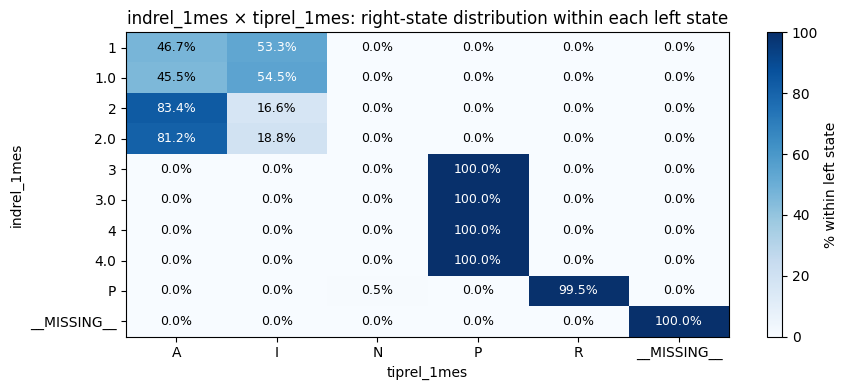

In [135]:
# Logic: visualize the row-normalized confusion matrix so rare and dominant state combinations are comparable.
fig, ax = plt.subplots(figsize=(9, 4))
_image = ax.imshow(indrel1_tiprel_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="indrel_1mes × tiprel_1mes: right-state distribution within each left state",
    xlabel="tiprel_1mes",
    ylabel="indrel_1mes",
    xticks=range(len(indrel1_tiprel_row_pct.columns)),
    xticklabels=indrel1_tiprel_row_pct.columns,
    yticks=range(len(indrel1_tiprel_row_pct.index)),
    yticklabels=indrel1_tiprel_row_pct.index,
)
for _row in range(indrel1_tiprel_row_pct.shape[0]):
    for _col in range(indrel1_tiprel_row_pct.shape[1]):
        _value = indrel1_tiprel_row_pct.iloc[_row, _col]
        ax.text(_col, _row, f"{_value:.1f}%", ha="center", va="center",
                color="white" if _value > 50 else "black", fontsize=9)
fig.colorbar(_image, ax=ax, label="% within left state")
plt.tight_layout()
plt.show()

**Insight — relationship-state consistency**

In [136]:
# Logic: identify the dominant observed mapping and retain the missing-state caveat for downstream modelling.
from IPython.display import Markdown, display
_dominant = indrel1_tiprel_long.loc[indrel1_tiprel_long["left_state"] != "__MISSING__"].sort_values("pct_within_left_state", ascending=False).iloc[0]
_missing_rows = int(indrel1_tiprel_long.loc[
    (indrel1_tiprel_long["left_state"] == "__MISSING__") | (indrel1_tiprel_long["right_state"] == "__MISSING__"),
    "rows"
].sum())
display(Markdown(
    f"**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **{_dominant.left_state} → {_dominant.right_state}** "
    f"({ _dominant.pct_within_left_state:.2f}% trong trạng thái bên trái tương ứng). "
    f"Có **{_missing_rows:,}** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định."
))

**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **3 → P** (100.00% trong trạng thái bên trái tương ứng). Có **149,781** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định.

#### Tổng hợp, kết luận — indrel_1mes

**Kết luận thao tác.** Chuẩn hóa 1 và 1.0; dùng categorical, không mặc định ordinal. Giữ missing level và kiểm tra interaction với tiprel_1mes.

In [137]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indrel_1mes", indrel_1mes_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### tiprel_1mes — Loại quan hệ khách hàng đầu tháng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [138]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
tiprel_1mes_overview = deep_overview("tiprel_1mes")
display(tiprel_1mes_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,149781.0,1.098,5


**Insight — completeness & cardinality**

In [139]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("tiprel_1mes", tiprel_1mes_overview)

**Insight.** tiprel_1mes có **149,781** giá trị thiếu (**1.098%**) và **5** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [140]:
# Logic: test whether missingness changes by monthly snapshot.
tiprel_1mes_missing_by_month = deep_missing_by_month("tiprel_1mes")
display(tiprel_1mes_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,16405.0,1.977
7,2015-08-28,843201,11493.0,1.363
8,2015-09-28,865440,22592.0,2.610
9,2015-10-28,892251,26599.0,2.981


In [141]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
tiprel_1mes_history_missing = deep_history_missing("tiprel_1mes")
display(tiprel_1mes_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,149781.0,26.0,0.02


In [142]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
tiprel_1mes_missing_by_indrel_1mes = deep_missing_by_driver("tiprel_1mes", "indrel_1mes")
display(tiprel_1mes_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,0.0,0.0
1,1,4357298,0.0,0.0
2,__MISSING__,149781,149781.0,100.0
3,3.0,2780,0.0,0.0
4,3,1570,0.0,0.0
5,P,874,0.0,0.0
6,2.0,740,0.0,0.0
7,2,577,0.0,0.0
8,4.0,223,0.0,0.0
9,4,83,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [143]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("tiprel_1mes", tiprel_1mes_history_missing, "indrel_1mes")

**Insight.** Có **149,781** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [144]:
# Logic: count the most frequent categorical/date values, including physical missingness.
tiprel_1mes_values = deep_top_values("tiprel_1mes")
display(tiprel_1mes_values)

,value,rows,pct
0,I,7304875,53.526
1,A,6187123,45.336
2,__MISSING__,149781,1.098
3,P,4656,0.034
4,R,870,0.006
5,N,4,0.000


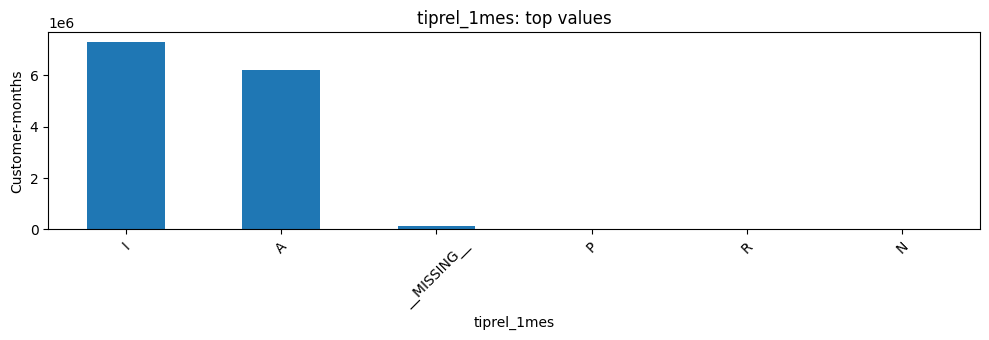

In [145]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = tiprel_1mes_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="tiprel_1mes: top values")
ax.set(xlabel="tiprel_1mes", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [146]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("tiprel_1mes", "categorical", tiprel_1mes_values)

**Insight.** Giá trị phổ biến nhất là I với **53.526%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [147]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
tiprel_1mes_associations = deep_association_table("tiprel_1mes")
display(tiprel_1mes_associations)

,candidate_partner,how_to_combine
0,indrel_1mes,Validate as an interaction with time-based split.
1,indrel,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### tiprel_1mes × ind_actividad_cliente — confusion matrix

Bảng count, tỷ lệ theo hàng và heatmap để kiểm tra các tổ hợp trạng thái; giá trị missing được giữ thành một trạng thái riêng.

In [148]:
# Logic: calculate count and row-normalized confusion matrices for tiprel_1mes versus ind_actividad_cliente, retaining physical missingness as a level.
tiprel_activity_long = q("""
    SELECT
        COALESCE(CAST(tiprel_1mes AS VARCHAR), '__MISSING__') AS left_state,
        COALESCE(CAST(ind_actividad_cliente AS VARCHAR), '__MISSING__') AS right_state,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
            PARTITION BY COALESCE(CAST(tiprel_1mes AS VARCHAR), '__MISSING__')
        ), 3) AS pct_within_left_state
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY left_state, rows DESC
""", str(TRAIN_PARQUET))

tiprel_activity_count = tiprel_activity_long.pivot(index="left_state", columns="right_state", values="rows").fillna(0).astype("int64")
tiprel_activity_row_pct = tiprel_activity_long.pivot(index="left_state", columns="right_state", values="pct_within_left_state").fillna(0)
display(tiprel_activity_count)
display(tiprel_activity_row_pct)

right_state,0,1,__MISSING__
left_state,,,
A,616758,5570365,0
I,6680778,624097,0
N,2,2,0
P,2638,2018,0
R,441,429,0
__MISSING__,83773,38274,27734


right_state,0,1,__MISSING__
left_state,,,
A,9.968,90.032,0.000
I,91.456,8.544,0.000
N,50.000,50.000,0.000
P,56.658,43.342,0.000
R,50.690,49.310,0.000
__MISSING__,55.930,25.553,18.516


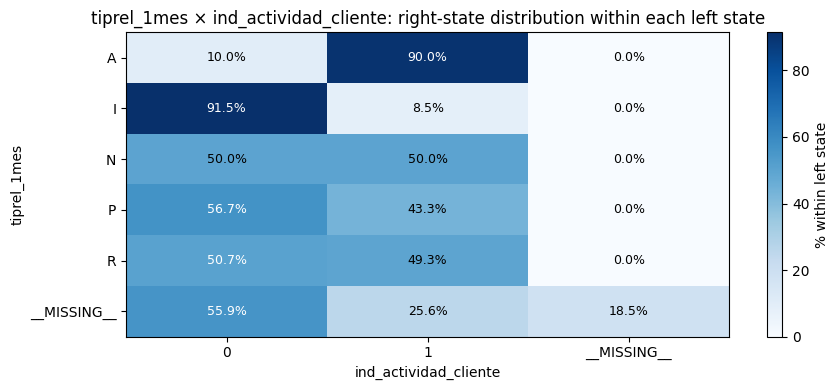

In [149]:
# Logic: visualize the row-normalized confusion matrix so rare and dominant state combinations are comparable.
fig, ax = plt.subplots(figsize=(9, 4))
_image = ax.imshow(tiprel_activity_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="tiprel_1mes × ind_actividad_cliente: right-state distribution within each left state",
    xlabel="ind_actividad_cliente",
    ylabel="tiprel_1mes",
    xticks=range(len(tiprel_activity_row_pct.columns)),
    xticklabels=tiprel_activity_row_pct.columns,
    yticks=range(len(tiprel_activity_row_pct.index)),
    yticklabels=tiprel_activity_row_pct.index,
)
for _row in range(tiprel_activity_row_pct.shape[0]):
    for _col in range(tiprel_activity_row_pct.shape[1]):
        _value = tiprel_activity_row_pct.iloc[_row, _col]
        ax.text(_col, _row, f"{_value:.1f}%", ha="center", va="center",
                color="white" if _value > 50 else "black", fontsize=9)
fig.colorbar(_image, ax=ax, label="% within left state")
plt.tight_layout()
plt.show()

**Insight — relationship-state consistency**

In [150]:
# Logic: identify the dominant observed mapping and retain the missing-state caveat for downstream modelling.
from IPython.display import Markdown, display
_dominant = tiprel_activity_long.loc[tiprel_activity_long["left_state"] != "__MISSING__"].sort_values("pct_within_left_state", ascending=False).iloc[0]
_missing_rows = int(tiprel_activity_long.loc[
    (tiprel_activity_long["left_state"] == "__MISSING__") | (tiprel_activity_long["right_state"] == "__MISSING__"),
    "rows"
].sum())
display(Markdown(
    f"**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **{_dominant.left_state} → {_dominant.right_state}** "
    f"({ _dominant.pct_within_left_state:.2f}% trong trạng thái bên trái tương ứng). "
    f"Có **{_missing_rows:,}** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định."
))

**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **I → 0** (91.46% trong trạng thái bên trái tương ứng). Có **149,781** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định.

#### Tổng hợp, kết luận — tiprel_1mes

**Kết luận thao tác.** Dùng categorical one-hot với missing level; mapping trạng thái là candidate interaction, không phải bằng chứng nhân quả.

In [151]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("tiprel_1mes", tiprel_1mes_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_actividad_cliente — Cờ hoạt động khách hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [152]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_actividad_cliente_overview = deep_overview("ind_actividad_cliente")
display(ind_actividad_cliente_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [153]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_actividad_cliente", ind_actividad_cliente_overview)

**Insight.** ind_actividad_cliente có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [154]:
# Logic: test whether missingness changes by monthly snapshot.
ind_actividad_cliente_missing_by_month = deep_missing_by_month("ind_actividad_cliente")
display(ind_actividad_cliente_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [155]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_actividad_cliente_history_missing = deep_history_missing("ind_actividad_cliente")
display(ind_actividad_cliente_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [156]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_actividad_cliente_missing_by_tiprel_1mes = deep_missing_by_driver("ind_actividad_cliente", "tiprel_1mes")
display(ind_actividad_cliente_missing_by_tiprel_1mes)

,tiprel_1mes,rows,missing_count,missing_pct
0,I,7304875,0.0,0.000
1,A,6187123,0.0,0.000
2,__MISSING__,149781,27734.0,18.516
3,P,4656,0.0,0.000
4,R,870,0.0,0.000
5,N,4,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [157]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_actividad_cliente", ind_actividad_cliente_history_missing, "tiprel_1mes")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo tiprel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [158]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_actividad_cliente_values = deep_top_values("ind_actividad_cliente")
display(ind_actividad_cliente_values)

,value,rows,pct
0,0,7384390,54.109
1,1,6235185,45.688
2,__MISSING__,27734,0.203


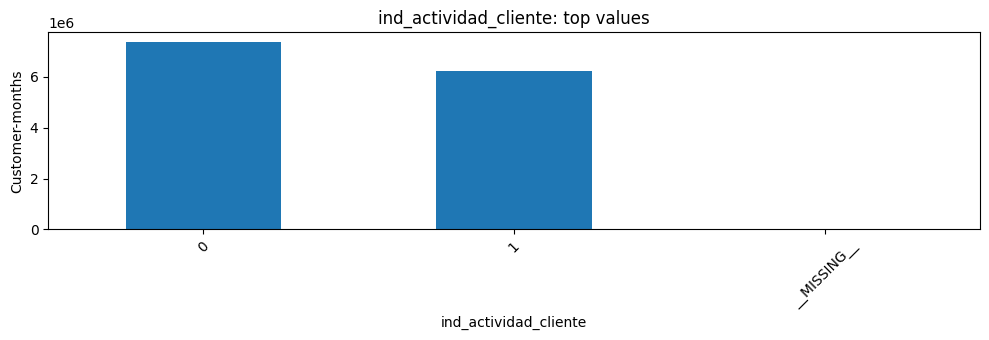

In [159]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_actividad_cliente_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_actividad_cliente: top values")
ax.set(xlabel="ind_actividad_cliente", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [160]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_actividad_cliente", "categorical", ind_actividad_cliente_values)

**Insight.** Giá trị phổ biến nhất là 0 với **54.109%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [161]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_actividad_cliente_associations = deep_association_table("ind_actividad_cliente")
display(ind_actividad_cliente_associations)

,candidate_partner,how_to_combine
0,tiprel_1mes,Validate as an interaction with time-based split.
1,indrel_1mes,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### ind_actividad_cliente × indfall — confusion matrix

Bảng count, tỷ lệ theo hàng và heatmap để kiểm tra các tổ hợp trạng thái; giá trị missing được giữ thành một trạng thái riêng.

In [162]:
# Logic: calculate count and row-normalized confusion matrices for ind_actividad_cliente versus indfall, retaining physical missingness as a level.
activity_indfall_long = q("""
    SELECT
        COALESCE(CAST(ind_actividad_cliente AS VARCHAR), '__MISSING__') AS left_state,
        COALESCE(CAST(indfall AS VARCHAR), '__MISSING__') AS right_state,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (
            PARTITION BY COALESCE(CAST(ind_actividad_cliente AS VARCHAR), '__MISSING__')
        ), 3) AS pct_within_left_state
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY left_state, rows DESC
""", str(TRAIN_PARQUET))

activity_indfall_count = activity_indfall_long.pivot(index="left_state", columns="right_state", values="rows").fillna(0).astype("int64")
activity_indfall_row_pct = activity_indfall_long.pivot(index="left_state", columns="right_state", values="pct_within_left_state").fillna(0)
display(activity_indfall_count)
display(activity_indfall_row_pct)

right_state,N,S,__MISSING__
left_state,,,
0,7365935,18455,0
1,6218878,16307,0
__MISSING__,0,0,27734


right_state,N,S,__MISSING__
left_state,,,
0,99.750,0.250,0.0
1,99.738,0.262,0.0
__MISSING__,0.000,0.000,100.0


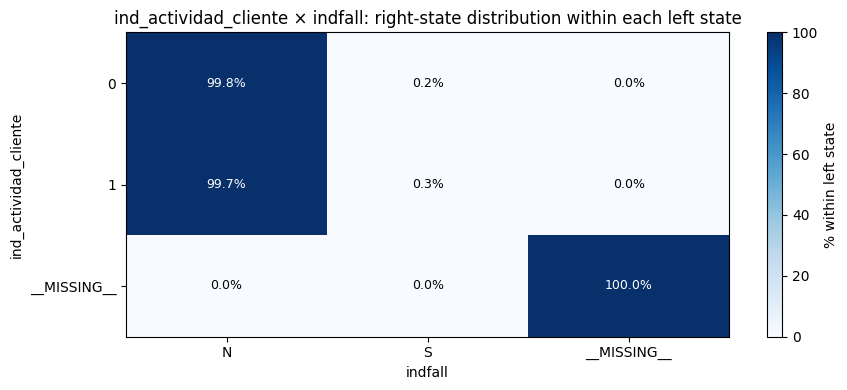

In [163]:
# Logic: visualize the row-normalized confusion matrix so rare and dominant state combinations are comparable.
fig, ax = plt.subplots(figsize=(9, 4))
_image = ax.imshow(activity_indfall_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="ind_actividad_cliente × indfall: right-state distribution within each left state",
    xlabel="indfall",
    ylabel="ind_actividad_cliente",
    xticks=range(len(activity_indfall_row_pct.columns)),
    xticklabels=activity_indfall_row_pct.columns,
    yticks=range(len(activity_indfall_row_pct.index)),
    yticklabels=activity_indfall_row_pct.index,
)
for _row in range(activity_indfall_row_pct.shape[0]):
    for _col in range(activity_indfall_row_pct.shape[1]):
        _value = activity_indfall_row_pct.iloc[_row, _col]
        ax.text(_col, _row, f"{_value:.1f}%", ha="center", va="center",
                color="white" if _value > 50 else "black", fontsize=9)
fig.colorbar(_image, ax=ax, label="% within left state")
plt.tight_layout()
plt.show()

**Insight — relationship-state consistency**

In [164]:
# Logic: identify the dominant observed mapping and retain the missing-state caveat for downstream modelling.
from IPython.display import Markdown, display
_dominant = activity_indfall_long.loc[activity_indfall_long["left_state"] != "__MISSING__"].sort_values("pct_within_left_state", ascending=False).iloc[0]
_missing_rows = int(activity_indfall_long.loc[
    (activity_indfall_long["left_state"] == "__MISSING__") | (activity_indfall_long["right_state"] == "__MISSING__"),
    "rows"
].sum())
display(Markdown(
    f"**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **{_dominant.left_state} → {_dominant.right_state}** "
    f"({ _dominant.pct_within_left_state:.2f}% trong trạng thái bên trái tương ứng). "
    f"Có **{_missing_rows:,}** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định."
))

**Insight.** Tổ hợp chiếm tỷ lệ lớn nhất là **0 → N** (99.75% trong trạng thái bên trái tương ứng). Có **27,734** customer-month chứa ít nhất một missing state; giữ missing như một level/flag thay vì coi là conflict mặc định.

#### Tổng hợp, kết luận — ind_actividad_cliente

**Kết luận thao tác.** Dùng binary/one-hot với missing level. Có thể thử interaction với tiprel_1mes và lịch sử sản phẩm.

#### ind_actividad_cliente × segmento — activity by segment

Crosstab kiểm tra liệu trạng thái hoạt động có khác biệt đáng kể theo phân khúc, trước khi thử interaction trong temporal validation.

In [165]:
# Logic: calculate active/inactive composition within each segmento state, retaining missing states rather than imputing them.
activity_segmento_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(ind_actividad_cliente AS VARCHAR), '<MISSING>') AS activity_state,
               COALESCE(CAST(segmento AS VARCHAR), '<MISSING>') AS segmento_state
        FROM read_parquet(?)
    ),
    counts AS (
        SELECT segmento_state, activity_state, COUNT(*) AS records
        FROM base
        GROUP BY 1, 2
    )
    SELECT segmento_state, activity_state, records,
           ROUND(100.0 * records / SUM(records) OVER (PARTITION BY segmento_state), 3) AS row_pct
    FROM counts
    ORDER BY segmento_state, activity_state
""", str(TRAIN_PARQUET))
activity_segmento_row_pct = activity_segmento_cross.pivot(index="segmento_state", columns="activity_state", values="row_pct").fillna(0)
display(activity_segmento_cross)
display(activity_segmento_row_pct.round(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segmento_state,activity_state,records,row_pct
0,01 - TOP,0,8804,1.566
1,01 - TOP,1,553338,98.434
2,02 - PARTICULARES,0,3798212,47.715
3,02 - PARTICULARES,1,4162008,52.285
4,03 - UNIVERSITARIO,0,3460620,70.116
5,03 - UNIVERSITARIO,1,1474959,29.884
6,<MISSING>,0,116754,61.655
7,<MISSING>,1,44880,23.700
8,<MISSING>,<MISSING>,27734,14.646


activity_state,0,1,<MISSING>
segmento_state,,,
01 - TOP,1.566,98.434,0.000
02 - PARTICULARES,47.715,52.285,0.000
03 - UNIVERSITARIO,70.116,29.884,0.000
<MISSING>,61.655,23.700,14.646


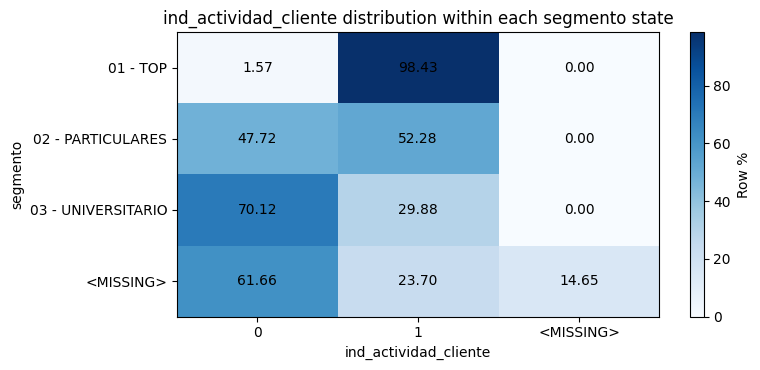

In [166]:
# Logic: visualize activity composition inside each segment to assess whether a segment interaction has empirical support.
fig, ax = plt.subplots(figsize=(8, 3.8))
image = ax.imshow(activity_segmento_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="ind_actividad_cliente distribution within each segmento state",
    xlabel="ind_actividad_cliente", ylabel="segmento",
    xticks=range(len(activity_segmento_row_pct.columns)), xticklabels=activity_segmento_row_pct.columns,
    yticks=range(len(activity_segmento_row_pct.index)), yticklabels=activity_segmento_row_pct.index,
)
for row in range(activity_segmento_row_pct.shape[0]):
    for col in range(activity_segmento_row_pct.shape[1]):
        ax.text(col, row, f"{activity_segmento_row_pct.iloc[row, col]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [167]:
# Logic: summarize segment-level activity variation as interaction-screening evidence rather than a causal conclusion.
from IPython.display import Markdown, display
_activity_states = [c for c in activity_segmento_row_pct.columns if c != '<MISSING>']
_activity_spread = max(
    (float(activity_segmento_row_pct[state].max() - activity_segmento_row_pct[state].min()) for state in _activity_states),
    default=0.0,
)
display(Markdown(
    f"**Insight.** Chênh lệch lớn nhất của một activity state giữa các segment là **{_activity_spread:.3f} điểm %**. "
    "Đây là evidence để thử interaction ind_actividad_cliente × segmento; chỉ giữ nếu time-based validation cải thiện."
))

**Insight.** Chênh lệch lớn nhất của một activity state giữa các segment là **74.734 điểm %**. Đây là evidence để thử interaction ind_actividad_cliente × segmento; chỉ giữ nếu time-based validation cải thiện.

In [168]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_actividad_cliente", ind_actividad_cliente_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ind_empleado — Chỉ số nhân viên ngân hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [169]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ind_empleado_overview = deep_overview("ind_empleado")
display(ind_empleado_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,5


**Insight — completeness & cardinality**

In [170]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ind_empleado", ind_empleado_overview)

**Insight.** ind_empleado có **27,734** giá trị thiếu (**0.203%**) và **5** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [171]:
# Logic: test whether missingness changes by monthly snapshot.
ind_empleado_missing_by_month = deep_missing_by_month("ind_empleado")
display(ind_empleado_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [172]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ind_empleado_history_missing = deep_history_missing("ind_empleado")
display(ind_empleado_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [173]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ind_empleado_missing_by_conyuemp = deep_missing_by_driver("ind_empleado", "conyuemp")
display(ind_empleado_missing_by_conyuemp)

,conyuemp,rows,missing_count,missing_pct
0,__MISSING__,13645501,27734.0,0.203
1,N,1791,0.0,0.000
2,S,17,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [174]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ind_empleado", ind_empleado_history_missing, "conyuemp")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo conyuemp là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [175]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ind_empleado_values = deep_top_values("ind_empleado")
display(ind_empleado_values)

,value,rows,pct
0,N,13610977,99.734
1,__MISSING__,27734,0.203
2,B,3566,0.026
3,F,2523,0.018
4,A,2492,0.018
5,S,17,0.000


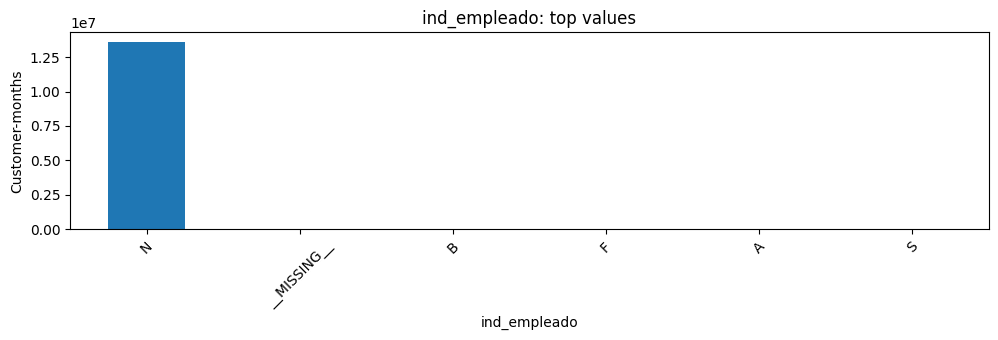

In [176]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ind_empleado_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ind_empleado: top values")
ax.set(xlabel="ind_empleado", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [177]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("ind_empleado", "categorical", ind_empleado_values)

**Insight.** Giá trị phổ biến nhất là N với **99.734%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [178]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ind_empleado_associations = deep_association_table("ind_empleado")
display(ind_empleado_associations)

,candidate_partner,how_to_combine
0,conyuemp,Validate as an interaction with time-based split.
1,canal_entrada,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,renta,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — ind_empleado

**Kết luận thao tác.** Dùng categorical one-hot và missing flag. Quan hệ với conyuemp chỉ nên coi là thử nghiệm vì conyuemp cực thưa.

In [179]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ind_empleado", ind_empleado_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indfall — Cờ đã qua đời

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [180]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
indfall_overview = deep_overview("indfall")
display(indfall_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [181]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("indfall", indfall_overview)

**Insight.** indfall có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [182]:
# Logic: test whether missingness changes by monthly snapshot.
indfall_missing_by_month = deep_missing_by_month("indfall")
display(indfall_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [183]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
indfall_history_missing = deep_history_missing("indfall")
display(indfall_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [184]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
indfall_missing_by_ind_actividad_cliente = deep_missing_by_driver("indfall", "ind_actividad_cliente")
display(indfall_missing_by_ind_actividad_cliente)

,ind_actividad_cliente,rows,missing_count,missing_pct
0,0,7384390,0.0,0.0
1,1,6235185,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [185]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("indfall", indfall_history_missing, "ind_actividad_cliente")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_actividad_cliente là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [186]:
# Logic: count the most frequent categorical/date values, including physical missingness.
indfall_values = deep_top_values("indfall")
display(indfall_values)

,value,rows,pct
0,N,13584813,99.542
1,S,34762,0.255
2,__MISSING__,27734,0.203


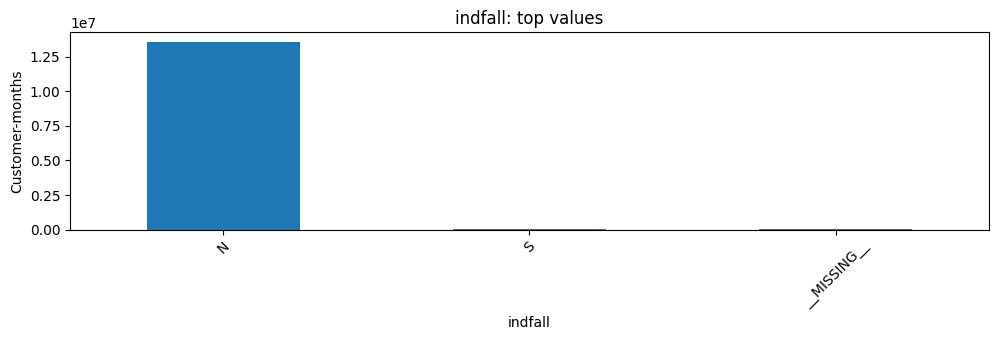

In [187]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = indfall_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="indfall: top values")
ax.set(xlabel="indfall", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [188]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("indfall", "categorical", indfall_values)

**Insight.** Giá trị phổ biến nhất là N với **99.542%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [189]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
indfall_associations = deep_association_table("indfall")
display(indfall_associations)

,candidate_partner,how_to_combine
0,ind_actividad_cliente,Validate as an interaction with time-based split.
1,tiprel_1mes,Validate as an interaction with time-based split.
2,indrel_1mes,Validate as an interaction with time-based split.
3,ult_fec_cli_1t,Validate as an interaction with time-based split.


#### New-product acquisitions by indfall cohort

Mỗi record được gán số sản phẩm mua mới bằng số product chuyển từ 0 sang 1 so với snapshot tháng trước của cùng customer. So sánh hai cohort: indfall true và indfall missing.

In [190]:
# Logic: calculate product additions from the prior customer-month, then count records by additions for indfall=true versus indfall-missing cohorts.
_prev_product_sql = ", ".join(
    f"LAG(COALESCE(TRY_CAST({quote_identifier(product)} AS INTEGER), 0)) OVER customer_window AS prev_{product}"
    for product in PRODUCT_COLUMNS
)
_new_product_count_sql = " + ".join(
    f"CASE WHEN COALESCE(TRY_CAST({quote_identifier(product)} AS INTEGER), 0) = 1 AND prev_{product} = 0 THEN 1 ELSE 0 END"
    for product in PRODUCT_COLUMNS
)
new_products_by_indfall_cohort = q(f"""
    WITH ordered AS (
        SELECT
            ncodpers,
            fecha_dato,
            indfall,
            LAG(fecha_dato) OVER customer_window AS previous_snapshot,
            {_prev_product_sql},
            {", ".join(quote_identifier(product) for product in PRODUCT_COLUMNS)}
        FROM read_parquet(?)
        WINDOW customer_window AS (PARTITION BY ncodpers ORDER BY fecha_dato)
    ),
    additions AS (
        SELECT
            CASE
                WHEN UPPER(TRIM(CAST(indfall AS VARCHAR))) IN ('S', '1', 'TRUE', 'Y', 'YES') THEN 'indfall_true'
                WHEN indfall IS NULL THEN 'indfall_missing'
            END AS cohort,
            {_new_product_count_sql} AS new_products_in_record
        FROM ordered
        WHERE previous_snapshot IS NOT NULL
          AND (
              UPPER(TRIM(CAST(indfall AS VARCHAR))) IN ('S', '1', 'TRUE', 'Y', 'YES')
              OR indfall IS NULL
          )
    )
    SELECT
        cohort,
        new_products_in_record,
        COUNT(*) AS record_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY cohort), 4) AS pct_within_cohort
    FROM additions
    GROUP BY 1, 2
    ORDER BY cohort, new_products_in_record
""", str(TRAIN_PARQUET))
display(new_products_by_indfall_cohort)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cohort,new_products_in_record,record_count,pct_within_cohort
0,indfall_missing,0,19904,97.5973
1,indfall_missing,1,458,2.2458
2,indfall_missing,2,25,0.1226
3,indfall_missing,3,7,0.0343
4,indfall_true,0,32189,98.9913
5,indfall_true,1,302,0.9287
6,indfall_true,2,25,0.0769
7,indfall_true,3,1,0.0031


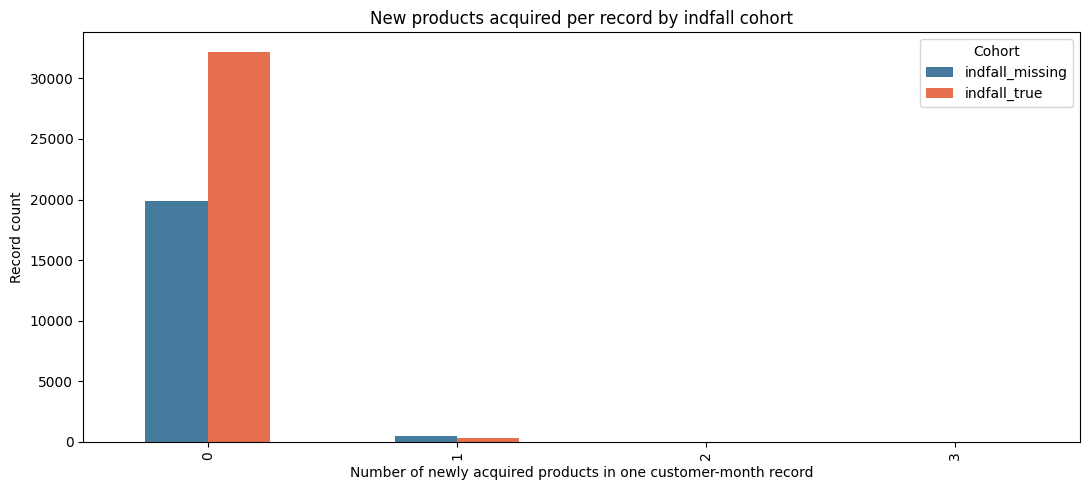

In [191]:
# Logic: plot the requested raw record-count distribution with products newly acquired per record on the x-axis.
_new_product_count_pivot = (
    new_products_by_indfall_cohort
    .pivot(index="new_products_in_record", columns="cohort", values="record_count")
    .fillna(0)
)
ax = _new_product_count_pivot.plot.bar(
    figsize=(11, 5),
    color={"indfall_true": "#e76f51", "indfall_missing": "#457b9d"},
)
ax.set(
    title="New products acquired per record by indfall cohort",
    xlabel="Number of newly acquired products in one customer-month record",
    ylabel="Record count",
)
ax.legend(title="Cohort")
plt.tight_layout()
plt.show()

**Insight — cohort-level new-product behavior**

In [192]:
# Logic: summarize cohort sizes and the share of records with at least one new product.
from IPython.display import Markdown, display
_new_product_summary = (
    new_products_by_indfall_cohort
    .groupby("cohort", as_index=False)
    .agg(
        records=("record_count", "sum"),
        records_with_new_product=("record_count", lambda s: 0),
    )
)
_new_product_positive = (
    new_products_by_indfall_cohort
    .query("new_products_in_record > 0")
    .groupby("cohort", as_index=False)["record_count"]
    .sum()
    .rename(columns={"record_count": "records_with_new_product"})
)
_new_product_summary = (
    _new_product_summary.drop(columns="records_with_new_product")
    .merge(_new_product_positive, on="cohort", how="left")
    .fillna({"records_with_new_product": 0})
)
_new_product_summary["pct_with_new_product"] = (
    100.0 * _new_product_summary["records_with_new_product"] / _new_product_summary["records"]
)
_summary_text = "; ".join(
    f"{row.cohort}: {int(row.records):,} records, {row.pct_with_new_product:.3f}% có ít nhất một sản phẩm mới"
    for row in _new_product_summary.itertuples()
)
display(Markdown(
    f"**Insight.** {_summary_text}. "
    "Đây là mô tả hành vi lịch sử; nếu indfall=true biểu thị deceased thực sự, các record đó vẫn phải bị loại khỏi recommendation eligibility ở inference."
))

**Insight.** indfall_missing: 20,394 records, 2.403% có ít nhất một sản phẩm mới; indfall_true: 32,517 records, 1.009% có ít nhất một sản phẩm mới. Đây là mô tả hành vi lịch sử; nếu indfall=true biểu thị deceased thực sự, các record đó vẫn phải bị loại khỏi recommendation eligibility ở inference.

#### New-product state of the early common-missing cohort

Cohort được định nghĩa bằng indfall missing, tức record thiếu profile đồng loạt. Cell kiểm tra cohort này có tập trung ở các snapshot đầu hay không và hành vi mua mới của cohort theo tháng.

In [193]:
# Logic: compute new-product additions per customer-month and compare the indfall-missing profile cohort with records whose indfall is observed.
_profile_missing_prev_sql = ", ".join(
    f"LAG(COALESCE(TRY_CAST({quote_identifier(product)} AS INTEGER), 0)) OVER customer_window AS prev_{product}"
    for product in PRODUCT_COLUMNS
)
_profile_missing_new_count_sql = " + ".join(
    f"CASE WHEN COALESCE(TRY_CAST({quote_identifier(product)} AS INTEGER), 0) = 1 AND prev_{product} = 0 THEN 1 ELSE 0 END"
    for product in PRODUCT_COLUMNS
)
profile_missing_new_product_by_month = q(f"""
    WITH ordered AS (
        SELECT
            ncodpers,
            fecha_dato,
            indfall,
            LAG(fecha_dato) OVER customer_window AS previous_snapshot,
            {_profile_missing_prev_sql},
            {", ".join(quote_identifier(product) for product in PRODUCT_COLUMNS)}
        FROM read_parquet(?)
        WINDOW customer_window AS (PARTITION BY ncodpers ORDER BY fecha_dato)
    ),
    additions AS (
        SELECT
            fecha_dato,
            CASE WHEN indfall IS NULL THEN 'profile_missing_indfall_missing' ELSE 'indfall_observed' END AS cohort,
            {_profile_missing_new_count_sql} AS new_products_in_record
        FROM ordered
        WHERE previous_snapshot IS NOT NULL
    )
    SELECT
        fecha_dato,
        cohort,
        COUNT(*) AS records,
        SUM(CASE WHEN new_products_in_record > 0 THEN 1 ELSE 0 END) AS records_with_new_product,
        ROUND(100.0 * AVG(CASE WHEN new_products_in_record > 0 THEN 1 ELSE 0 END), 4) AS pct_with_new_product,
        ROUND(AVG(new_products_in_record), 5) AS mean_new_products
    FROM additions
    GROUP BY 1, 2
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
display(profile_missing_new_product_by_month)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fecha_dato,cohort,records,records_with_new_product,pct_with_new_product,mean_new_products
0,2015-02-28,indfall_observed,617152,23603.0,3.8245,0.05052
1,2015-02-28,profile_missing_indfall_missing,5774,179.0,3.1001,0.03343
2,2015-03-28,indfall_observed,620231,25159.0,4.0564,0.05144
3,2015-03-28,profile_missing_indfall_missing,5002,146.0,2.9188,0.03159
4,2015-04-28,indfall_observed,622709,25574.0,4.1069,0.04901
5,2015-04-28,profile_missing_indfall_missing,4235,90.0,2.1251,0.02267
6,2015-05-28,indfall_observed,624931,21353.0,3.4169,0.04237
7,2015-05-28,profile_missing_indfall_missing,3525,69.0,1.9574,0.02128
8,2015-06-28,indfall_observed,627035,33513.0,5.3447,0.06696
9,2015-06-28,profile_missing_indfall_missing,1858,6.0,0.3229,0.00377


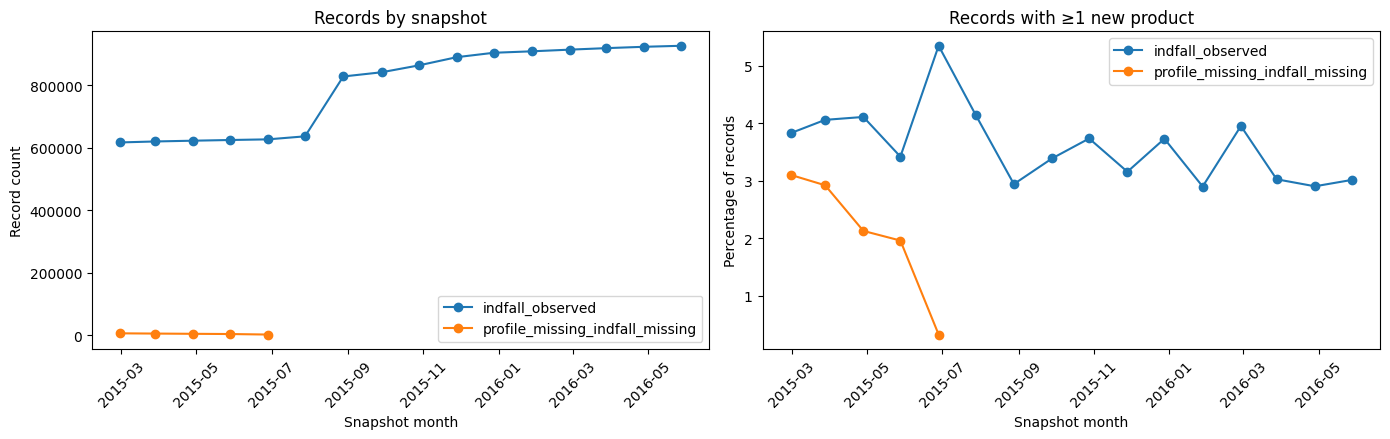

In [194]:
# Logic: visualize whether the common-missing cohort is early-period concentrated and how its new-product rate compares by month.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for cohort, frame in profile_missing_new_product_by_month.groupby("cohort"):
    axes[0].plot(frame["fecha_dato"], frame["records"], marker="o", label=cohort)
    axes[1].plot(frame["fecha_dato"], frame["pct_with_new_product"], marker="o", label=cohort)
axes[0].set(title="Records by snapshot", xlabel="Snapshot month", ylabel="Record count")
axes[1].set(title="Records with ≥1 new product", xlabel="Snapshot month", ylabel="Percentage of records")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

**Insight — early missing cohort and new-product activity**

In [195]:
# Logic: summarize active months and new-product incidence for the profile-missing cohort from the monthly evidence.
from IPython.display import Markdown, display
_missing_cohort_months = profile_missing_new_product_by_month.query("cohort == 'profile_missing_indfall_missing'")
_active_months = _missing_cohort_months.loc[_missing_cohort_months["records"] > 0, "fecha_dato"].dt.strftime("%Y-%m-%d").tolist()
_weighted_rate = (
    100.0 * _missing_cohort_months["records_with_new_product"].sum() / _missing_cohort_months["records"].sum()
    if _missing_cohort_months["records"].sum() else 0
)
display(Markdown(
    f"**Insight.** Cohort indfall-missing xuất hiện ở {len(_active_months)} snapshot: {', '.join(_active_months)}. "
    f"Tỷ lệ gộp record có ít nhất một sản phẩm mua mới là **{_weighted_rate:.3f}%**. "
    "Nếu cohort chỉ xuất hiện ở giai đoạn đầu và không còn trong test, đây là missing có tính historical/structural; "
    "không nên median-fill profile như thể đó là quan sát khách hàng bình thường."
))

**Insight.** Cohort indfall-missing xuất hiện ở 5 snapshot: 2015-02-28, 2015-03-28, 2015-04-28, 2015-05-28, 2015-06-28. Tỷ lệ gộp record có ít nhất một sản phẩm mua mới là **2.403%**. Nếu cohort chỉ xuất hiện ở giai đoạn đầu và không còn trong test, đây là missing có tính historical/structural; không nên median-fill profile như thể đó là quan sát khách hàng bình thường.

#### Tổng hợp, kết luận — indfall

**Kết luận thao tác.** Tách S khỏi null: route customer S ra khỏi recommendation; null là structural early-profile-missing cohort, không median/mode impute và không quy về N.

In [196]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("indfall", indfall_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### sexo — Giới tính

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [197]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
sexo_overview = deep_overview("sexo")
display(sexo_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27804.0,0.204,2


**Insight — completeness & cardinality**

In [198]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("sexo", sexo_overview)

**Insight.** sexo có **27,804** giá trị thiếu (**0.204%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [199]:
# Logic: test whether missingness changes by monthly snapshot.
sexo_missing_by_month = deep_missing_by_month("sexo")
display(sexo_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6955.0,1.112
1,2015-02-28,627394,5942.0,0.947
2,2015-03-28,629209,5094.0,0.810
3,2015-04-28,630367,4295.0,0.681
4,2015-05-28,631957,3600.0,0.570
5,2015-06-28,632110,1864.0,0.295
6,2015-07-28,829817,4.0,0.000
7,2015-08-28,843201,5.0,0.001
8,2015-09-28,865440,5.0,0.001
9,2015-10-28,892251,5.0,0.001


In [200]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
sexo_history_missing = deep_history_missing("sexo")
display(sexo_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27804.0,0.0,0.0


In [201]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
sexo_missing_by_segmento = deep_missing_by_driver("sexo", "segmento")
display(sexo_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,69.0,0.001
1,03 - UNIVERSITARIO,4935579,0.0,0.000
2,01 - TOP,562142,0.0,0.000
3,__MISSING__,189368,27735.0,14.646


**Insight — missingness hypothesis and treatment**

In [202]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("sexo", sexo_history_missing, "segmento")

**Insight.** Có **27,804** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [203]:
# Logic: count the most frequent categorical/date values, including physical missingness.
sexo_values = deep_top_values("sexo")
display(sexo_values)

,value,rows,pct
0,V,7424252,54.401
1,H,6195253,45.395
2,__MISSING__,27804,0.204


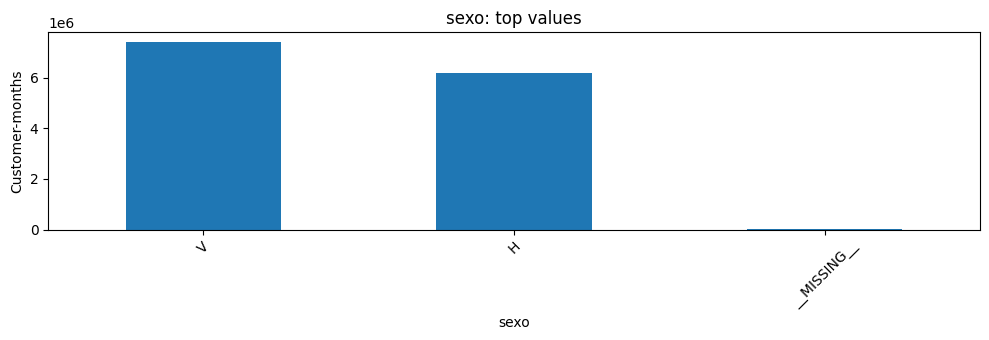

In [204]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = sexo_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="sexo: top values")
ax.set(xlabel="sexo", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [205]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("sexo", "categorical", sexo_values)

**Insight.** Giá trị phổ biến nhất là V với **54.401%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [206]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
sexo_associations = deep_association_table("sexo")
display(sexo_associations)

,candidate_partner,how_to_combine
0,age,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — sexo

**Kết luận thao tác.** Thuộc tính ổn định: past-only fill nếu có lịch sử, phần còn lại missing category + flag; encode binary/one-hot.

In [207]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("sexo", sexo_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### pais_residencia — Quốc gia cư trú

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [208]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
pais_residencia_overview = deep_overview("pais_residencia")
display(pais_residencia_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,118


**Insight — completeness & cardinality**

In [209]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("pais_residencia", pais_residencia_overview)

**Insight.** pais_residencia có **27,734** giá trị thiếu (**0.203%**) và **118** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [210]:
# Logic: test whether missingness changes by monthly snapshot.
pais_residencia_missing_by_month = deep_missing_by_month("pais_residencia")
display(pais_residencia_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [211]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
pais_residencia_history_missing = deep_history_missing("pais_residencia")
display(pais_residencia_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [212]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
pais_residencia_missing_by_canal_entrada = deep_missing_by_driver("pais_residencia", "canal_entrada")
display(pais_residencia_missing_by_canal_entrada)

,canal_entrada,rows,missing_count,missing_pct
0,KHE,4055270,0.0,0.000
1,KAT,3268209,0.0,0.000
2,KFC,3098360,0.0,0.000
3,KHQ,591039,0.0,0.000
4,KFA,409669,0.0,0.000
5,KHK,241084,0.0,0.000
6,__MISSING__,186126,27734.0,14.901
7,KHM,183924,0.0,0.000
8,KHD,116891,0.0,0.000
9,KHN,116608,0.0,0.000


**Insight — missingness hypothesis and treatment**

In [213]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("pais_residencia", pais_residencia_history_missing, "canal_entrada")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo canal_entrada là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [214]:
# Logic: count the most frequent categorical/date values, including physical missingness.
pais_residencia_values = deep_top_values("pais_residencia")
display(pais_residencia_values)

,value,rows,pct
0,ES,13553710,99.314
1,__MISSING__,27734,0.203
2,FR,5161,0.038
3,AR,4835,0.035
4,DE,4625,0.034
5,GB,4605,0.034
6,US,3651,0.027
7,CO,3526,0.026
8,IT,2947,0.022
9,RO,2931,0.021


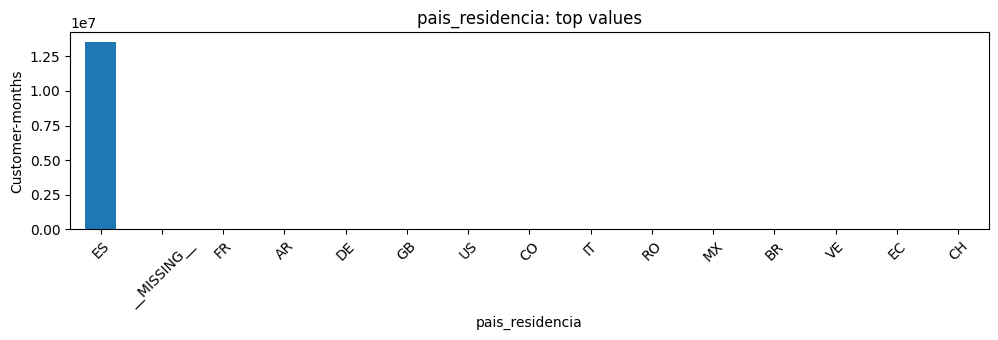

In [215]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = pais_residencia_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="pais_residencia: top values")
ax.set(xlabel="pais_residencia", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [216]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("pais_residencia", "categorical", pais_residencia_values)

**Insight.** Giá trị phổ biến nhất là ES với **99.314%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [217]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
pais_residencia_associations = deep_association_table("pais_residencia")
display(pais_residencia_associations)

,candidate_partner,how_to_combine
0,cod_prov,Validate as an interaction with time-based split.
1,nomprov,Validate as an interaction with time-based split.
2,canal_entrada,Validate as an interaction with time-based split.
3,segmento,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — pais_residencia

**Kết luận thao tác.** Past-only fill khi có; còn lại missing category. Gộp rare levels và dùng frequency/count hoặc out-of-fold target encoding.

#### pais_residencia × canal_entrada — geographic channel composition

Kiểm tra pattern chung giữa quốc gia cư trú và kênh gia nhập. Chỉ giữ level có volume lớn để heatmap đọc được.

In [218]:
# Logic: measure top-country by top-channel composition, with denominators based on each country's full record count.
pais_canal_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(pais_residencia AS VARCHAR), '<MISSING>') AS country_state,
               COALESCE(CAST(canal_entrada AS VARCHAR), '<MISSING>') AS canal_state
        FROM read_parquet(?)
    ),
    country_totals AS (
        SELECT country_state, COUNT(*) AS country_records FROM base GROUP BY 1
    ),
    channel_totals AS (
        SELECT canal_state, COUNT(*) AS channel_records FROM base GROUP BY 1
    ),
    top_countries AS (
        SELECT country_state FROM country_totals ORDER BY country_records DESC LIMIT 15
    ),
    top_channels AS (
        SELECT canal_state FROM channel_totals ORDER BY channel_records DESC LIMIT 12
    ),
    counts AS (
        SELECT country_state, canal_state, COUNT(*) AS records FROM base GROUP BY 1, 2
    )
    SELECT c.country_state, c.canal_state, c.records,
           ROUND(100.0 * c.records / t.country_records, 3) AS country_row_pct
    FROM counts c
    JOIN country_totals t USING (country_state)
    WHERE c.country_state IN (SELECT country_state FROM top_countries)
      AND c.canal_state IN (SELECT canal_state FROM top_channels)
    ORDER BY t.country_records DESC, c.country_state, c.canal_state
""", str(TRAIN_PARQUET))
pais_canal_row_pct = pais_canal_cross.pivot(index="country_state", columns="canal_state", values="country_row_pct").fillna(0)
display(pais_canal_cross)
display(pais_canal_row_pct.round(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,country_state,canal_state,records,country_row_pct
0,ES,<MISSING>,158156,1.167
1,ES,KAS,85314,0.629
2,ES,KAT,3242387,23.923
3,ES,KFA,399310,2.946
4,ES,KFC,3089489,22.794
...,...,...,...,...
106,CH,KFC,521,26.115
107,CH,KHD,11,0.551
108,CH,KHE,19,0.952
109,CH,KHM,4,0.201


canal_state,<MISSING>,KAS,KAT,KFA,KFC,KHD,KHE,KHK,KHM,KHN,KHQ,RED
country_state,,,,,,,,,,,,
<MISSING>,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000
AR,0.476,1.055,41.427,19.359,16.629,0.703,1.986,0.000,0.000,0.00,0.000,0.703
BR,0.043,0.000,28.966,9.783,12.888,2.850,12.463,0.000,0.000,0.00,0.000,2.467
CH,0.000,0.852,51.278,5.313,26.115,0.551,0.952,0.000,0.201,0.00,0.000,0.852
CO,0.312,2.893,37.238,16.704,3.375,3.205,13.330,0.000,0.000,0.00,0.000,0.000
DE,0.714,1.470,44.130,14.508,19.243,0.000,4.022,0.000,0.000,0.00,0.000,0.368
EC,0.000,2.075,49.608,13.324,1.568,2.351,0.784,0.000,0.000,0.00,0.000,0.000
ES,1.167,0.629,23.923,2.946,22.794,0.856,29.888,1.778,1.357,0.86,4.361,0.553
FR,0.484,1.318,42.046,20.093,14.280,0.872,4.922,0.000,0.000,0.00,0.000,1.744


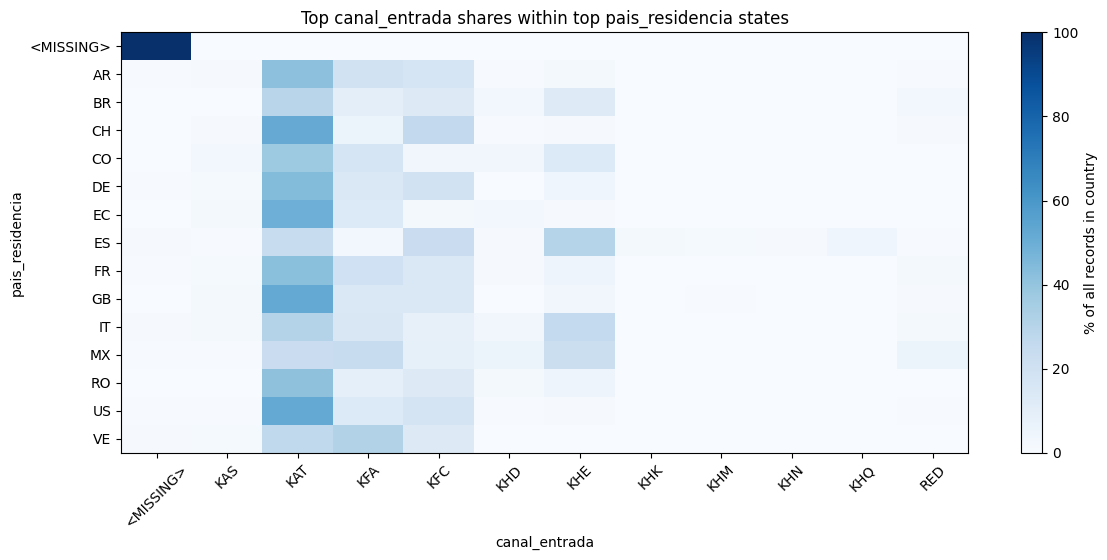

In [219]:
# Logic: show leading entry-channel shares within country states while retaining full-country denominators.
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * len(pais_canal_row_pct))))
image = ax.imshow(pais_canal_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="Top canal_entrada shares within top pais_residencia states",
    xlabel="canal_entrada", ylabel="pais_residencia",
    xticks=range(len(pais_canal_row_pct.columns)), xticklabels=pais_canal_row_pct.columns,
    yticks=range(len(pais_canal_row_pct.index)), yticklabels=pais_canal_row_pct.index,
)
ax.tick_params(axis="x", rotation=45)
fig.colorbar(image, ax=ax, label="% of all records in country")
plt.tight_layout()
plt.show()

In [220]:
# Logic: report concentration for the highest-volume displayed country and retain the non-deterministic interaction caveat.
from IPython.display import Markdown, display
_displayed_country_volume = pais_canal_cross.groupby("country_state")["records"].sum()
_major_country = _displayed_country_volume.idxmax()
_major_country_peak = float(pais_canal_row_pct.loc[_major_country].max())
display(Markdown(
    f"**Insight.** Với country có volume lớn nhất trong matrix hiển thị (**{_major_country}**), "
    f"channel lớn nhất chiếm **{_major_country_peak:.3f}%** record của country đó. "
    "Không suy diễn country từ channel hay ngược lại; chỉ coi đây là candidate interaction cho validation theo thời gian."
))

**Insight.** Với country có volume lớn nhất trong matrix hiển thị (**ES**), channel lớn nhất chiếm **29.888%** record của country đó. Không suy diễn country từ channel hay ngược lại; chỉ coi đây là candidate interaction cho validation theo thời gian.

In [221]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("pais_residencia", pais_residencia_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### cod_prov — Mã tỉnh/thành phố

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [222]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
cod_prov_overview = deep_overview("cod_prov")
display(cod_prov_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,93591.0,0.686,52


**Insight — completeness & cardinality**

In [223]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("cod_prov", cod_prov_overview)

**Insight.** cod_prov có **93,591** giá trị thiếu (**0.686%**) và **52** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [224]:
# Logic: test whether missingness changes by monthly snapshot.
cod_prov_missing_by_month = deep_missing_by_month("cod_prov")
display(cod_prov_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,10631.0,1.700
1,2015-02-28,627394,9617.0,1.533
2,2015-03-28,629209,8769.0,1.394
3,2015-04-28,630367,7969.0,1.264
4,2015-05-28,631957,7275.0,1.151
5,2015-06-28,632110,5536.0,0.876
6,2015-07-28,829817,3975.0,0.479
7,2015-08-28,843201,3977.0,0.472
8,2015-09-28,865440,3976.0,0.459
9,2015-10-28,892251,3976.0,0.446


In [225]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
cod_prov_history_missing = deep_history_missing("cod_prov")
display(cod_prov_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,93591.0,300.0,0.32


In [226]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
cod_prov_missing_by_nomprov = deep_missing_by_driver("cod_prov", "nomprov")
display(cod_prov_missing_by_nomprov)

,nomprov,rows,missing_count,missing_pct
0,MADRID,4409600,0.0,0.0
1,BARCELONA,1275219,0.0,0.0
2,VALENCIA,682304,0.0,0.0
3,SEVILLA,605164,0.0,0.0
4,"CORUÑA, A",429322,0.0,0.0
5,MURCIA,396759,0.0,0.0
6,MALAGA,367023,0.0,0.0
7,ZARAGOZA,342543,0.0,0.0
8,ALICANTE,313397,0.0,0.0
9,CADIZ,294684,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [227]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("cod_prov", cod_prov_history_missing, "nomprov")

**Insight.** Có **93,591** missing; **0.32%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo nomprov là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [228]:
# Logic: count the most frequent categorical/date values, including physical missingness.
cod_prov_values = deep_top_values("cod_prov")
display(cod_prov_values)

,value,rows,pct
0,28,4409600,32.311
1,8,1275219,9.344
2,46,682304,5.000
3,41,605164,4.434
4,15,429322,3.146
5,30,396759,2.907
6,29,367023,2.689
7,50,342543,2.510
8,3,313397,2.296
9,11,294684,2.159


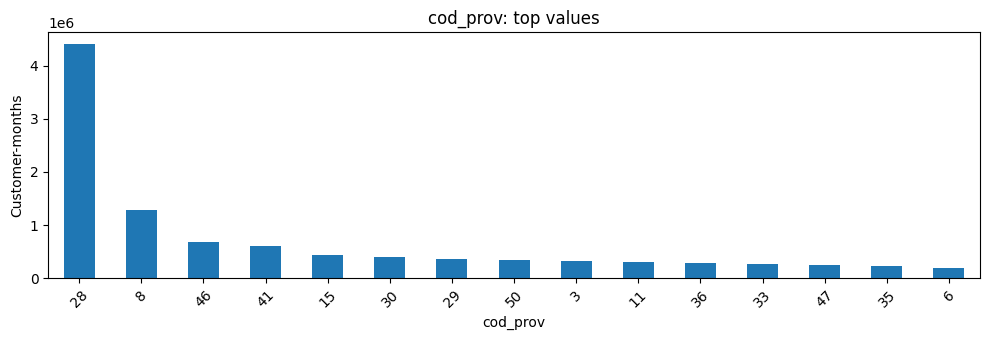

In [229]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = cod_prov_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="cod_prov: top values")
ax.set(xlabel="cod_prov", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [230]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("cod_prov", "categorical", cod_prov_values)

**Insight.** Giá trị phổ biến nhất là 28 với **32.311%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [231]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
cod_prov_associations = deep_association_table("cod_prov")
display(cod_prov_associations)

,candidate_partner,how_to_combine
0,nomprov,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### cod_prov × pais_residencia — confusion matrix

Ma trận đặt `cod_prov` theo hàng và `pais_residencia` theo cột, bao gồm `<MISSING>` để kiểm tra cả mapping địa lý lẫn missingness đồng thời.

In [235]:
# Logic: count every cod_prov × pais_residencia combination and compute country composition within each province code.
import seaborn as sns


if "TRAIN_PARQUET" not in globals():
    raise RuntimeError("Run Bootstrap first so TRAIN_PARQUET and q are available.")
cod_prov_pais_confusion_long = q("""
    SELECT
        COALESCE(CAST(cod_prov AS VARCHAR), '<MISSING>') AS cod_prov_state,
        COALESCE(CAST(pais_residencia AS VARCHAR), '<MISSING>') AS pais_residencia_state,
        COUNT(*) AS records
    FROM read_parquet(?)
    GROUP BY 1, 2
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
cod_prov_pais_count_matrix = (
    cod_prov_pais_confusion_long
    .pivot(index="cod_prov_state", columns="pais_residencia_state", values="records")
    .fillna(0).astype(int)
)
cod_prov_pais_row_pct = cod_prov_pais_count_matrix.div(cod_prov_pais_count_matrix.sum(axis=1), axis=0).mul(100)

pais_residencia_state,<MISSING>,AD,AE,AL,AO,AR,AT,AU,BA,BE,...,TN,TR,TW,UA,US,UY,VE,VN,ZA,ZW
cod_prov_state,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


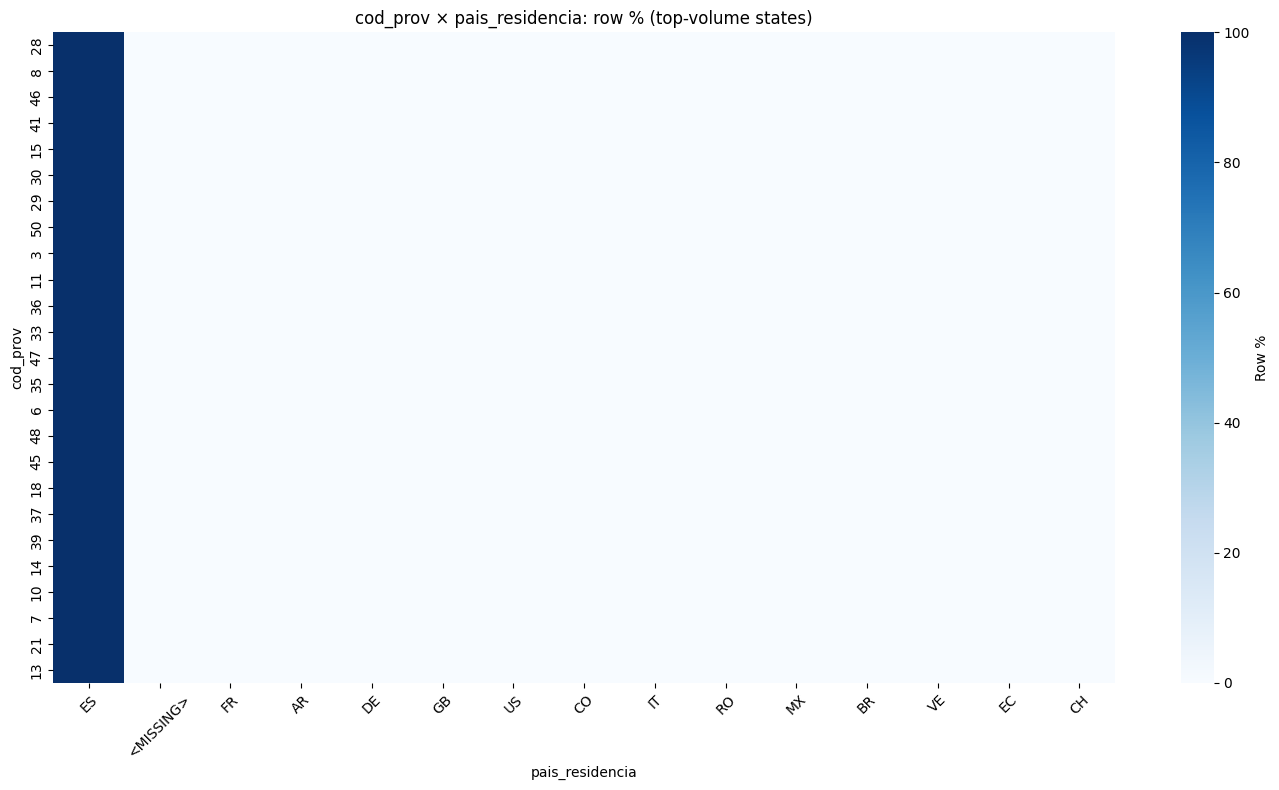

In [236]:
# Logic: display the full count matrix and a readable heatmap of the highest-volume geographic states.
display(cod_prov_pais_count_matrix)

_top_prov_states = cod_prov_pais_count_matrix.sum(axis=1).sort_values(ascending=False).head(25).index
_top_pais_states = cod_prov_pais_count_matrix.sum(axis=0).sort_values(ascending=False).head(15).index
_cod_prov_pais_focus_pct = cod_prov_pais_row_pct.loc[_top_prov_states, _top_pais_states]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(_cod_prov_pais_focus_pct, cmap="Blues", annot=False, cbar_kws={"label": "Row %"}, ax=ax)
ax.set(
    title="cod_prov × pais_residencia: row % (top-volume states)",
    xlabel="pais_residencia",
    ylabel="cod_prov"
)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [237]:
# Logic: quantify how deterministically each observed province code maps to a residence country.
from IPython.display import Markdown, display

_observed_prov_matrix = cod_prov_pais_count_matrix.drop(index="<MISSING>", errors="ignore").drop(columns="<MISSING>", errors="ignore")
_cod_prov_country_purity = 100 * _observed_prov_matrix.max(axis=1).sum() / _observed_prov_matrix.to_numpy().sum()
_top_country_by_prov = _observed_prov_matrix.idxmax(axis=1).value_counts().head(5).to_dict()
display(Markdown(
    f"**Insight.** Với province code và country đều quan sát được, tỷ trọng record thuộc country chiếm ưu thế trong từng province code là "
    f"**{_cod_prov_country_purity:.3f}%** (weighted purity). Country xuất hiện nhiều nhất trong dominant mapping là "
    f"**{_top_country_by_prov}**. Đây là kiểm tra consistency; không nên suy diễn province code missing chỉ từ country nếu mapping không gần-deterministic."
))

**Insight.** Với province code và country đều quan sát được, tỷ trọng record thuộc country chiếm ưu thế trong từng province code là **99.999%** (weighted purity). Country xuất hiện nhiều nhất trong dominant mapping là **{'ES': 52}**. Đây là kiểm tra consistency; không nên suy diễn province code missing chỉ từ country nếu mapping không gần-deterministic.

#### Tổng hợp, kết luận — cod_prov

**Kết luận thao tác.** Xử lý như categorical, không như số. Mapping **cod_prov → nomprov** là deterministic trong lịch sử đã kiểm tra, nên có thể dùng cod_prov để bổ sung nomprov khi cần; vẫn ưu tiên một representation địa lý canonical và không suy diễn ngược từ country.

#### cod_prov × nomprov — canonical mapping audit

Kiểm tra mapping hai chiều trước khi chọn canonical geographic field hoặc fill chéo giá trị missing.

In [238]:
# Logic: find the dominant province name for each province code and count one-to-many mappings.

cod_nomprov_mapping = q("""
    WITH pair_counts AS (
        SELECT
            CAST(cod_prov AS VARCHAR) AS cod_prov_state,
            CAST(nomprov AS VARCHAR) AS nomprov_state,
            COUNT(*) AS records
        FROM read_parquet(?)
        WHERE cod_prov IS NOT NULL AND nomprov IS NOT NULL
        GROUP BY 1, 2
    ),
    ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY cod_prov_state
                   ORDER BY records DESC, nomprov_state
               ) AS mapping_rank,
               SUM(records) OVER (PARTITION BY cod_prov_state) AS code_records,
               COUNT(*) OVER (PARTITION BY cod_prov_state) AS n_names_for_code
        FROM pair_counts
    )
    SELECT
        cod_prov_state, nomprov_state AS dominant_nomprov,
        records, code_records, n_names_for_code,
        ROUND(100.0 * records / code_records, 3) AS dominant_mapping_pct
    FROM ranked
    WHERE mapping_rank = 1
    ORDER BY CAST(cod_prov_state AS INTEGER)
""", str(TRAIN_PARQUET))

display(cod_nomprov_mapping)

,cod_prov_state,dominant_nomprov,records,code_records,n_names_for_code,dominant_mapping_pct
0,1,ALAVA,37704,37704.0,1,100.0
1,2,ALBACETE,114128,114128.0,1,100.0
2,3,ALICANTE,313397,313397.0,1,100.0
3,4,ALMERIA,60291,60291.0,1,100.0
4,5,AVILA,38783,38783.0,1,100.0
5,6,BADAJOZ,192996,192996.0,1,100.0
6,7,"BALEARS, ILLES",124933,124933.0,1,100.0
7,8,BARCELONA,1275219,1275219.0,1,100.0
8,9,BURGOS,97188,97188.0,1,100.0
9,10,CACERES,129912,129912.0,1,100.0


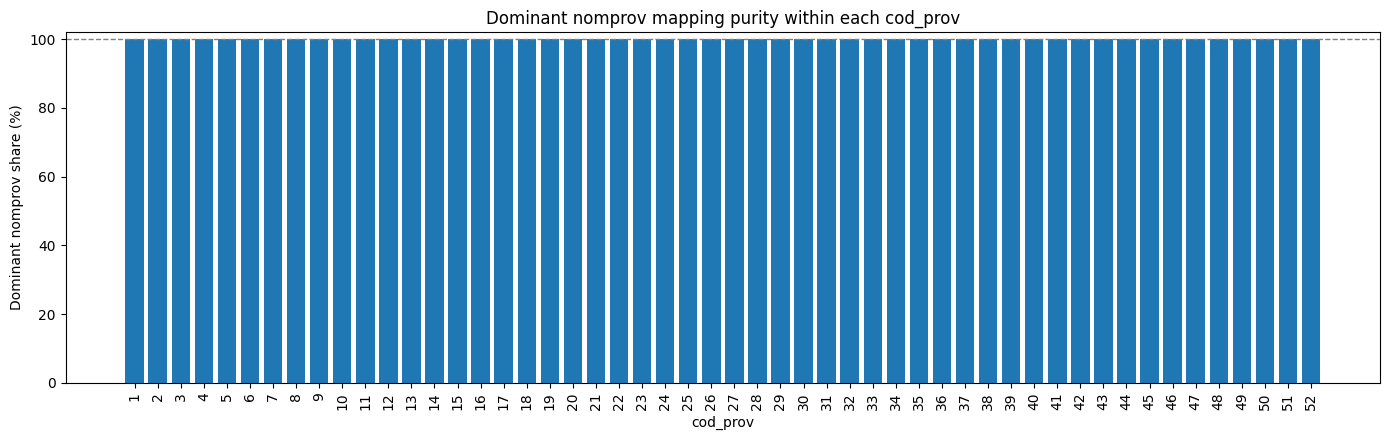

In [239]:
# Logic: plot dominant name purity by province code; a value below 100% flags a non-deterministic code-to-name mapping.

_mapping_plot = cod_nomprov_mapping.sort_values("dominant_mapping_pct")
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(_mapping_plot["cod_prov_state"], _mapping_plot["dominant_mapping_pct"], color="#1f77b4")
ax.axhline(100, color="grey", linewidth=1, linestyle="--")
ax.set(
    title="Dominant nomprov mapping purity within each cod_prov",
    xlabel="cod_prov",
    ylabel="Dominant nomprov share (%)",
    ylim=(0, 102),
)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [240]:
# Logic: state whether code-to-name filling is safe and retain the canonical-field recommendation.

from IPython.display import Markdown, display

_non_deterministic_codes = int((cod_nomprov_mapping["n_names_for_code"] > 1).sum())
_min_mapping_purity = float(cod_nomprov_mapping["dominant_mapping_pct"].min())
display(Markdown(
    f"**Insight.** Có **{_non_deterministic_codes:,}** province code có hơn một tên quan sát được; "
    f"dominant mapping purity thấp nhất là **{_min_mapping_purity:.3f}%**. "
    "Chỉ fill chéo cod_prov và nomprov khi mapping được xác minh deterministic; nếu không, chọn một canonical field và giữ missing indicator."
))

**Insight.** Có **0** province code có hơn một tên quan sát được; dominant mapping purity thấp nhất là **100.000%**. Chỉ fill chéo cod_prov và nomprov khi mapping được xác minh deterministic; nếu không, chọn một canonical field và giữ missing indicator.

In [241]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("cod_prov", cod_prov_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### nomprov — Tên tỉnh/thành phố

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [242]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
nomprov_overview = deep_overview("nomprov")
display(nomprov_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,93591.0,0.686,52


**Insight — completeness & cardinality**

In [243]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("nomprov", nomprov_overview)

**Insight.** nomprov có **93,591** giá trị thiếu (**0.686%**) và **52** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [244]:
# Logic: test whether missingness changes by monthly snapshot.
nomprov_missing_by_month = deep_missing_by_month("nomprov")
display(nomprov_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,10631.0,1.700
1,2015-02-28,627394,9617.0,1.533
2,2015-03-28,629209,8769.0,1.394
3,2015-04-28,630367,7969.0,1.264
4,2015-05-28,631957,7275.0,1.151
5,2015-06-28,632110,5536.0,0.876
6,2015-07-28,829817,3975.0,0.479
7,2015-08-28,843201,3977.0,0.472
8,2015-09-28,865440,3976.0,0.459
9,2015-10-28,892251,3976.0,0.446


In [245]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
nomprov_history_missing = deep_history_missing("nomprov")
display(nomprov_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,93591.0,300.0,0.32


In [246]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
nomprov_missing_by_cod_prov = deep_missing_by_driver("nomprov", "cod_prov")
display(nomprov_missing_by_cod_prov)

,cod_prov,rows,missing_count,missing_pct
0,28,4409600,0.0,0.0
1,8,1275219,0.0,0.0
2,46,682304,0.0,0.0
3,41,605164,0.0,0.0
4,15,429322,0.0,0.0
5,30,396759,0.0,0.0
6,29,367023,0.0,0.0
7,50,342543,0.0,0.0
8,3,313397,0.0,0.0
9,11,294684,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [247]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("nomprov", nomprov_history_missing, "cod_prov")

**Insight.** Có **93,591** missing; **0.32%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo cod_prov là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [248]:
# Logic: count the most frequent categorical/date values, including physical missingness.
nomprov_values = deep_top_values("nomprov")
display(nomprov_values)

,value,rows,pct
0,MADRID,4409600,32.311
1,BARCELONA,1275219,9.344
2,VALENCIA,682304,5.000
3,SEVILLA,605164,4.434
4,"CORUÑA, A",429322,3.146
5,MURCIA,396759,2.907
6,MALAGA,367023,2.689
7,ZARAGOZA,342543,2.510
8,ALICANTE,313397,2.296
9,CADIZ,294684,2.159


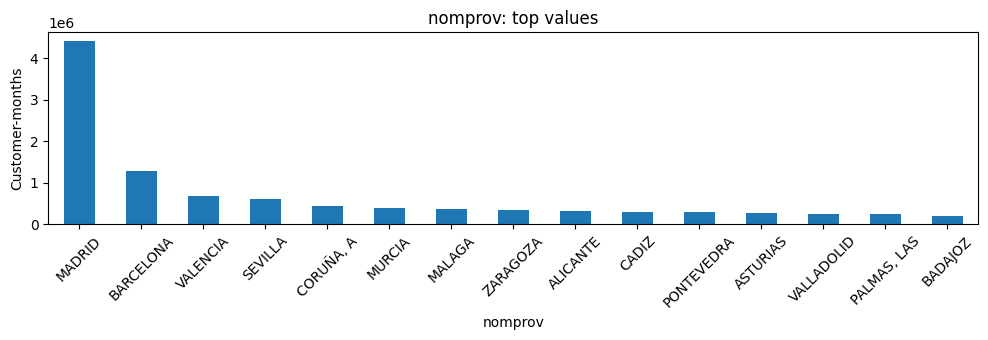

In [249]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = nomprov_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="nomprov: top values")
ax.set(xlabel="nomprov", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [250]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("nomprov", "categorical", nomprov_values)

**Insight.** Giá trị phổ biến nhất là MADRID với **32.311%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [251]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
nomprov_associations = deep_association_table("nomprov")
display(nomprov_associations)

,candidate_partner,how_to_combine
0,cod_prov,Validate as an interaction with time-based split.
1,renta,Validate as an interaction with time-based split.
2,segmento,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — nomprov

**Kết luận thao tác.** Gần redundant với cod_prov. Chỉ fill chéo nếu mapping một-một; baseline nên drop nếu đã giữ cod_prov.

In [252]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("nomprov", nomprov_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### canal_entrada — Kênh gia nhập

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [253]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
canal_entrada_overview = deep_overview("canal_entrada")
display(canal_entrada_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,186126.0,1.364,162


**Insight — completeness & cardinality**

In [254]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("canal_entrada", canal_entrada_overview)

**Insight.** canal_entrada có **186,126** giá trị thiếu (**1.364%**) và **162** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [255]:
# Logic: test whether missingness changes by monthly snapshot.
canal_entrada_missing_by_month = deep_missing_by_month("canal_entrada")
display(canal_entrada_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,7004.0,1.120
1,2015-02-28,627394,5982.0,0.953
2,2015-03-28,629209,5130.0,0.815
3,2015-04-28,630367,4327.0,0.686
4,2015-05-28,631957,3626.0,0.574
5,2015-06-28,632110,1882.0,0.298
6,2015-07-28,829817,19077.0,2.299
7,2015-08-28,843201,16705.0,1.981
8,2015-09-28,865440,25542.0,2.951
9,2015-10-28,892251,30475.0,3.416


In [256]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
canal_entrada_history_missing = deep_history_missing("canal_entrada")
display(canal_entrada_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,186126.0,796.0,0.43


In [257]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
canal_entrada_missing_by_segmento = deep_missing_by_driver("canal_entrada", "segmento")
display(canal_entrada_missing_by_segmento)

,segmento,rows,missing_count,missing_pct
0,02 - PARTICULARES,7960220,691.0,0.009
1,03 - UNIVERSITARIO,4935579,140.0,0.003
2,01 - TOP,562142,16.0,0.003
3,__MISSING__,189368,185279.0,97.841


**Insight — missingness hypothesis and treatment**

In [258]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("canal_entrada", canal_entrada_history_missing, "segmento")

**Insight.** Có **186,126** missing; **0.43%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo segmento là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [259]:
# Logic: count the most frequent categorical/date values, including physical missingness.
canal_entrada_values = deep_top_values("canal_entrada")
display(canal_entrada_values)

,value,rows,pct
0,KHE,4055270,29.715
1,KAT,3268209,23.948
2,KFC,3098360,22.703
3,KHQ,591039,4.331
4,KFA,409669,3.002
5,KHK,241084,1.767
6,__MISSING__,186126,1.364
7,KHM,183924,1.348
8,KHD,116891,0.857
9,KHN,116608,0.854


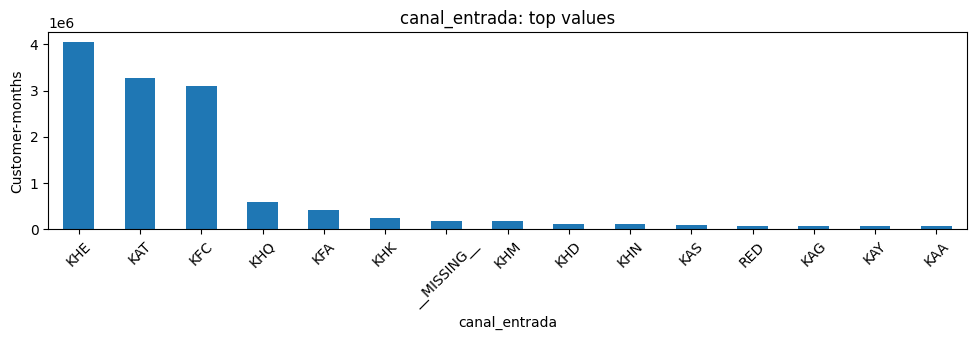

In [260]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = canal_entrada_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="canal_entrada: top values")
ax.set(xlabel="canal_entrada", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [261]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("canal_entrada", "categorical", canal_entrada_values)

**Insight.** Giá trị phổ biến nhất là KHE với **29.715%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [262]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
canal_entrada_associations = deep_association_table("canal_entrada")
display(canal_entrada_associations)

,candidate_partner,how_to_combine
0,segmento,Validate as an interaction with time-based split.
1,ind_nuevo,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,ind_empleado,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — canal_entrada

**Kết luận thao tác.** Giữ missing category, gộp rare levels; frequency/count hoặc out-of-fold target encoding. Không forward-fill vô điều kiện.

In [263]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("canal_entrada", canal_entrada_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### segmento — Phân đoạn khách hàng

Kiểm tra missingness, mức giá trị, phân phối, encoding và các interaction ứng viên.

In [264]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
segmento_overview = deep_overview("segmento")
display(segmento_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,189368.0,1.388,3


**Insight — completeness & cardinality**

In [265]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("segmento", segmento_overview)

**Insight.** segmento có **189,368** giá trị thiếu (**1.388%**) và **3** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [266]:
# Logic: test whether missingness changes by monthly snapshot.
segmento_missing_by_month = deep_missing_by_month("segmento")
display(segmento_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,7024.0,1.123
1,2015-02-28,627394,6003.0,0.957
2,2015-03-28,629209,5145.0,0.818
3,2015-04-28,630367,4321.0,0.685
4,2015-05-28,631957,3619.0,0.573
5,2015-06-28,632110,1868.0,0.296
6,2015-07-28,829817,19358.0,2.333
7,2015-08-28,843201,16981.0,2.014
8,2015-09-28,865440,25848.0,2.987
9,2015-10-28,892251,30726.0,3.444


In [267]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
segmento_history_missing = deep_history_missing("segmento")
display(segmento_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,189368.0,815.0,0.43


In [268]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
segmento_missing_by_canal_entrada = deep_missing_by_driver("segmento", "canal_entrada")
display(segmento_missing_by_canal_entrada)

,canal_entrada,rows,missing_count,missing_pct
0,KHE,4055270,8.0,0.000
1,KAT,3268209,1825.0,0.056
2,KFC,3098360,869.0,0.028
3,KHQ,591039,2.0,0.000
4,KFA,409669,194.0,0.047
5,KHK,241084,70.0,0.029
6,__MISSING__,186126,185279.0,99.545
7,KHM,183924,172.0,0.094
8,KHD,116891,0.0,0.000
9,KHN,116608,160.0,0.137


**Insight — missingness hypothesis and treatment**

In [269]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("segmento", segmento_history_missing, "canal_entrada")

**Insight.** Có **189,368** missing; **0.43%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo canal_entrada là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [270]:
# Logic: count the most frequent categorical/date values, including physical missingness.
segmento_values = deep_top_values("segmento")
display(segmento_values)

,value,rows,pct
0,02 - PARTICULARES,7960220,58.328
1,03 - UNIVERSITARIO,4935579,36.165
2,01 - TOP,562142,4.119
3,__MISSING__,189368,1.388


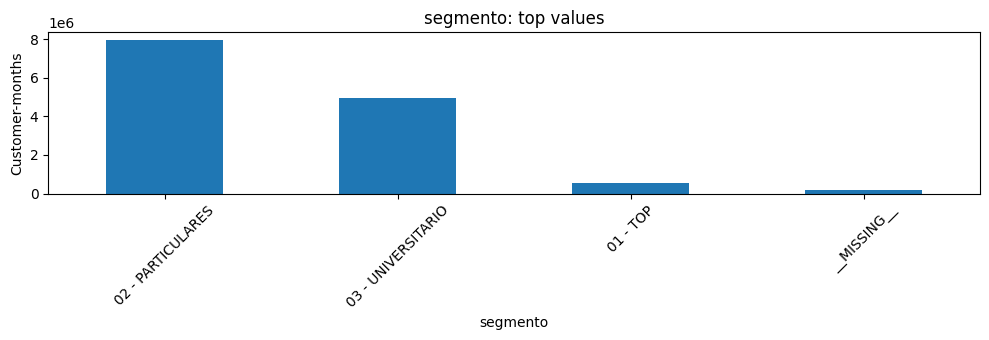

In [271]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = segmento_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="segmento: top values")
ax.set(xlabel="segmento", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [272]:
# Logic: translate distribution and outlier results into transformation or encoding guidance.
show_distribution_insight("segmento", "categorical", segmento_values)

**Insight.** Giá trị phổ biến nhất là 02 - PARTICULARES với **58.328%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [273]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
segmento_associations = deep_association_table("segmento")
display(segmento_associations)

,candidate_partner,how_to_combine
0,renta,Validate as an interaction with time-based split.
1,age,Validate as an interaction with time-based split.
2,ind_actividad_cliente,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Segmento — number of state changes per customer

Một transition chỉ được tính khi `segmento` ở hai kỳ liên tiếp đều quan sát được và khác nhau; missing không bị suy diễn là một segment mới.

In [274]:
# Logic: order records by customer-month, compare consecutive observed segmento values, and count true segment switches per customer.



if "TRAIN_PARQUET" not in globals():



    raise RuntimeError("Run Bootstrap first so TRAIN_PARQUET and q are available.")







segmento_change_distribution = q("""



    WITH ordered AS (



        SELECT



            ncodpers,



            fecha_dato,



            CAST(segmento AS VARCHAR) AS segmento_value,



            LAG(CAST(segmento AS VARCHAR)) OVER (



                PARTITION BY ncodpers



                ORDER BY fecha_dato



            ) AS previous_segmento



        FROM read_parquet(?)



    ),



    customer_changes AS (



        SELECT



            ncodpers,



            SUM(



                CASE



                    WHEN segmento_value IS NOT NULL



                     AND previous_segmento IS NOT NULL



                     AND segmento_value <> previous_segmento



                    THEN 1 ELSE 0



                END



            ) AS segmento_change_count



        FROM ordered



        GROUP BY 1



    )



    SELECT



        segmento_change_count,



        COUNT(*) AS customers



    FROM customer_changes



    GROUP BY 1



    ORDER BY 1



""", str(TRAIN_PARQUET))







segmento_change_summary = {



    "customers": int(segmento_change_distribution["customers"].sum()),



    "customers_with_change": int(segmento_change_distribution.loc[segmento_change_distribution["segmento_change_count"] > 0, "customers"].sum()),



    "total_switches": int((segmento_change_distribution["segmento_change_count"] * segmento_change_distribution["customers"]).sum()),



}

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,segmento_change_count,customers
0,0.0,931317
1,1.0,23649
2,2.0,1634
3,3.0,45


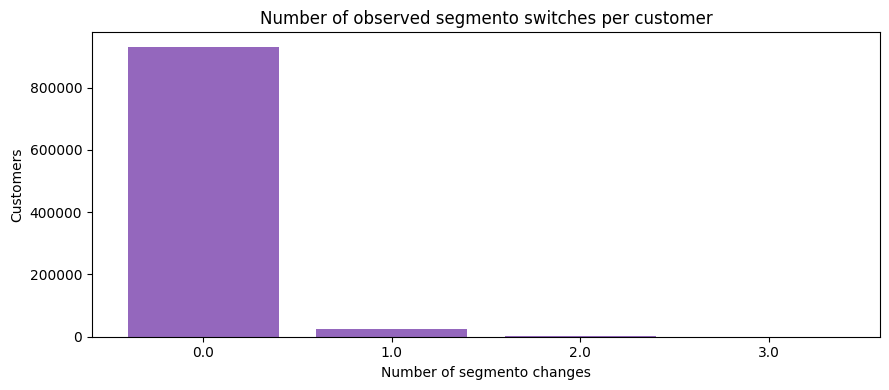

In [275]:
# Logic: display the exact change-count distribution and visualize how persistent segmento is at customer level.
display(segmento_change_distribution)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    segmento_change_distribution["segmento_change_count"].astype(str),
    segmento_change_distribution["customers"],
    color="#9467bd"
)
ax.set(
    title="Number of observed segmento switches per customer",
    xlabel="Number of segmento changes",
    ylabel="Customers"
)
ax.ticklabel_format(axis="y", style="plain")
plt.tight_layout()
plt.show()

In [276]:
# Logic: express segment stability as a customer-level rate and state the missingness caveat.
from IPython.display import Markdown, display

_segmento_changed_pct = 100 * segmento_change_summary["customers_with_change"] / segmento_change_summary["customers"]
display(Markdown(
    f"**Insight.** Có **{segmento_change_summary['total_switches']:,}** lần chuyển segment quan sát được. "
    f"**{segmento_change_summary['customers_with_change']:,} / {segmento_change_summary['customers']:,}** customer "
    f"(**{_segmento_changed_pct:.3f}%**) đổi segmento ít nhất một lần. "
    "Các transition đi qua missing bị loại khỏi phép đếm; do đó kết quả phản ánh thay đổi quan sát được, không phải toàn bộ thay đổi thực tế."
))

**Insight.** Có **27,052** lần chuyển segment quan sát được. **25,328 / 956,645** customer (**2.648%**) đổi segmento ít nhất một lần. Các transition đi qua missing bị loại khỏi phép đếm; do đó kết quả phản ánh thay đổi quan sát được, không phải toàn bộ thay đổi thực tế.

#### Tổng hợp, kết luận — segmento

**Kết luận thao tác.** Dùng categorical one-hot mặc định; không coi missing là transition. Chỉ ordinal encode nếu data dictionary xác nhận thứ bậc.

#### canal_entrada × segmento — entry-channel composition

Crosstab kiểm chứng quan hệ ứng viên giữa kênh gia nhập và phân khúc khách hàng. Chỉ hiển thị các channel có volume lớn để heatmap đọc được.

In [277]:
# Logic: calculate segmento composition within high-volume entry channels, using each channel's full volume as denominator.
canal_segmento_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(canal_entrada AS VARCHAR), '<MISSING>') AS canal_state,
               COALESCE(CAST(segmento AS VARCHAR), '<MISSING>') AS segmento_state
        FROM read_parquet(?)
    ),
    channel_totals AS (
        SELECT canal_state, COUNT(*) AS channel_records FROM base GROUP BY 1
    ),
    top_channels AS (
        SELECT canal_state FROM channel_totals ORDER BY channel_records DESC LIMIT 20
    ),
    counts AS (
        SELECT canal_state, segmento_state, COUNT(*) AS records FROM base GROUP BY 1, 2
    )
    SELECT c.canal_state, c.segmento_state, c.records,
           ROUND(100.0 * c.records / t.channel_records, 3) AS row_pct
    FROM counts c
    JOIN channel_totals t USING (canal_state)
    WHERE c.canal_state IN (SELECT canal_state FROM top_channels)
    ORDER BY t.channel_records DESC, c.canal_state, c.segmento_state
""", str(TRAIN_PARQUET))
canal_segmento_row_pct = canal_segmento_cross.pivot(index="canal_state", columns="segmento_state", values="row_pct").fillna(0)
display(canal_segmento_cross)
display(canal_segmento_row_pct.round(3))

,canal_state,segmento_state,records,row_pct
0,KHE,01 - TOP,142,0.004
1,KHE,02 - PARTICULARES,226115,5.576
2,KHE,03 - UNIVERSITARIO,3829005,94.420
3,KHE,<MISSING>,8,0.000
4,KAT,01 - TOP,264308,8.087
...,...,...,...,...
73,KBZ,<MISSING>,2,0.004
74,KHL,01 - TOP,4359,9.659
75,KHL,02 - PARTICULARES,38190,84.626
76,KHL,03 - UNIVERSITARIO,2563,5.679


segmento_state,01 - TOP,02 - PARTICULARES,03 - UNIVERSITARIO,<MISSING>
canal_state,,,,
<MISSING>,0.009,0.371,0.075,99.545
KAA,4.366,95.183,0.414,0.038
KAB,3.358,95.577,0.965,0.099
KAE,3.463,95.794,0.674,0.069
KAG,8.539,90.299,1.112,0.050
KAS,10.223,89.529,0.189,0.059
KAT,8.087,87.005,4.852,0.056
KAY,4.386,95.488,0.050,0.076
KBZ,5.236,94.144,0.616,0.004


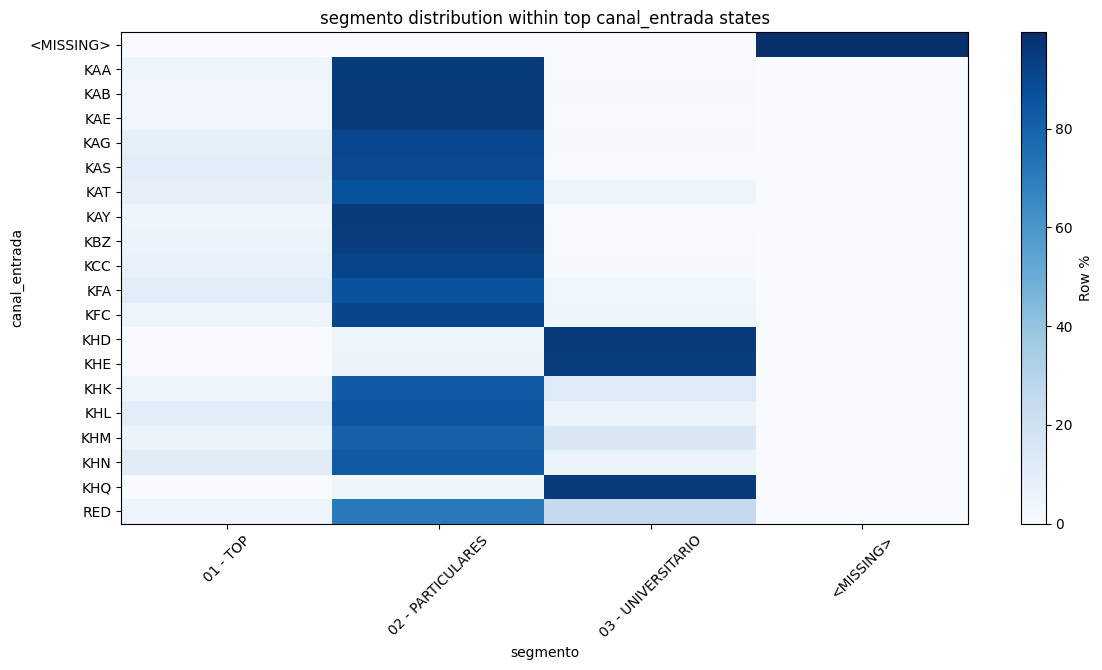

In [278]:
# Logic: visualize segmento composition by high-volume entry channel to identify concentrated versus mixed channel profiles.
fig, ax = plt.subplots(figsize=(12, max(5, 0.34 * len(canal_segmento_row_pct))))
image = ax.imshow(canal_segmento_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="segmento distribution within top canal_entrada states",
    xlabel="segmento", ylabel="canal_entrada",
    xticks=range(len(canal_segmento_row_pct.columns)), xticklabels=canal_segmento_row_pct.columns,
    yticks=range(len(canal_segmento_row_pct.index)), yticklabels=canal_segmento_row_pct.index,
)
ax.tick_params(axis="x", rotation=45)
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [279]:
# Logic: quantify the strongest segment concentration across displayed channels without making a causal claim.
from IPython.display import Markdown, display
_channel_peak = canal_segmento_row_pct.max(axis=1)
display(Markdown(
    f"**Insight.** Trong 20 entry channel có volume lớn nhất, mức tập trung segment cao nhất là **{_channel_peak.max():.3f}%**. "
    "Kết quả là bằng chứng để thử interaction canal_entrada × segmento; chỉ giữ interaction nếu time-based validation cải thiện."
))

**Insight.** Trong 20 entry channel có volume lớn nhất, mức tập trung segment cao nhất là **99.545%**. Kết quả là bằng chứng để thử interaction canal_entrada × segmento; chỉ giữ interaction nếu time-based validation cải thiện.

In [280]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("segmento", segmento_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### fecha_alta — Ngày gia nhập ngân hàng

Biến thời gian; kiểm tra missingness, tần suất ngày và các derived features theo snapshot.

In [281]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
fecha_alta_overview = deep_overview("fecha_alta")
display(fecha_alta_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,6756


**Insight — completeness & cardinality**

In [282]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("fecha_alta", fecha_alta_overview)

**Insight.** fecha_alta có **27,734** giá trị thiếu (**0.203%**) và **6,756** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [283]:
# Logic: test whether missingness changes by monthly snapshot.
fecha_alta_missing_by_month = deep_missing_by_month("fecha_alta")
display(fecha_alta_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [284]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
fecha_alta_history_missing = deep_history_missing("fecha_alta")
display(fecha_alta_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [285]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
fecha_alta_missing_by_ind_nuevo = deep_missing_by_driver("fecha_alta", "ind_nuevo")
display(fecha_alta_missing_by_ind_nuevo)

,ind_nuevo,rows,missing_count,missing_pct
0,0,12808368,0.0,0.0
1,1,811207,0.0,0.0
2,__MISSING__,27734,27734.0,100.0


**Insight — missingness hypothesis and treatment**

In [286]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("fecha_alta", fecha_alta_history_missing, "ind_nuevo")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo ind_nuevo là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [287]:
# Logic: count the most frequent categorical/date values, including physical missingness.
fecha_alta_values = deep_top_values("fecha_alta")
display(fecha_alta_values)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value,rows,pct
0,2014-07-28 00:00:00,57389,0.421
1,2014-10-03 00:00:00,54287,0.398
2,2014-08-04 00:00:00,45746,0.335
3,2013-10-14 00:00:00,40804,0.299
4,2013-08-03 00:00:00,33414,0.245
5,__MISSING__,27734,0.203
6,2012-08-06 00:00:00,26223,0.192
7,2014-07-21 00:00:00,26027,0.191
8,2012-08-03 00:00:00,25409,0.186
9,2012-08-02 00:00:00,25004,0.183


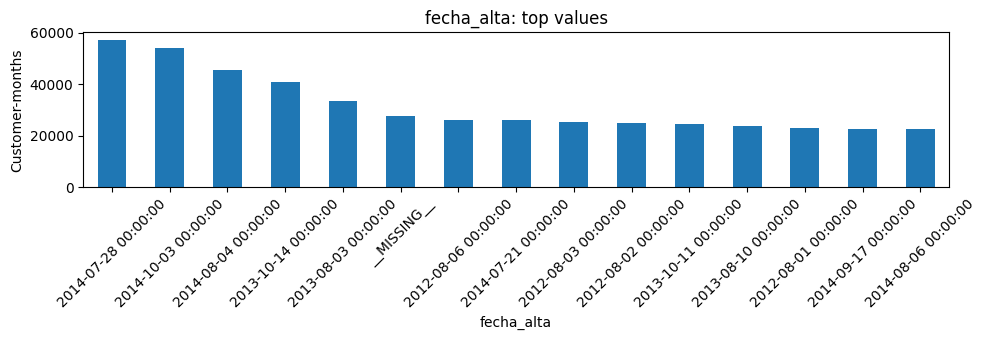

In [288]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = fecha_alta_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="fecha_alta: top values")
ax.set(xlabel="fecha_alta", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and time-feature transformation**

In [289]:
# Logic: state the date-feature transformation decision; raw dates are not encoded directly.
from IPython.display import Markdown, display
display(Markdown("**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng."))

**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng.

In [290]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
fecha_alta_associations = deep_association_table("fecha_alta")
display(fecha_alta_associations)

,candidate_partner,how_to_combine
0,antiguedad,Validate as an interaction with time-based split.
1,ind_nuevo,Validate as an interaction with time-based split.
2,age,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### fecha_alta × antiguedad — correlation check

Đo tương quan chỉ trên `fecha_alta` parse được và `antiguedad >= 0`; sentinel âm của thâm niên không được coi là giá trị hợp lệ.

In [291]:
# Logic: calculate overall and snapshot-level Pearson correlation between account opening date and valid tenure.



if "TRAIN_PARQUET" not in globals():



    raise RuntimeError("Run Bootstrap first so TRAIN_PARQUET and q are available.")







fecha_alta_antiguedad_corr_by_month = q("""



    WITH valid AS (



        SELECT



            fecha_dato,



            TRY_CAST(fecha_alta AS DATE) AS fecha_alta_date,



            TRY_CAST(antiguedad AS DOUBLE) AS antiguedad_value



        FROM read_parquet(?)



    )



    SELECT



        fecha_dato,



        COUNT(*) AS valid_records,



        CORR(



            DATE_DIFF('day', DATE '1900-01-01', fecha_alta_date),



            antiguedad_value



        ) AS pearson_corr



    FROM valid



    WHERE fecha_alta_date IS NOT NULL



      AND antiguedad_value >= 0



    GROUP BY 1



    ORDER BY 1



""", str(TRAIN_PARQUET))







fecha_alta_antiguedad_corr_overall = q("""



    WITH valid AS (



        SELECT



            TRY_CAST(fecha_alta AS DATE) AS fecha_alta_date,



            TRY_CAST(antiguedad AS DOUBLE) AS antiguedad_value



        FROM read_parquet(?)



    )



    SELECT



        COUNT(*) AS valid_records,



        CORR(



            DATE_DIFF('day', DATE '1900-01-01', fecha_alta_date),



            antiguedad_value



        ) AS pearson_corr



    FROM valid



    WHERE fecha_alta_date IS NOT NULL



      AND antiguedad_value >= 0



""", str(TRAIN_PARQUET))

,valid_records,pearson_corr
0,13619537,-0.966986


,fecha_dato,valid_records,pearson_corr
0,2015-01-28,618502,-0.972659
1,2015-02-28,621452,-0.972391
2,2015-03-28,624116,-0.972026
3,2015-04-28,626073,-0.971899
4,2015-05-28,628358,-0.971594
5,2015-06-28,630247,-0.971481
6,2015-07-28,829815,-0.966049
7,2015-08-28,843199,-0.966383
8,2015-09-28,865438,-0.967051
9,2015-10-28,892249,-0.967858


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

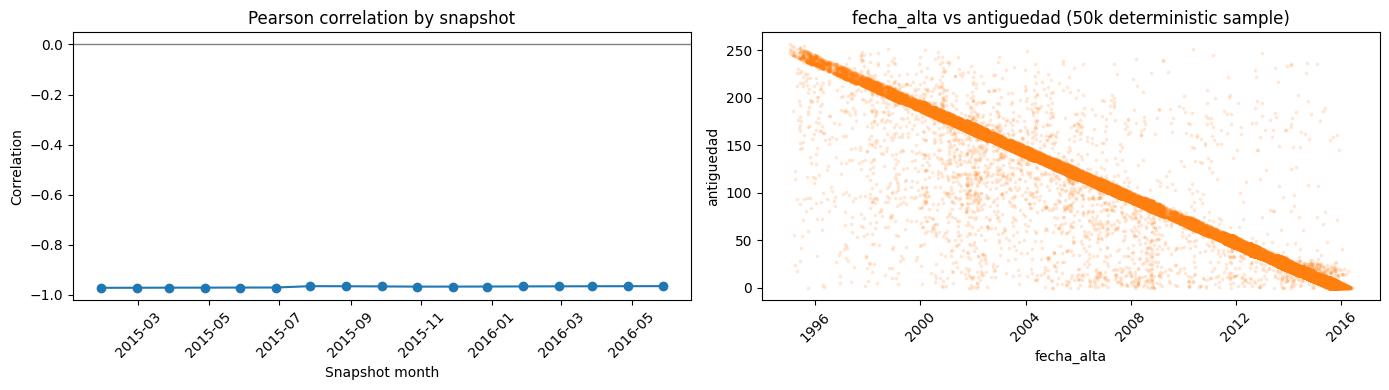

In [292]:
# Logic: show correlation stability over snapshots and a deterministic customer-month sample of the relationship.



display(fecha_alta_antiguedad_corr_overall)



display(fecha_alta_antiguedad_corr_by_month)







_fecha_alta_tenure_sample = q("""



    SELECT



        TRY_CAST(fecha_alta AS DATE) AS fecha_alta_date,



        TRY_CAST(antiguedad AS DOUBLE) AS antiguedad_value



    FROM read_parquet(?)



    WHERE TRY_CAST(fecha_alta AS DATE) IS NOT NULL



      AND TRY_CAST(antiguedad AS DOUBLE) >= 0



    ORDER BY HASH(ncodpers, fecha_dato)



    LIMIT 50000



""", str(TRAIN_PARQUET))







fig, axes = plt.subplots(1, 2, figsize=(14, 4))



axes[0].plot(fecha_alta_antiguedad_corr_by_month["fecha_dato"], fecha_alta_antiguedad_corr_by_month["pearson_corr"], marker="o", color="#1f77b4")



axes[0].axhline(0, color="grey", linewidth=1)



axes[0].set(title="Pearson correlation by snapshot", xlabel="Snapshot month", ylabel="Correlation")



axes[0].tick_params(axis="x", rotation=45)







axes[1].scatter(_fecha_alta_tenure_sample["fecha_alta_date"], _fecha_alta_tenure_sample["antiguedad_value"], s=3, alpha=.12, color="#ff7f0e")



axes[1].set(title="fecha_alta vs antiguedad (50k deterministic sample)", xlabel="fecha_alta", ylabel="antiguedad")



axes[1].tick_params(axis="x", rotation=45)



plt.tight_layout()



plt.show()

In [293]:
# Logic: summarize the direction and stability of the date-tenure relationship without mixing in invalid tenure sentinels.
from IPython.display import Markdown, display

_overall_fecha_alta_corr = float(fecha_alta_antiguedad_corr_overall.loc[0, "pearson_corr"])
_monthly_fecha_alta_corr = fecha_alta_antiguedad_corr_by_month["pearson_corr"].dropna()
display(Markdown(
    f"**Insight.** Pearson correlation là **{_overall_fecha_alta_corr:.3f}** trên toàn bộ dữ liệu; theo từng snapshot, hệ số nằm trong khoảng "
    f"**{_monthly_fecha_alta_corr.min():.3f}** đến **{_monthly_fecha_alta_corr.max():.3f}**. "
    "Tương quan âm là hợp lý vì ngày mở tài khoản càng gần hiện tại thì thâm niên thường càng thấp. "
    "Nên dùng một trong hai feature hoặc kiểm chứng incremental value bằng mô hình time-aware để hạn chế redundancy."
))

**Insight.** Pearson correlation là **-0.967** trên toàn bộ dữ liệu; theo từng snapshot, hệ số nằm trong khoảng **-0.973** đến **-0.966**. Tương quan âm là hợp lý vì ngày mở tài khoản càng gần hiện tại thì thâm niên thường càng thấp. Nên dùng một trong hai feature hoặc kiểm chứng incremental value bằng mô hình time-aware để hạn chế redundancy.

#### Tổng hợp, kết luận — fecha_alta

**Kết luận thao tác.** Tạo tuổi tài khoản tại snapshot; tránh median ngày cơ học. Do tương quan -0.967 với antiguedad, giữ một feature hoặc chứng minh incremental value.

In [294]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("fecha_alta", fecha_alta_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### ult_fec_cli_1t — Ngày cuối là khách hàng chính

Biến thời gian; kiểm tra missingness, tần suất ngày và các derived features theo snapshot.

In [295]:
# Logic: quantify row count, physical missingness, and cardinality for this feature.
ult_fec_cli_1t_overview = deep_overview("ult_fec_cli_1t")
display(ult_fec_cli_1t_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,13622516.0,99.818,223


**Insight — completeness & cardinality**

In [296]:
# Logic: convert the completeness and cardinality results above into a numeric interpretation.
show_overview_insight("ult_fec_cli_1t", ult_fec_cli_1t_overview)

**Insight.** ult_fec_cli_1t có **13,622,516** giá trị thiếu (**99.818%**) và **223** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [297]:
# Logic: test whether missingness changes by monthly snapshot.
ult_fec_cli_1t_missing_by_month = deep_missing_by_month("ult_fec_cli_1t")
display(ult_fec_cli_1t_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,624694.0,99.878
1,2015-02-28,627394,626601.0,99.874
2,2015-03-28,629209,628402.0,99.872
3,2015-04-28,630367,629576.0,99.875
4,2015-05-28,631957,631172.0,99.876
5,2015-06-28,632110,631328.0,99.876
6,2015-07-28,829817,828392.0,99.828
7,2015-08-28,843201,841859.0,99.841
8,2015-09-28,865440,863707.0,99.800
9,2015-10-28,892251,890239.0,99.775


In [298]:
# Logic: test whether missing values occur after a valid earlier value for the same customer.
ult_fec_cli_1t_history_missing = deep_history_missing("ult_fec_cli_1t")
display(ult_fec_cli_1t_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,13622516.0,2555.0,0.02


In [299]:
# Logic: test whether missingness concentrates in a plausible explanatory customer group.
ult_fec_cli_1t_missing_by_indrel_1mes = deep_missing_by_driver("ult_fec_cli_1t", "indrel_1mes")
display(ult_fec_cli_1t_missing_by_indrel_1mes)

,indrel_1mes,rows,missing_count,missing_pct
0,1.0,9133383,9121693.0,99.872
1,1,4357298,4348682.0,99.802
2,__MISSING__,149781,145869.0,97.388
3,3.0,2780,2494.0,89.712
4,3,1570,1339.0,85.287
5,P,874,846.0,96.796
6,2.0,740,734.0,99.189
7,2,577,567.0,98.267
8,4.0,223,209.0,93.722
9,4,83,83.0,100.000


**Insight — missingness hypothesis and treatment**

In [300]:
# Logic: select a missing-value treatment from the observed history and group evidence.
show_missing_insight("ult_fec_cli_1t", ult_fec_cli_1t_history_missing, "indrel_1mes")

**Insight.** Có **13,622,516** missing; **0.02%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo indrel_1mes là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [301]:
# Logic: count the most frequent categorical/date values, including physical missingness.
ult_fec_cli_1t_values = deep_top_values("ult_fec_cli_1t")
display(ult_fec_cli_1t_values)

,value,rows,pct
0,__MISSING__,13622516,99.818
1,2015-12-24 00:00:00,763,0.006
2,2015-12-28 00:00:00,521,0.004
3,2015-07-09 00:00:00,443,0.003
4,2015-07-06 00:00:00,405,0.003
5,2015-07-01 00:00:00,401,0.003
6,2015-07-21 00:00:00,391,0.003
7,2015-07-07 00:00:00,340,0.002
8,2015-07-17 00:00:00,330,0.002
9,2015-07-10 00:00:00,320,0.002


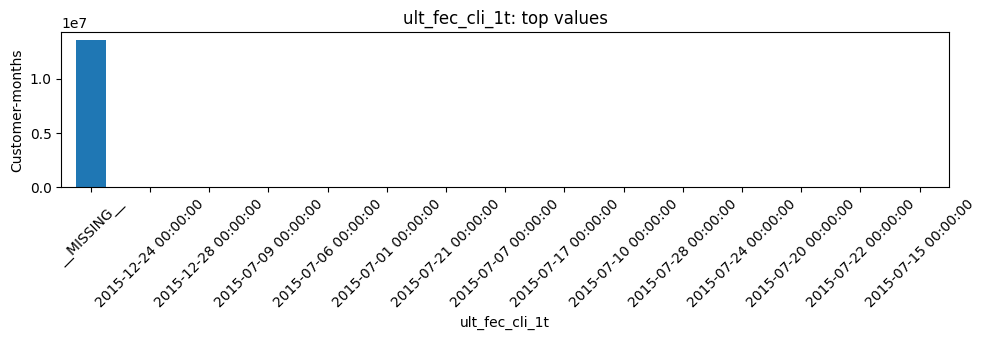

In [302]:
# Logic: visualize the top-value frequency table from the previous cell.
ax = ult_fec_cli_1t_values.plot.bar(x="value", y="rows", legend=False, figsize=(10, 3.5), color="#1f77b4", title="ult_fec_cli_1t: top values")
ax.set(xlabel="ult_fec_cli_1t", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Insight — distribution and time-feature transformation**

In [303]:
# Logic: state the date-feature transformation decision; raw dates are not encoded directly.
from IPython.display import Markdown, display
display(Markdown("**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng."))

**Insight.** Không encode ngày thô. Parse thành datetime và tạo tenure_since_join / time_since_last_primary so với fecha_dato; missing vẫn được giữ như một trạng thái riêng.

In [304]:
# Logic: screen domain-plausible partner features for association or interaction candidates.
ult_fec_cli_1t_associations = deep_association_table("ult_fec_cli_1t")
display(ult_fec_cli_1t_associations)

,candidate_partner,how_to_combine
0,indrel,Validate as an interaction with time-based split.
1,indrel_1mes,Validate as an interaction with time-based split.
2,tiprel_1mes,Validate as an interaction with time-based split.
3,indfall,Validate as an interaction with time-based split.


#### indfall × ult_fec_cli_1t — confusion matrix

`ult_fec_cli_1t` là date có cardinality cao, vì vậy ma trận dùng **trạng thái availability** (`<OBSERVED>` / `<MISSING>`) thay vì từng ngày riêng lẻ.

In [305]:
# Logic: build a count and row-normalized confusion matrix between indfall and the availability of ult_fec_cli_1t.



if "TRAIN_PARQUET" not in globals():



    raise RuntimeError("Run Bootstrap first so TRAIN_PARQUET and q are available.")







indfall_ult_confusion_long = q("""



    WITH base AS (



        SELECT



            COALESCE(CAST(indfall AS VARCHAR), '<MISSING>') AS indfall_state,



            CASE



                WHEN ult_fec_cli_1t IS NULL THEN '<MISSING>'



                ELSE '<OBSERVED>'



            END AS ult_fec_cli_1t_state



        FROM read_parquet(?)



    )



    SELECT indfall_state, ult_fec_cli_1t_state, COUNT(*) AS records



    FROM base



    GROUP BY 1, 2



    ORDER BY 1, 2



""", str(TRAIN_PARQUET))







indfall_ult_count_matrix = (



    indfall_ult_confusion_long



    .pivot(index="indfall_state", columns="ult_fec_cli_1t_state", values="records")



    .fillna(0).astype(int)



)



indfall_ult_row_pct = indfall_ult_count_matrix.div(indfall_ult_count_matrix.sum(axis=1), axis=0).mul(100)

ult_fec_cli_1t_state,<MISSING>,<OBSERVED>
indfall_state,,
<MISSING>,27734,0
N,13560604,24209
S,34178,584


ult_fec_cli_1t_state (%),<MISSING>,<OBSERVED>
indfall_state,,
<MISSING>,100.000,0.000
N,99.822,0.178
S,98.320,1.680


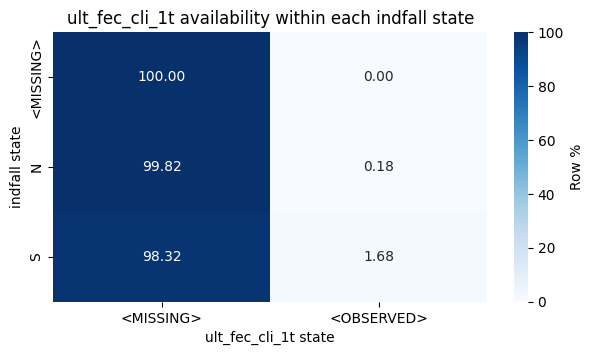

In [306]:
# Logic: display exact counts and visualize within-indfall availability rates to test missingness co-occurrence.
display(indfall_ult_count_matrix)
display(indfall_ult_row_pct.round(3).rename_axis(index="indfall_state", columns="ult_fec_cli_1t_state (%)"))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(indfall_ult_row_pct, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Row %"}, ax=ax)
ax.set(title="ult_fec_cli_1t availability within each indfall state", xlabel="ult_fec_cli_1t state", ylabel="indfall state")
plt.show()

In [307]:
# Logic: convert the confusion-matrix evidence into a concise missingness conclusion.
from IPython.display import Markdown, display

_indfall_missing_ult_pct = float(indfall_ult_row_pct.loc["<MISSING>", "<MISSING>"]) if "<MISSING>" in indfall_ult_row_pct.index and "<MISSING>" in indfall_ult_row_pct.columns else float("nan")
_observed_states = indfall_ult_row_pct.index[indfall_ult_row_pct.index != "<MISSING>"]
_observed_matrix = indfall_ult_count_matrix.loc[_observed_states]
_observed_missing_ult_pct = (
    100 * _observed_matrix["<MISSING>"].sum() / _observed_matrix.to_numpy().sum()
    if len(_observed_states) and "<MISSING>" in _observed_matrix.columns else float("nan")
)
display(Markdown(
    f"**Insight.** Khi indfall missing, ult_fec_cli_1t cũng missing ở **{_indfall_missing_ult_pct:.3f}%** record; "
    f"trong nhóm indfall quan sát được, tỷ lệ tương ứng là **{_observed_missing_ult_pct:.3f}%**. "
    "Ma trận này kiểm tra sự đồng thời về availability, không coi từng ngày ult_fec_cli_1t là một category."
))

**Insight.** Khi indfall missing, ult_fec_cli_1t cũng missing ở **100.000%** record; trong nhóm indfall quan sát được, tỷ lệ tương ứng là **99.818%**. Ma trận này kiểm tra sự đồng thời về availability, không coi từng ngày ult_fec_cli_1t là một category.

#### Tổng hợp, kết luận — ult_fec_cli_1t

**Kết luận thao tác.** Missing 99.818%; drop raw date ở baseline, không impute. Nếu thử nghiệm chỉ dùng cờ is_observed.

#### ult_fec_cli_1t × indrel — availability matrix

Kiểm tra trực tiếp claim rằng date cực sparse này chỉ có thể bổ sung hạn chế cho trạng thái quan hệ; trọng tâm là availability theo indrel.

In [308]:
# Logic: cross-tab ult_fec_cli_1t availability against indrel states, retaining missingness rather than imputing the date.
ult_indrel_cross = q("""
    WITH base AS (
        SELECT COALESCE(CAST(indrel AS VARCHAR), '<MISSING>') AS indrel_state,
               CASE WHEN ult_fec_cli_1t IS NULL THEN '<MISSING>' ELSE '<OBSERVED>' END AS ult_fec_cli_1t_state
        FROM read_parquet(?)
    ),
    counts AS (
        SELECT indrel_state, ult_fec_cli_1t_state, COUNT(*) AS records FROM base GROUP BY 1, 2
    )
    SELECT indrel_state, ult_fec_cli_1t_state, records,
           ROUND(100.0 * records / SUM(records) OVER (PARTITION BY indrel_state), 3) AS row_pct
    FROM counts
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
ult_indrel_row_pct = ult_indrel_cross.pivot(index="indrel_state", columns="ult_fec_cli_1t_state", values="row_pct").fillna(0)
display(ult_indrel_cross)
display(ult_indrel_row_pct.round(3))

,indrel_state,ult_fec_cli_1t_state,records,row_pct
0,1,<MISSING>,13594782,100.0
1,99,<OBSERVED>,24793,100.0
2,<MISSING>,<MISSING>,27734,100.0


ult_fec_cli_1t_state,<MISSING>,<OBSERVED>
indrel_state,,
1,100.0,0.0
99,0.0,100.0
<MISSING>,100.0,0.0


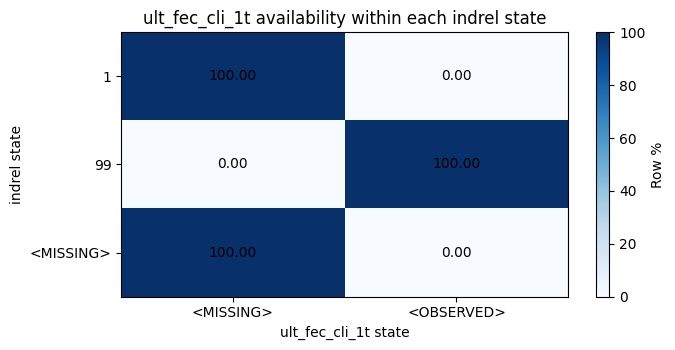

In [309]:
# Logic: visualize date availability conditional on relationship state; uniform missingness indicates weak incremental coverage.
fig, ax = plt.subplots(figsize=(7, 3.6))
image = ax.imshow(ult_indrel_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="ult_fec_cli_1t availability within each indrel state",
    xlabel="ult_fec_cli_1t state", ylabel="indrel state",
    xticks=range(len(ult_indrel_row_pct.columns)), xticklabels=ult_indrel_row_pct.columns,
    yticks=range(len(ult_indrel_row_pct.index)), yticklabels=ult_indrel_row_pct.index,
)
for row in range(ult_indrel_row_pct.shape[0]):
    for col in range(ult_indrel_row_pct.shape[1]):
        ax.text(col, row, f"{ult_indrel_row_pct.iloc[row, col]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [310]:
# Logic: summarize overall date coverage and identify the relationship state containing observed dates before making a modelling decision.
from IPython.display import Markdown, display
_ult_total_records = float(ult_indrel_cross["records"].sum())
_ult_observed_records = float(ult_indrel_cross.loc[ult_indrel_cross["ult_fec_cli_1t_state"].eq("<OBSERVED>"), "records"].sum())
_ult_overall_pct = 100.0 * _ult_observed_records / _ult_total_records if _ult_total_records else 0.0
_ult_observed_states = ult_indrel_cross.loc[
    ult_indrel_cross["ult_fec_cli_1t_state"].eq("<OBSERVED>"), "indrel_state"
].astype(str).tolist()
display(Markdown(
    f"**Insight.** ult_fec_cli_1t chỉ quan sát ở **{_ult_overall_pct:.3f}%** toàn bộ record và xuất hiện trong trạng thái indrel: "
    f"**{', '.join(_ult_observed_states)}**. Coverage quá thấp để dùng raw date làm predictor chính; "
    "chỉ cân nhắc availability flag sau temporal validation."
))

**Insight.** ult_fec_cli_1t chỉ quan sát ở **0.182%** toàn bộ record và xuất hiện trong trạng thái indrel: **99**. Coverage quá thấp để dùng raw date làm predictor chính; chỉ cân nhắc availability flag sau temporal validation.

In [311]:
# Logic: state the strongest association candidate and its modelling caveat.
show_association_insight("ult_fec_cli_1t", ult_fec_cli_1t_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

In [312]:

# Logic: extend the profile-feature registry and define relations needed for residence and address-type EDA.
for feature in ["tipodom", "indresi", "indext"]:
    if feature in ALL_COLUMNS and feature not in PROFILE_COLUMNS:
        PROFILE_COLUMNS.append(feature)

FEATURE_PARTNERS.update({
    "tipodom": ["indfall", "indrel", "indrel_1mes", "tiprel_1mes", "ind_actividad_cliente"],
    "indresi": ["pais_residencia", "indext", "cod_prov", "canal_entrada"],
    "indext": ["pais_residencia", "indresi", "cod_prov", "canal_entrada"],
})

### tipodom — Loại địa chỉ

Biến này cần được xem như một kiểm tra chất lượng dữ liệu đặc biệt: xác minh nó có thực sự là biến hằng, kiểm tra missing đồng thời với indfall, và tách các missing không trùng indfall để đánh giá giả thuyết khách hàng không-primary.

In [313]:

# Logic: quantify tipodom completeness and determine whether observed values have any usable variation.
tipodom_overview = deep_overview("tipodom")
display(tipodom_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27735.0,0.203,1


**Insight — completeness & cardinality**

In [314]:
# Logic: turn the completeness/cardinality result into an initial interpretation.
show_overview_insight("tipodom", tipodom_overview)

**Insight.** tipodom có **27,735** giá trị thiếu (**0.203%**) và **1** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [315]:
# Logic: identify every non-product column whose missing count equals indfall's missing count.
_profile_non_product = [c for c in ALL_COLUMNS if c not in PRODUCT_COLUMNS]
_missing_sql = ", ".join(f"SUM({quote_identifier(c)} IS NULL) AS {quote_identifier(c)}" for c in _profile_non_product)
_missing_counts = q(f"SELECT {_missing_sql} FROM read_parquet(?)", str(TRAIN_PARQUET)).T.rename(columns={0: "missing_count"})
_indfall_missing_count = int(_missing_counts.loc["indfall", "missing_count"])
same_missing_count_as_indfall = (
    _missing_counts.assign(feature=lambda df: df.index)
    .query("missing_count == @_indfall_missing_count")
    .sort_values("feature")
)
display(same_missing_count_as_indfall)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_count,feature
age,27734.0,age
antiguedad,27734.0,antiguedad
fecha_alta,27734.0,fecha_alta
ind_actividad_cliente,27734.0,ind_actividad_cliente
ind_empleado,27734.0,ind_empleado
ind_nuevo,27734.0,ind_nuevo
indext,27734.0,indext
indfall,27734.0,indfall
indrel,27734.0,indrel
indresi,27734.0,indresi


In [316]:
# Logic: measure exact overlap between missing tipodom and missing indfall rather than comparing rates alone.
tipodom_indfall_overlap = q("""
    SELECT
        COUNT(*) AS rows,
        SUM(tipodom IS NULL) AS tipodom_missing,
        SUM(indfall IS NULL) AS indfall_missing,
        SUM(tipodom IS NULL AND indfall IS NULL) AS both_missing,
        SUM(tipodom IS NULL AND indfall IS NOT NULL) AS tipodom_only_missing,
        SUM(tipodom IS NOT NULL AND indfall IS NULL) AS indfall_only_missing,
        ROUND(100.0 * SUM(tipodom IS NULL AND indfall IS NULL) / NULLIF(SUM(tipodom IS NULL), 0), 3) AS pct_tipodom_missing_also_indfall_missing
    FROM read_parquet(?)
""", str(TRAIN_PARQUET))
display(tipodom_indfall_overlap)

,rows,tipodom_missing,indfall_missing,both_missing,tipodom_only_missing,indfall_only_missing,pct_tipodom_missing_also_indfall_missing
0,13647309,27735.0,27734.0,27734.0,1.0,0.0,99.996


In [317]:
_product_count_sql = " + ".join(f"COALESCE(TRY_CAST({quote_identifier(c)} AS INTEGER), 0)" for c in PRODUCT_COLUMNS)
tipodom_only_missing_profile = q(f"""
    SELECT
        COALESCE(CAST(indrel AS VARCHAR), '__MISSING__') AS indrel,
        COALESCE(indrel_1mes, '__MISSING__') AS indrel_1mes,
        COALESCE(tiprel_1mes, '__MISSING__') AS tiprel_1mes,
        COUNT(*) AS rows,
        ROUND(AVG({_product_count_sql}), 3) AS mean_products_owned,
        MAX({_product_count_sql}) AS max_products_owned
    FROM read_parquet(?)
    WHERE tipodom IS NULL AND indfall IS NOT NULL
    GROUP BY 1, 2, 3
    ORDER BY rows DESC
    LIMIT 20
""", str(TRAIN_PARQUET))
display(tipodom_only_missing_profile)

,indrel,indrel_1mes,tiprel_1mes,rows,mean_products_owned,max_products_owned
0,1,3.0,P,1,2.0,2


**Insight — missingness mechanism and null treatment**

In [318]:
# Logic: make the tipodom fill/drop recommendation from overlap evidence, not from equal missing rates alone.

from IPython.display import Markdown, display

_tip = tipodom_indfall_overlap.iloc[0]
_observed_unique = int(tipodom_overview.loc[0, "n_unique_non_null"])
_overlap = float(_tip["pct_tipodom_missing_also_indfall_missing"] or 0)

if _observed_unique <= 1:
    _recommendation = (
        "Observed tipodom is constant, so drop it as a value feature. Do not blanket-fill null with 1: "
        "retain a tipodom-missing flag only if the missing pattern adds validated signal. "
        "For data cleaning, label rows missing tipodom but not indfall as a separate structural-missing group "
        "(possible non-primary/unresolved relationship) until the table above supports a rule."
    )
else:
    _recommendation = "Keep the value feature and use a dedicated missing category; do not use unconditional mode filling."

display(Markdown(
    f"**Insight.** {int(_tip['both_missing']):,} rows are missing in both fields; "
    f"**{_overlap:.3f}%** of tipodom-missing rows also miss indfall. {_recommendation}"
))

**Insight.** 27,734 rows are missing in both fields; **99.996%** of tipodom-missing rows also miss indfall. Observed tipodom is constant, so drop it as a value feature. Do not blanket-fill null with 1: retain a tipodom-missing flag only if the missing pattern adds validated signal. For data cleaning, label rows missing tipodom but not indfall as a separate structural-missing group (possible non-primary/unresolved relationship) until the table above supports a rule.

In [319]:
# Logic: show the address-type value distribution, including physical missingness.
tipodom_values = deep_top_values("tipodom")
display(tipodom_values)

,value,rows,pct
0,1,13619574,99.797
1,__MISSING__,27735,0.203


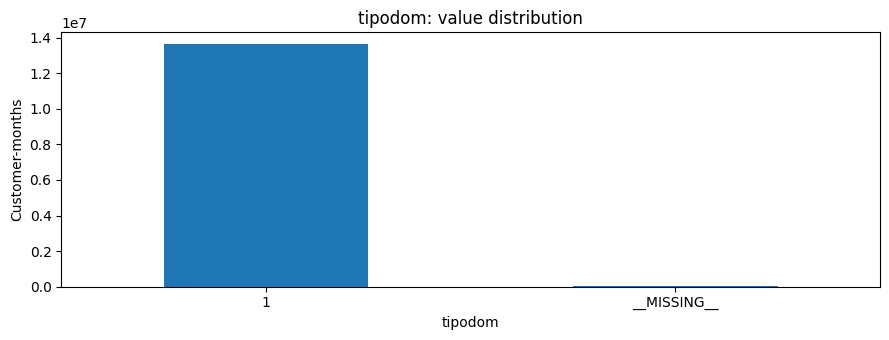

In [320]:
# Logic: visualize the address-type distribution separately from the missingness tables.
ax = tipodom_values.plot.bar(x="value", y="rows", legend=False, figsize=(9, 3.5), color="#1f77b4", title="tipodom: value distribution")
ax.set(xlabel="tipodom", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [321]:
# Logic: list domain-plausible interaction candidates; keep them only after time-based validation.
tipodom_associations = deep_association_table("tipodom")
display(tipodom_associations)

,candidate_partner,how_to_combine
0,indfall,Validate as an interaction with time-based split.
1,indrel,Validate as an interaction with time-based split.
2,indrel_1mes,Validate as an interaction with time-based split.
3,tiprel_1mes,Validate as an interaction with time-based split.
4,ind_actividad_cliente,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — tipodom

**Kết luận thao tác.** Observed value là hằng nên drop value feature. Không blanket-fill null thành 1; chỉ giữ missing/structural flag để tách cohort indfall-missing và case non-primary.

#### tipodom × indfall — missing-state matrix

Bổ sung heatmap cho kiểm tra overlap missing để tách cohort thiếu profile đồng loạt khỏi rare case tipodom missing nhưng indfall vẫn quan sát được.

In [322]:
# Logic: create an explicit missing-state table for tipodom and indfall instead of comparing missing rates alone.
tipodom_indfall_cross = q("""
    WITH base AS (
        SELECT CASE WHEN tipodom IS NULL THEN '<MISSING>' ELSE '<OBSERVED>' END AS tipodom_state,
               CASE WHEN indfall IS NULL THEN '<MISSING>' ELSE CAST(indfall AS VARCHAR) END AS indfall_state
        FROM read_parquet(?)
    ),
    counts AS (
        SELECT tipodom_state, indfall_state, COUNT(*) AS records FROM base GROUP BY 1, 2
    )
    SELECT tipodom_state, indfall_state, records,
           ROUND(100.0 * records / SUM(records) OVER (PARTITION BY tipodom_state), 3) AS row_pct
    FROM counts
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))
tipodom_indfall_row_pct = tipodom_indfall_cross.pivot(index="tipodom_state", columns="indfall_state", values="row_pct").fillna(0)
display(tipodom_indfall_cross)
display(tipodom_indfall_row_pct.round(3))

,tipodom_state,indfall_state,records,row_pct
0,<MISSING>,<MISSING>,27734,99.996
1,<MISSING>,N,1,0.004
2,<OBSERVED>,N,13584812,99.745
3,<OBSERVED>,S,34762,0.255


indfall_state,<MISSING>,N,S
tipodom_state,,,
<MISSING>,99.996,0.004,0.000
<OBSERVED>,0.000,99.745,0.255


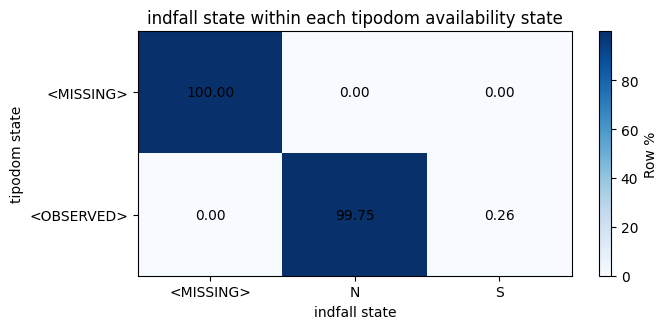

In [323]:
# Logic: visualize conditional indfall states inside each tipodom availability state to make the overlap auditable.
fig, ax = plt.subplots(figsize=(7, 3.4))
image = ax.imshow(tipodom_indfall_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="indfall state within each tipodom availability state",
    xlabel="indfall state", ylabel="tipodom state",
    xticks=range(len(tipodom_indfall_row_pct.columns)), xticklabels=tipodom_indfall_row_pct.columns,
    yticks=range(len(tipodom_indfall_row_pct.index)), yticklabels=tipodom_indfall_row_pct.index,
)
for row in range(tipodom_indfall_row_pct.shape[0]):
    for col in range(tipodom_indfall_row_pct.shape[1]):
        ax.text(col, row, f"{tipodom_indfall_row_pct.iloc[row, col]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [324]:
# Logic: report the structural-cohort overlap among tipodom-missing records.
from IPython.display import Markdown, display
_tip_missing_row = tipodom_indfall_row_pct.loc["<MISSING>"] if "<MISSING>" in tipodom_indfall_row_pct.index else pd.Series(dtype=float)
_overlap_pct = float(_tip_missing_row.get("<MISSING>", 0.0))
display(Markdown(
    f"**Insight.** Trong các record tipodom missing, **{_overlap_pct:.3f}%** đồng thời có indfall missing. "
    "Vì vậy không blanket-fill tipodom: tách structural cohort khỏi phần tipodom-only missing còn lại."
))

**Insight.** Trong các record tipodom missing, **99.996%** đồng thời có indfall missing. Vì vậy không blanket-fill tipodom: tách structural cohort khỏi phần tipodom-only missing còn lại.

In [325]:
# Logic: state the final modelling decision, separating a constant value from potentially informative missingness.
display(Markdown(
    "**Kết luận.** tipodom nên bị loại như value feature nếu bảng distribution xác nhận chỉ có một giá trị quan sát được. "
    "Không impute toàn bộ null thành 1: giữ tipodom_is_missing; và nếu cần xử lý riêng, chỉ tạo category structural-missing "
    "cho tipodom IS NULL AND indfall IS NOT NULL sau khi kiểm chứng bảng trạng thái primary/multi-product phía trên."
))

**Kết luận.** tipodom nên bị loại như value feature nếu bảng distribution xác nhận chỉ có một giá trị quan sát được. Không impute toàn bộ null thành 1: giữ tipodom_is_missing; và nếu cần xử lý riêng, chỉ tạo category structural-missing cho tipodom IS NULL AND indfall IS NOT NULL sau khi kiểm chứng bảng trạng thái primary/multi-product phía trên.

### indresi — Cờ cư trú trong nước

Biến categorical nhị phân; phân tích missingness, phân phối và redundancy/interaction với quốc gia cư trú cùng cờ cư trú còn lại.

In [326]:
# Logic: quantify missingness and cardinality for indresi.
indresi_overview = deep_overview("indresi")
display(indresi_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [327]:
# Logic: turn the completeness/cardinality result into a numeric interpretation.
show_overview_insight("indresi", indresi_overview)

**Insight.** indresi có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [328]:
# Logic: test whether indresi missingness changes by monthly snapshot.
indresi_missing_by_month = deep_missing_by_month("indresi")
display(indresi_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [329]:
# Logic: test whether indresi missing values follow prior observations for the same customer.
indresi_history_missing = deep_history_missing("indresi")
display(indresi_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [330]:
# Logic: test whether indresi missingness concentrates by pais_residencia.
indresi_missing_by_pais_residencia = deep_missing_by_driver("indresi", "pais_residencia")
display(indresi_missing_by_pais_residencia)

,pais_residencia,rows,missing_count,missing_pct
0,ES,13553710,0.0,0.0
1,__MISSING__,27734,27734.0,100.0
2,FR,5161,0.0,0.0
3,AR,4835,0.0,0.0
4,DE,4625,0.0,0.0
5,GB,4605,0.0,0.0
6,US,3651,0.0,0.0
7,CO,3526,0.0,0.0
8,IT,2947,0.0,0.0
9,RO,2931,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [331]:
# Logic: choose a missing-value treatment from temporal, history, and driver evidence.
show_missing_insight("indresi", indresi_history_missing, "pais_residencia")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo pais_residencia là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [332]:
# Logic: count observed levels and physical missingness for indresi.
indresi_values = deep_top_values("indresi")
display(indresi_values)

,value,rows,pct
0,S,13553711,99.314
1,N,65864,0.483
2,__MISSING__,27734,0.203


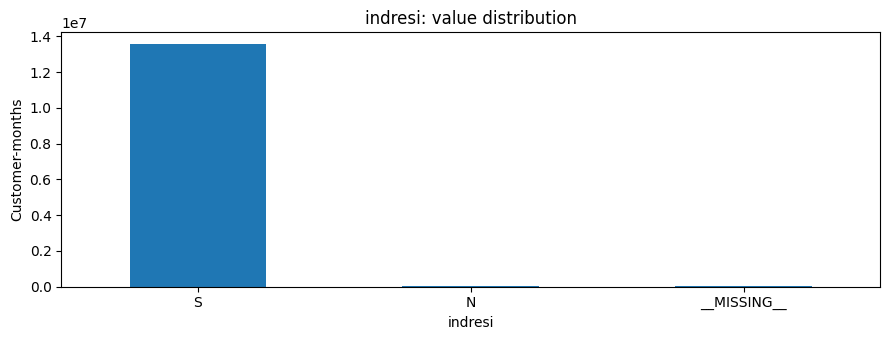

In [333]:
# Logic: visualize the value-frequency table for indresi.
ax = indresi_values.plot.bar(x="value", y="rows", legend=False, figsize=(9, 3.5), color="#1f77b4", title="indresi: value distribution")
ax.set(xlabel="indresi", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [334]:
# Logic: derive one-hot/missing-category guidance from the observed distribution.
show_distribution_insight("indresi", "categorical", indresi_values)

**Insight.** Giá trị phổ biến nhất là S với **99.314%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [335]:
# Logic: list residence-related interaction candidates for temporal validation.
indresi_associations = deep_association_table("indresi")
display(indresi_associations)

,candidate_partner,how_to_combine
0,pais_residencia,Validate as an interaction with time-based split.
1,indext,Validate as an interaction with time-based split.
2,cod_prov,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — indresi

**Kết luận thao tác.** Dùng binary/one-hot với missing level; kiểm tra redundancy với pais_residencia và indext trước khi giữ cả ba.

In [336]:
# Logic: summarize the strongest residence-related interaction candidate and caveat.
show_association_insight("indresi", indresi_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### indext — Cờ khách hàng nước ngoài

Biến categorical nhị phân; phân tích missingness, phân phối và redundancy/interaction với quốc gia cư trú cùng cờ cư trú còn lại.

In [337]:
# Logic: quantify missingness and cardinality for indext.
indext_overview = deep_overview("indext")
display(indext_overview)

,rows,missing_count,missing_pct,n_unique_non_null
0,13647309,27734.0,0.203,2


**Insight — completeness & cardinality**

In [338]:
# Logic: turn the completeness/cardinality result into a numeric interpretation.
show_overview_insight("indext", indext_overview)

**Insight.** indext có **27,734** giá trị thiếu (**0.203%**) và **2** giá trị khác nhau (không tính null). Các cell tiếp theo kiểm chứng missing theo thời gian và theo lịch sử khách hàng trước khi chọn imputation.

In [339]:
# Logic: test whether indext missingness changes by monthly snapshot.
indext_missing_by_month = deep_missing_by_month("indext")
display(indext_missing_by_month)

,fecha_dato,rows,missing_count,missing_pct
0,2015-01-28,625457,6953.0,1.112
1,2015-02-28,627394,5940.0,0.947
2,2015-03-28,629209,5091.0,0.809
3,2015-04-28,630367,4292.0,0.681
4,2015-05-28,631957,3597.0,0.569
5,2015-06-28,632110,1861.0,0.294
6,2015-07-28,829817,0.0,0.000
7,2015-08-28,843201,0.0,0.000
8,2015-09-28,865440,0.0,0.000
9,2015-10-28,892251,0.0,0.000


In [340]:
# Logic: test whether indext missing values follow prior observations for the same customer.
indext_history_missing = deep_history_missing("indext")
display(indext_history_missing)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_rows,missing_after_observed,pct_after_observed
0,27734.0,0.0,0.0


In [341]:
# Logic: test whether indext missingness concentrates by pais_residencia.
indext_missing_by_pais_residencia = deep_missing_by_driver("indext", "pais_residencia")
display(indext_missing_by_pais_residencia)

,pais_residencia,rows,missing_count,missing_pct
0,ES,13553710,0.0,0.0
1,__MISSING__,27734,27734.0,100.0
2,FR,5161,0.0,0.0
3,AR,4835,0.0,0.0
4,DE,4625,0.0,0.0
5,GB,4605,0.0,0.0
6,US,3651,0.0,0.0
7,CO,3526,0.0,0.0
8,IT,2947,0.0,0.0
9,RO,2931,0.0,0.0


**Insight — missingness hypothesis and treatment**

In [342]:
# Logic: choose a missing-value treatment from temporal, history, and driver evidence.
show_missing_insight("indext", indext_history_missing, "pais_residencia")

**Insight.** Có **27,734** missing; **0.00%** xảy ra sau một quan sát hợp lệ trước đó. Bảng theo pais_residencia là kiểm chứng giả thuyết missing theo nhóm. Giữ missing như category __MISSING__; không forward-fill trạng thái có thể đổi theo tháng.

In [343]:
# Logic: count observed levels and physical missingness for indext.
indext_values = deep_top_values("indext")
display(indext_values)

,value,rows,pct
0,N,12974839,95.073
1,S,644736,4.724
2,__MISSING__,27734,0.203


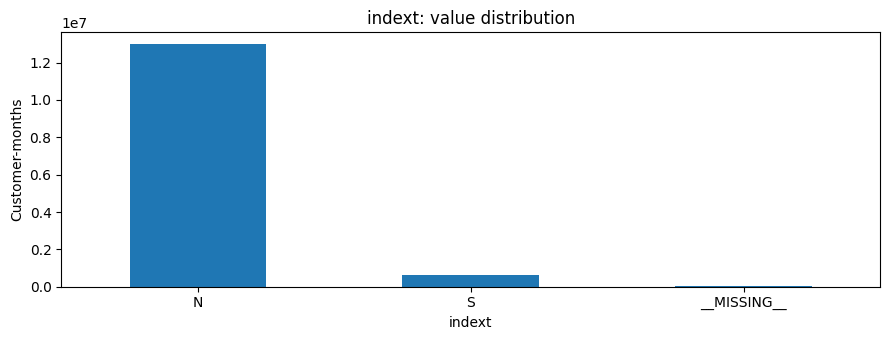

In [344]:
# Logic: visualize the value-frequency table for indext.
ax = indext_values.plot.bar(x="value", y="rows", legend=False, figsize=(9, 3.5), color="#1f77b4", title="indext: value distribution")
ax.set(xlabel="indext", ylabel="Customer-months")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Insight — distribution and encoding**

In [345]:
# Logic: derive one-hot/missing-category guidance from the observed distribution.
show_distribution_insight("indext", "categorical", indext_values)

**Insight.** Giá trị phổ biến nhất là N với **95.073%**. Low-cardinality dùng one-hot; high-cardinality cần gộp mức hiếm rồi frequency/count encoding.

In [346]:
# Logic: list residence-related interaction candidates for temporal validation.
indext_associations = deep_association_table("indext")
display(indext_associations)

,candidate_partner,how_to_combine
0,pais_residencia,Validate as an interaction with time-based split.
1,indresi,Validate as an interaction with time-based split.
2,cod_prov,Validate as an interaction with time-based split.
3,canal_entrada,Validate as an interaction with time-based split.


#### Tổng hợp, kết luận — indext

**Kết luận thao tác.** Dùng binary/one-hot với missing level; chỉ giữ interaction với pais_residencia nếu temporal validation cải thiện.

In [347]:
# Logic: summarize the strongest residence-related interaction candidate and caveat.
show_association_insight("indext", indext_associations)

**Insight.** Các partner phía trên là ứng viên interaction theo ngữ nghĩa nghiệp vụ; chỉ giữ interaction nếu MAP@7 trên validation theo thời gian cải thiện.

### Residence flags × country — consistency and redundancy

Kiểm tra trực tiếp sự đồng thời của indresi và indext, đồng thời xem country trội trong từng tổ hợp cờ. Mục tiêu là quyết định giữ cả ba feature hay chỉ giữ representation có incremental value.

In [348]:
1. # Logic: build an indresi × indext count matrix and identify the dominant country within every flag combination.

residence_flag_long = q("""
    WITH base AS (
        SELECT
            COALESCE(CAST(indresi AS VARCHAR), '__MISSING__') AS indresi_state,
            COALESCE(CAST(indext AS VARCHAR), '__MISSING__') AS indext_state,
            COALESCE(CAST(pais_residencia AS VARCHAR), '__MISSING__') AS country_state
        FROM read_parquet(?)
    )
    SELECT indresi_state, indext_state, COUNT(*) AS records
    FROM base
    GROUP BY 1, 2
    ORDER BY 1, 2
""", str(TRAIN_PARQUET))

residence_flag_count = residence_flag_long.pivot(
    index="indresi_state", columns="indext_state", values="records"
).fillna(0).astype(int)
residence_flag_row_pct = residence_flag_count.div(residence_flag_count.sum(axis=1), axis=0).mul(100)

residence_flag_country_top = q("""
    WITH counts AS (
        SELECT
            COALESCE(CAST(indresi AS VARCHAR), '__MISSING__') AS indresi_state,
            COALESCE(CAST(indext AS VARCHAR), '__MISSING__') AS indext_state,
            COALESCE(CAST(pais_residencia AS VARCHAR), '__MISSING__') AS country_state,
            COUNT(*) AS records
        FROM read_parquet(?)
        GROUP BY 1, 2, 3
    ),
    ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY indresi_state, indext_state
                   ORDER BY records DESC, country_state
               ) AS rank_within_flags,
               SUM(records) OVER (
                   PARTITION BY indresi_state, indext_state
               ) AS total_records
        FROM counts
    )
    SELECT
        indresi_state, indext_state, country_state AS dominant_country,
        records, total_records,
        ROUND(100.0 * records / total_records, 3) AS dominant_country_pct
    FROM ranked
    WHERE rank_within_flags = 1
    ORDER BY indresi_state, indext_state
""", str(TRAIN_PARQUET))

display(residence_flag_count)
display(residence_flag_country_top)

indext_state,N,S,__MISSING__
indresi_state,,,
N,13255,52609,0
S,12961584,592127,0
__MISSING__,0,0,27734


,indresi_state,indext_state,dominant_country,records,total_records,dominant_country_pct
0,N,N,GB,1804,13255.0,13.610
1,N,S,AR,4508,52609.0,8.569
2,S,N,ES,12961583,12961584.0,100.000
3,S,S,ES,592125,592127.0,100.000
4,__MISSING__,__MISSING__,__MISSING__,27734,27734.0,100.000


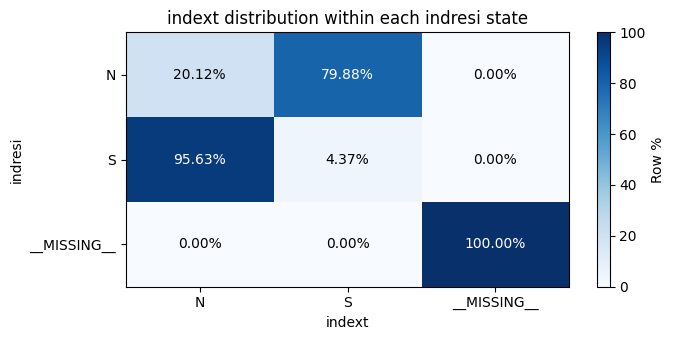

In [349]:
# Logic: visualize the conditional distribution of indext within each indresi state; counts remain available in the preceding table.

fig, ax = plt.subplots(figsize=(7, 3.5))
image = ax.imshow(residence_flag_row_pct.to_numpy(), cmap="Blues", aspect="auto")
ax.set(
    title="indext distribution within each indresi state",
    xlabel="indext",
    ylabel="indresi",
    xticks=range(len(residence_flag_row_pct.columns)),
    xticklabels=residence_flag_row_pct.columns,
    yticks=range(len(residence_flag_row_pct.index)),
    yticklabels=residence_flag_row_pct.index,
)
for row_index in range(residence_flag_row_pct.shape[0]):
    for column_index in range(residence_flag_row_pct.shape[1]):
        value = residence_flag_row_pct.iloc[row_index, column_index]
        ax.text(column_index, row_index, f"{value:.2f}%", ha="center", va="center",
                color="white" if value > 50 else "black")
fig.colorbar(image, ax=ax, label="Row %")
plt.tight_layout()
plt.show()

In [350]:
# Logic: translate the matrix into a redundancy decision without assuming the flags are perfectly inverse.

from IPython.display import Markdown, display

_residence_dominant = residence_flag_row_pct.stack().sort_values(ascending=False).iloc[0]
_residence_country_min = residence_flag_country_top["dominant_country_pct"].min()
display(Markdown(
    f"**Insight.** Tổ hợp cờ chiếm tỷ lệ lớn nhất theo hàng là **{_residence_dominant:.3f}%**. "
    f"Country trội trong mỗi tổ hợp cờ chiếm tối thiểu **{_residence_country_min:.3f}%**. "
    "Các cờ không nên bị gộp theo giả định; hãy one-hot/binary riêng, sau đó ablate chúng với pais_residencia bằng validation theo thời gian."
))

**Insight.** Tổ hợp cờ chiếm tỷ lệ lớn nhất theo hàng là **100.000%**. Country trội trong mỗi tổ hợp cờ chiếm tối thiểu **8.569%**. Các cờ không nên bị gộp theo giả định; hãy one-hot/binary riêng, sau đó ablate chúng với pais_residencia bằng validation theo thời gian.

### Common-missing cohort — missingness heatmap

Heatmap đo tỷ lệ missing của từng profile feature theo snapshot, để kiểm chứng trực quan các cột cùng bùng missing ở giai đoạn đầu.

In [351]:
# Logic: compute physical missingness rates for each profile feature at every snapshot to expose synchronized early-period gaps.
if "TRAIN_PARQUET" not in globals() or "PROFILE_COLUMNS" not in globals():
    raise RuntimeError("Run Bootstrap, EDA setup, and Feature Deep EDA helpers first.")
_profile_heatmap_features = [c for c in PROFILE_COLUMNS if c in ALL_COLUMNS]
_profile_heatmap_sql = ", ".join(
    f"ROUND(100.0 * AVG(CASE WHEN {quote_identifier(c)} IS NULL THEN 1 ELSE 0 END), 3) AS {quote_identifier(c)}"
    for c in _profile_heatmap_features
)
profile_missingness_by_snapshot = q(
    f"SELECT fecha_dato, {_profile_heatmap_sql} FROM read_parquet(?) GROUP BY 1 ORDER BY 1",
    str(TRAIN_PARQUET),
)
profile_missingness_heatmap = profile_missingness_by_snapshot.set_index("fecha_dato").T
display(profile_missingness_heatmap)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fecha_dato,2015-01-28,2015-02-28,2015-03-28,2015-04-28,2015-05-28,2015-06-28,2015-07-28,2015-08-28,2015-09-28,2015-10-28,2015-11-28,2015-12-28,2016-01-28,2016-02-28,2016-03-28,2016-04-28,2016-05-28
age,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
antiguedad,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
renta,17.839,17.711,17.595,17.492,17.393,17.155,17.177,17.106,18.029,20.545,21.885,22.481,23.016,23.496,23.929,24.266,24.587
ind_nuevo,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
indrel,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
indrel_1mes,1.112,0.947,0.809,0.681,0.569,0.294,1.977,1.363,2.610,2.981,1.546,0.737,0.659,0.590,0.503,0.441,0.431
tiprel_1mes,1.112,0.947,0.809,0.681,0.569,0.294,1.977,1.363,2.610,2.981,1.546,0.737,0.659,0.590,0.503,0.441,0.431
ind_actividad_cliente,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ind_empleado,1.112,0.947,0.809,0.681,0.569,0.294,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
conyuemp,99.986,99.986,99.986,99.986,99.986,99.986,99.986,99.986,99.986,99.987,99.987,99.987,99.988,99.987,99.987,99.987,99.988


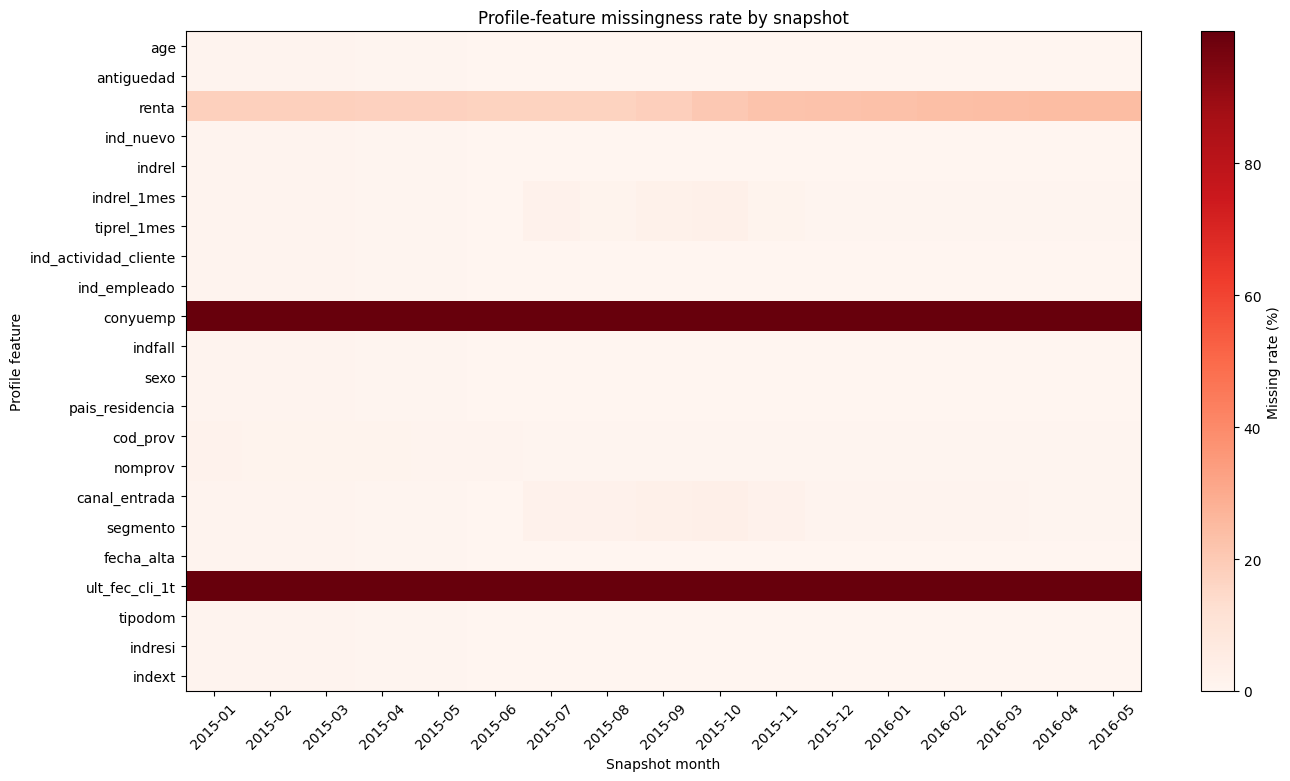

In [352]:
# Logic: plot the feature-by-snapshot missingness matrix so shared missingness is visible without reading many separate tables.
fig, ax = plt.subplots(figsize=(14, max(6, 0.36 * len(profile_missingness_heatmap))))
image = ax.imshow(profile_missingness_heatmap.to_numpy(dtype=float), aspect="auto", cmap="Reds", vmin=0)
ax.set(
    title="Profile-feature missingness rate by snapshot",
    xlabel="Snapshot month", ylabel="Profile feature",
    xticks=range(len(profile_missingness_heatmap.columns)),
    xticklabels=[pd.Timestamp(x).strftime("%Y-%m") for x in profile_missingness_heatmap.columns],
    yticks=range(len(profile_missingness_heatmap.index)), yticklabels=profile_missingness_heatmap.index,
)
ax.tick_params(axis="x", rotation=45)
fig.colorbar(image, ax=ax, label="Missing rate (%)")
plt.tight_layout()
plt.show()

In [353]:
# Logic: identify features whose nonzero-missing months exactly match indfall, then interpret the heatmap as cohort evidence.
from IPython.display import Markdown, display
_indfall_pattern = profile_missingness_heatmap.loc["indfall"].gt(0) if "indfall" in profile_missingness_heatmap.index else pd.Series(dtype=bool)
_exact_pattern_features = profile_missingness_heatmap.index[
    profile_missingness_heatmap.gt(0).eq(_indfall_pattern, axis=1).all(axis=1)
].tolist() if not _indfall_pattern.empty else []
_indfall_months = int(_indfall_pattern.sum()) if not _indfall_pattern.empty else 0
display(Markdown(
    f"**Insight.** indfall có missing ở **{_indfall_months}** snapshot. "
    f"Có **{len(_exact_pattern_features)}** profile feature có đúng cùng pattern tháng-missing với indfall: "
    f"**{', '.join(_exact_pattern_features)}**. "
    "Các dải đỏ đồng thời ở đầu timeline là bằng chứng trực quan cho cohort missing historical/structural, "
    "không phải các null độc lập để median/mode-impute."
))

**Insight.** indfall có missing ở **6** snapshot. Có **12** profile feature có đúng cùng pattern tháng-missing với indfall: **age, antiguedad, ind_nuevo, indrel, ind_actividad_cliente, ind_empleado, indfall, pais_residencia, fecha_alta, tipodom, indresi, indext**. Các dải đỏ đồng thời ở đầu timeline là bằng chứng trực quan cho cohort missing historical/structural, không phải các null độc lập để median/mode-impute.

### Common-missing cohort × test set

Kiểm tra liệu các customer thuộc cohort record thiếu profile đồng loạt (neo theo indfall missing và xác minh pattern missing trùng khớp) có xuất hiện trong test set hay không.

In [354]:
# Logic: identify columns with the same missing count as indfall, verify the record-level common-missing pattern, and measure customer overlap with test.
if "TRAIN_PARQUET" not in globals() or "TEST_PARQUET" not in globals():
    raise RuntimeError("Run Bootstrap, Ingest, and EDA setup before this check.")

_non_product_columns = [c for c in ALL_COLUMNS if c not in PRODUCT_COLUMNS]
_missing_sql = ", ".join(f"SUM({quote_identifier(c)} IS NULL) AS {quote_identifier(c)}" for c in _non_product_columns)
_missing_counts = q(f"SELECT {_missing_sql} FROM read_parquet(?)", str(TRAIN_PARQUET)).T.rename(columns={0: "missing_count"})
_indfall_missing = int(_missing_counts.loc["indfall", "missing_count"])
_same_missing_features = _missing_counts.index[_missing_counts["missing_count"].eq(_indfall_missing)].tolist()

# indfall defines the candidate cohort; the condition below checks whether all same-count fields are absent in each candidate row.
_all_common_missing = " AND ".join(f"{quote_identifier(c)} IS NULL" for c in _same_missing_features)
_common_missing_test_overlap = q(f"""
    WITH cohort_rows AS (
        SELECT ncodpers
        FROM read_parquet(?)
        WHERE indfall IS NULL
    ),
    cohort_customers AS (
        SELECT DISTINCT ncodpers FROM cohort_rows
    ),
    exact_pattern AS (
        SELECT
            COUNT(*) AS candidate_rows,
            SUM(CASE WHEN {_all_common_missing} THEN 1 ELSE 0 END) AS rows_missing_all_same_count_features
        FROM read_parquet(?)
        WHERE indfall IS NULL
    ),
    test_customers AS (
        SELECT DISTINCT ncodpers FROM read_parquet(?)
    )
    SELECT
        (SELECT candidate_rows FROM exact_pattern) AS candidate_train_rows,
        (SELECT rows_missing_all_same_count_features FROM exact_pattern) AS exact_common_missing_rows,
        COUNT(*) AS cohort_customers,
        COUNT(test_customers.ncodpers) AS cohort_customers_in_test,
        COUNT(*) - COUNT(test_customers.ncodpers) AS cohort_customers_not_in_test,
        ROUND(100.0 * COUNT(test_customers.ncodpers) / COUNT(*), 3) AS cohort_customer_test_overlap_pct
    FROM cohort_customers
    LEFT JOIN test_customers USING (ncodpers)
""", str(TRAIN_PARQUET), str(TRAIN_PARQUET), str(TEST_PARQUET))

display(pd.DataFrame({"feature_with_same_missing_count_as_indfall": _same_missing_features}))
display(_common_missing_test_overlap)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,feature_with_same_missing_count_as_indfall
0,ind_empleado
1,pais_residencia
2,age
3,fecha_alta
4,ind_nuevo
5,antiguedad
6,indrel
7,indresi
8,indext
9,indfall


,candidate_train_rows,exact_common_missing_rows,cohort_customers,cohort_customers_in_test,cohort_customers_not_in_test,cohort_customer_test_overlap_pct
0,27734,27734.0,7340,251,7089,3.42


In [355]:
# Logic: compute customer-level test overlap for the common-missing candidate cohort with the smallest required scan.
common_missing_cohort_test_overlap = q("""
    WITH cohort AS (
        SELECT DISTINCT ncodpers
        FROM read_parquet(?)
        WHERE indfall IS NULL
    ),
    test_ids AS (
        SELECT DISTINCT ncodpers
        FROM read_parquet(?)
    )
    SELECT
        COUNT(*) AS cohort_customers,
        COUNT(test_ids.ncodpers) AS cohort_customers_in_test,
        COUNT(*) - COUNT(test_ids.ncodpers) AS cohort_customers_not_in_test,
        ROUND(100.0 * COUNT(test_ids.ncodpers) / COUNT(*), 3) AS cohort_customer_test_overlap_pct
    FROM cohort
    LEFT JOIN test_ids USING (ncodpers)
""", str(TRAIN_PARQUET), str(TEST_PARQUET))
print(common_missing_cohort_test_overlap.to_string(index=False))

 cohort_customers  cohort_customers_in_test  cohort_customers_not_in_test  cohort_customer_test_overlap_pct
             7340                       251                          7089                              3.42
